In [22]:
import matplotlib.pyplot as plt

# Set Times New Roman as default font for all text elements
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 10  # Optional: set default font size

# For mathematical expressions (optional)
plt.rcParams['mathtext.fontset'] = 'stix'  # STIX font similar to Times

In [23]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt
import math
from vsl_ial.stress import stress as stress_fn


# ============================================================
# 0) Utils
# ============================================================

def sanitize_X(X):
    X = np.asarray(X, dtype=np.float32)
    m = np.isfinite(X).all(axis=1)
    if m.sum() < len(m):
        print(f"sanitize_X: dropped {len(m)-m.sum()}/{len(m)} rows with NaN/Inf")
    return X[m], m


def safe_corr(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)

    if len(y_true) < 2:
        return np.nan, np.nan
    if np.allclose(y_true, y_true[0]) or np.allclose(y_pred, y_pred[0]):
        return np.nan, np.nan

    pr = float(pearsonr(y_true, y_pred)[0])
    sr = spearmanr(y_true, y_pred)
    sr_r = float(getattr(sr, "correlation", sr.statistic))
    return pr, sr_r


def safe_stress(d_true, d_pred, ord=2):
    d_true = np.asarray(d_true, dtype=np.float64)
    d_pred = np.asarray(d_pred, dtype=np.float64)
    m = np.isfinite(d_true) & np.isfinite(d_pred)
    if m.sum() < 2:
        return np.nan
    return float(stress_fn(d_pred[m], d_true[m], ord=ord))


def make_log_m_grid(max_dim, min_dim=3, n_points=6, include_max=True):
    """
    Логарифмически равномерная сетка по m.
    """
    max_dim = int(max_dim)
    min_dim = int(min_dim)

    if max_dim < 1:
        raise ValueError(f"max_dim must be >= 1, got {max_dim}")

    min_dim = max(1, min_dim)

    if min_dim >= max_dim:
        return [max_dim]

    raw = np.geomspace(min_dim, max_dim, num=n_points)
    grid = np.unique(np.clip(np.round(raw).astype(int), min_dim, max_dim))

    if include_max and grid[-1] != max_dim:
        grid = np.append(grid, max_dim)

    return sorted(set(grid.tolist()))


def prepare_pairs_df(pairs_df, n_objects, dataset_name=None):
    """
    Ожидает колонки:
      - i, j: индексы объектов
      - dv: целевое расстояние (НЕ квадрат)
      - (опционально) dataset
    """
    p = pairs_df.copy()

    if dataset_name is not None:
        if "dataset" not in p.columns:
            raise ValueError("pairs_df has no 'dataset' column, but dataset_name was provided.")
        p = p[p["dataset"] == dataset_name].copy()

    required = {"i", "j", "dv"}
    missing = required - set(p.columns)
    if missing:
        raise ValueError(f"pairs_df missing required columns: {missing}")

    p = p[np.isfinite(p["i"]) & np.isfinite(p["j"]) & np.isfinite(p["dv"])].copy()
    p["i"] = p["i"].astype(np.int64)
    p["j"] = p["j"].astype(np.int64)
    p["dv"] = p["dv"].astype(np.float32)

    p = p[(p["i"] >= 0) & (p["j"] >= 0) & (p["i"] < n_objects) & (p["j"] < n_objects)]
    p = p[p["i"] != p["j"]]
    p = p[p["dv"] >= 0.0]

    # canonical order i<j
    i = p["i"].to_numpy()
    j = p["j"].to_numpy()
    i2 = np.minimum(i, j)
    j2 = np.maximum(i, j)
    p = p.copy()
    p["i"] = i2
    p["j"] = j2

    # убрать дубликаты пар (если есть), усреднить dv
    p = p.groupby(["i", "j"], as_index=False)["dv"].mean()

    if len(p) == 0:
        raise ValueError("No valid pairs left after filtering.")

    return p


def make_pair_batch_from_pairs(X, i, j, d_true):
    V = X[i] - X[j]
    t2 = d_true * d_true
    m = np.isfinite(V).all(axis=1) & np.isfinite(t2)
    if not np.all(m):
        V = V[m]
        t2 = t2[m]
    return V, t2


def compute_pred_true_for_pairs(X, A, i, j, d_true):
    dX = X[i] - X[j]
    AdX = dX @ A.T
    pred2 = np.sum(AdX * AdX, axis=1)
    pred = np.sqrt(np.maximum(pred2, 0.0))

    t = np.asarray(d_true, dtype=np.float32)
    t2 = t * t

    m = np.isfinite(t) & np.isfinite(pred) & np.isfinite(t2) & np.isfinite(pred2)
    return t[m], pred[m], t2[m], pred2[m]


# ============================================================
# 1) L = mean ( ||A v||^2 - t2 )^2
# ============================================================

def loss_and_grad_A_squared_full(A, V, t2):
    AV = V @ A.T
    s = np.sum(AV * AV, axis=1)
    e = (s - t2)
    loss = float(np.mean(e * e))

    c = (4.0 * e).astype(np.float32)
    grad = ((c[:, None] * AV).T @ V) / max(1, V.shape[0])
    return loss, grad


# ============================================================
# 2) AdamW  + grad clipping
# ============================================================

class AdamW:
    def __init__(self, shape, lr=1e-3, beta1=0.9, beta2=0.999, eps=1e-8, weight_decay=1e-4):
        self.lr = float(lr)
        self.b1 = float(beta1)
        self.b2 = float(beta2)
        self.eps = float(eps)
        self.wd = float(weight_decay)
        self.m = np.zeros(shape, dtype=np.float32)
        self.v = np.zeros(shape, dtype=np.float32)
        self.t = 0

    def step(self, param, grad):
        self.t += 1
        if self.wd > 0:
            param = param * (1.0 - self.lr * self.wd)

        self.m = self.b1 * self.m + (1.0 - self.b1) * grad
        self.v = self.b2 * self.v + (1.0 - self.b2) * (grad * grad)

        mhat = self.m / (1.0 - self.b1 ** self.t)
        vhat = self.v / (1.0 - self.b2 ** self.t)

        param = param - self.lr * mhat / (np.sqrt(vhat) + self.eps)
        return param


# ============================================================
# 3) Metrics on DISTANCES 
# ============================================================

def dist_errors(d_true, d_pred, eps=1e-6):
    d_true = np.asarray(d_true, dtype=np.float64)
    d_pred = np.asarray(d_pred, dtype=np.float64)

    err = d_pred - d_true
    mae = float(np.mean(np.abs(err)))
    rmse = float(np.sqrt(np.mean(err * err)))

    denom = np.maximum(np.abs(d_true), eps)
    mape = float(np.mean(np.abs(err) / denom) * 100.0)
    smape = float(np.mean(2.0 * np.abs(err) / np.maximum(np.abs(d_true) + np.abs(d_pred), eps)) * 100.0)

    pr, sr = safe_corr(d_true, d_pred)
    st = safe_stress(d_true, d_pred, ord=2)

    return {
        "rmse": rmse,
        "mae": mae,
        "mape": mape,
        "smape": smape,
        "pearson": pr,
        "spearman": sr,
        "stress": st,
    }


def estimate_val_loss_sq_objective_pairs(X, A, i, j, d_true, max_eval_pairs=None, rng=None):
    if max_eval_pairs is not None and len(i) > max_eval_pairs:
        if rng is None:
            rng = np.random.default_rng(0)
        idx = rng.choice(len(i), size=max_eval_pairs, replace=False)
        i, j, d_true = i[idx], j[idx], d_true[idx]

    V, t2 = make_pair_batch_from_pairs(X, i, j, d_true)
    AV = V @ A.T
    pred2 = np.sum(AV * AV, axis=1)
    e = pred2 - t2
    return float(np.mean(e * e))


def eval_dist_metrics_pairs(X, A, i, j, d_true, max_eval_pairs=None, rng=None):
    if max_eval_pairs is not None and len(i) > max_eval_pairs:
        if rng is None:
            rng = np.random.default_rng(0)
        idx = rng.choice(len(i), size=max_eval_pairs, replace=False)
        i, j, d_true = i[idx], j[idx], d_true[idx]

    d_true_arr, d_pred_arr, _, _ = compute_pred_true_for_pairs(X, A, i, j, d_true)
    return dist_errors(d_true_arr, d_pred_arr)


# ============================================================
# 4) Init: A = alpha * I
# ============================================================

def init_alphaI_from_pairs(X, i, j, d_true, eps=1e-12):
    dx = X[i] - X[j]
    dx2 = np.sum(dx * dx, axis=1)
    dy2 = d_true * d_true

    num = float(np.dot(dy2, dx2))
    den = float(np.dot(dx2, dx2)) + eps
    alpha2 = max(num / den, 0.0)
    return float(np.sqrt(alpha2))


# ============================================================
# 5) Training loop on explicit pairs_df
# ============================================================

def fit_fullA_distance_squares_pairs(
    X,
    i_train, j_train, d_train,
    i_val, j_val, d_val,
    n_steps=1200,
    batch_size=512,
    lr=3e-4,
    weight_decay=3e-4,
    grad_clip=5.0,
    seed=42,
    log_every=50,
    val_every=200,
    patience=5,
    min_delta=0.0,
    plot_from_step=100,
    max_eval_pairs=80_000,
    m_dim=3
):
    rng = np.random.default_rng(seed)
    n_dim = X.shape[1]

    alpha = init_alphaI_from_pairs(X, i_train, j_train, d_train)
    A = np.zeros((m_dim, n_dim), dtype=np.float32)

    k = min(m_dim, n_dim)
    A[:k, :k] = alpha * np.eye(k, dtype=np.float32)

    print(f"Init A = alpha*I, alpha={alpha:.6f}, ||A||={np.linalg.norm(A):.4f}, size={A.shape}")

    opt = AdamW(A.shape, lr=lr, weight_decay=weight_decay)

    hist_train_steps, hist_train_loss = [], []
    hist_val_steps, hist_val_loss = [], []
    hist_val_rmse, hist_val_mae, hist_val_mape, hist_val_smape = [], [], [], []
    hist_val_pearson, hist_val_spearman, hist_val_stress = [], [], []

    best = {"val_loss": np.inf, "A": A.copy(), "step": 0, "val_dist": None}
    bad_count = 0

    n_train_pairs = len(i_train)
    if n_train_pairs == 0:
        raise ValueError("No training pairs.")
    if len(i_val) == 0:
        raise ValueError("No validation pairs.")

    for step in range(1, n_steps + 1):
        bsz = min(batch_size, n_train_pairs)
        idx = rng.integers(0, n_train_pairs, size=bsz, endpoint=False)

        i_b = i_train[idx]
        j_b = j_train[idx]
        d_b = d_train[idx]

        V, t2 = make_pair_batch_from_pairs(X, i_b, j_b, d_b)
        train_loss, grad = loss_and_grad_A_squared_full(A, V, t2)

        gnorm = float(np.linalg.norm(grad))
        if grad_clip is not None and gnorm > grad_clip:
            grad = grad * (grad_clip / (gnorm + 1e-12))

        if not (np.isfinite(train_loss) and np.isfinite(A).all() and np.isfinite(grad).all()):
            raise FloatingPointError(
                f"Non-finite at step={step}: train_loss={train_loss}, ||A||={np.linalg.norm(A)}"
            )

        A = opt.step(A, grad.astype(np.float32))

        if step % log_every == 0 or step == 1:
            hist_train_steps.append(step)
            hist_train_loss.append(train_loss)

        if step % val_every == 0 or step == n_steps:
            val_loss = estimate_val_loss_sq_objective_pairs(
                X, A, i_val, j_val, d_val, max_eval_pairs=max_eval_pairs, rng=rng
            )
            val_dist = eval_dist_metrics_pairs(
                X, A, i_val, j_val, d_val, max_eval_pairs=max_eval_pairs, rng=rng
            )

            hist_val_steps.append(step)
            hist_val_loss.append(val_loss)
            hist_val_rmse.append(val_dist["rmse"])
            hist_val_mae.append(val_dist["mae"])
            hist_val_mape.append(val_dist["mape"])
            hist_val_smape.append(val_dist["smape"])
            hist_val_pearson.append(val_dist["pearson"])
            hist_val_spearman.append(val_dist["spearman"])
            hist_val_stress.append(val_dist["stress"])

            print(f"step={step}/{n_steps} train_loss(batch)={train_loss:.6f} ||grad||={gnorm:.3f} ||A||={np.linalg.norm(A):.3f}")
            print(f"  [val objective] loss={val_loss:.6f}")
            print(
                f"  [val dist] RMSE={val_dist['rmse']:.3f} "
                f"MAE={val_dist['mae']:.3f} "
                f"MAPE={val_dist['mape']:.2f}% "
                f"sMAPE={val_dist['smape']:.2f}% "
                f"Pearson={val_dist['pearson']:.4f} "
                f"Spearman={val_dist['spearman']:.4f} "
                f"Stress={val_dist['stress']:.6f}"
            )

            if val_loss < best["val_loss"] - min_delta:
                best = {"val_loss": val_loss, "A": A.copy(), "step": step, "val_dist": val_dist}
                bad_count = 0
            else:
                bad_count += 1
                if bad_count >= patience:
                    print(
                        f"Early stopping at step={step}: no improvement in VAL LOSS for {patience} validations. "
                        f"Best step={best['step']} val_loss={best['val_loss']:.6f}"
                    )
                    break

    tr_s = np.array(hist_train_steps, dtype=int)
    tr_l = np.array(hist_train_loss, dtype=float)
    va_s = np.array(hist_val_steps, dtype=int)
    va_l = np.array(hist_val_loss, dtype=float)

    m_tr = tr_s >= plot_from_step
    m_va = va_s >= plot_from_step

    plt.figure(figsize=(7, 4))
    if m_tr.any():
        plt.plot(tr_s[m_tr], tr_l[m_tr], label="train objective loss (batch)")
    if m_va.any():
        plt.plot(va_s[m_va], va_l[m_va], marker="o", label="val objective loss")
    plt.xlabel("step")
    plt.ylabel("loss")
    plt.title(f"Objective loss on train vs val (from step {plot_from_step})")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    if len(hist_val_steps) > 0 and m_va.any():
        plt.figure(figsize=(7, 4))
        plt.plot(va_s[m_va], np.array(hist_val_rmse)[m_va], marker="o", label="RMSE (dist)")
        plt.plot(va_s[m_va], np.array(hist_val_mae)[m_va], marker="o", label="MAE (dist)")
        plt.xlabel("step")
        plt.ylabel("error")
        plt.title(f"Val errors on distances (from step {plot_from_step})")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.show()

        plt.figure(figsize=(7, 4))
        plt.plot(va_s[m_va], np.array(hist_val_stress)[m_va], marker="o", label="Stress")
        plt.xlabel("step")
        plt.ylabel("stress")
        plt.title(f"Val stress on distances (from step {plot_from_step})")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.show()

    if len(hist_val_steps) > 0 and m_va.any():
        plt.figure(figsize=(7, 4))
        plt.plot(va_s[m_va], np.array(hist_val_mape)[m_va], marker="o", label="MAPE% (dist)")
        plt.plot(va_s[m_va], np.array(hist_val_smape)[m_va], marker="o", label="sMAPE% (dist)")
        plt.xlabel("step")
        plt.ylabel("percent")
        plt.title(f"Val percentage errors on distances (from step {plot_from_step})")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.show()

    print(f"Best by VAL LOSS: step={best['step']} val_loss={best['val_loss']:.6f}")
    if best["val_dist"] is not None:
        d = best["val_dist"]
        print(
            f"  [best val dist] RMSE={d['rmse']:.3f} "
            f"MAE={d['mae']:.3f} "
            f"MAPE={d['mape']:.2f}% "
            f"sMAPE={d['smape']:.2f}% "
            f"Pearson={d['pearson']:.4f} "
            f"Spearman={d['spearman']:.4f} "
            f"Stress={d['stress']:.6f}"
        )

    history = {
        "train_steps": tr_s,
        "train_loss": tr_l,
        "val_steps": va_s,
        "val_loss": va_l,
        "val_dist_rmse": np.array(hist_val_rmse, dtype=float),
        "val_dist_mae": np.array(hist_val_mae, dtype=float),
        "val_dist_mape": np.array(hist_val_mape, dtype=float),
        "val_dist_smape": np.array(hist_val_smape, dtype=float),
        "val_dist_pearson": np.array(hist_val_pearson, dtype=float),
        "val_dist_spearman": np.array(hist_val_spearman, dtype=float),
        "val_dist_stress": np.array(hist_val_stress, dtype=float),
    }
    return best, history


# ============================================================
# 6) End-to-end runner for pairs_df
# ============================================================

def run_fullA_experiment_pairs(
    embeddings,
    pairs_df,
    dataset_name='leeds',
    layer_name="LM",
    test_size=0.2,
    random_state=42,
    n_steps=1500,
    batch_size=512,
    lr=3e-4,
    weight_decay=3e-4,
    grad_clip=5.0,
    val_every=50,
    patience=5,
    min_delta=0.0,
    plot_from_step=100,
    max_eval_pairs=80_000,
    m_dim=3
):
    X, mask_valid = sanitize_X(embeddings)

    if not np.all(mask_valid):
        raise ValueError(
            "embeddings contain NaN/Inf. Fix embeddings first, otherwise pair indices no longer match object rows."
        )

    p = prepare_pairs_df(pairs_df, n_objects=X.shape[0], dataset_name=dataset_name)

    i_all = p["i"].to_numpy(dtype=np.int64)
    j_all = p["j"].to_numpy(dtype=np.int64)
    d_all = p["dv"].to_numpy(dtype=np.float32)

    idx = np.arange(len(p))
    idx_tr, idx_te = train_test_split(idx, test_size=test_size, random_state=random_state, shuffle=True)

    i_tr, j_tr, d_tr = i_all[idx_tr], j_all[idx_tr], d_all[idx_tr]
    i_te, j_te, d_te = i_all[idx_te], j_all[idx_te], d_all[idx_te]

    print(f"[{layer_name}] X={X.shape}, pairs_train={len(i_tr)}, pairs_val={len(i_te)}, dim={X.shape[1]}, m={m_dim}")

    best, history = fit_fullA_distance_squares_pairs(
        X,
        i_tr, j_tr, d_tr,
        i_te, j_te, d_te,
        n_steps=n_steps,
        batch_size=batch_size,
        lr=lr,
        weight_decay=weight_decay,
        grad_clip=grad_clip,
        seed=42,
        log_every=50,
        val_every=val_every,
        patience=patience,
        min_delta=min_delta,
        plot_from_step=plot_from_step,
        max_eval_pairs=max_eval_pairs,
        m_dim=m_dim
    )

    A_best = best["A"]

    final_loss = estimate_val_loss_sq_objective_pairs(
        X, A_best, i_te, j_te, d_te, max_eval_pairs=200_000, rng=np.random.default_rng(999)
    )
    final_dist = eval_dist_metrics_pairs(
        X, A_best, i_te, j_te, d_te, max_eval_pairs=200_000, rng=np.random.default_rng(1002)
    )

    print(f"[{layer_name}] FINAL val objective loss={final_loss:.6f}")
    print(
        f"[{layer_name}] FINAL val distances: "
        f"RMSE={final_dist['rmse']:.3f} "
        f"MAE={final_dist['mae']:.3f} "
        f"MAPE={final_dist['mape']:.2f}% "
        f"sMAPE={final_dist['smape']:.2f}% "
        f"Pearson={final_dist['pearson']:.4f} "
        f"Spearman={final_dist['spearman']:.4f} "
        f"Stress={final_dist['stress']:.6f}"
    )

    return {
        "A": A_best,
        "best": best,
        "history": history,
        "final": {"loss": final_loss, "dist": final_dist},
        "pairs_used": p,
    }


# ============================================================
# 7) Plot quality vs m
# ============================================================

def plot_quality_vs_m(res):
    m_vals = sorted([k for k in res.keys() if isinstance(k, (int, np.integer, float))])
    if len(m_vals) == 0:
        raise ValueError("В res нет ключей m (чисел). Ожидается формат res[m] = {'lm':..., 'vision':...}")

    metrics = ["rmse", "pearson", "stress"]
    # metrics = ["rmse", "mae", "mape", "smape", "pearson", "spearman", "stress"]

    lm_data = {met: [] for met in metrics}
    vl_data = {met: [] for met in metrics}

    for m in m_vals:
        lm_final = res[m]["lm"]["final"]["dist"]
        vl_final = res[m]["vision"]["final"]["dist"]

        for met in metrics:
            lm_data[met].append(lm_final.get(met, np.nan))
            vl_data[met].append(vl_final.get(met, np.nan))

    ncols = 3
    nrows = math.ceil(len(metrics) / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 4.0 * nrows))
    axes = np.array(axes).reshape(-1)

    for ax, met in zip(axes, metrics):
        ax.plot(m_vals, lm_data[met], marker="o", label="LM")
        ax.plot(m_vals, vl_data[met], marker="o", label="Vision")
        ax.set_title(met.upper())
        ax.set_xlabel("m")
        ax.set_ylabel(met)
        ax.grid(alpha=0.3)
        ax.set_xscale("log")
        ax.legend()

    for ax in axes[len(metrics):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


from sklearn.model_selection import KFold

def run_fullA_kfold_pairs(
    embeddings,
    pairs_df,
    dataset_name='leeds',
    layer_name="LM",
    n_splits=5,
    random_state=42,
    n_steps=1500,
    batch_size=512,
    lr=3e-4,
    weight_decay=3e-4,
    grad_clip=5.0,
    val_every=50,
    patience=5,
    min_delta=0.0,
    max_eval_pairs=80_000,
    m_dim=3,
):
    X, mask_valid = sanitize_X(embeddings)
    if not np.all(mask_valid):
        raise ValueError("embeddings contain NaN/Inf.")

    p = prepare_pairs_df(pairs_df, n_objects=X.shape[0], dataset_name=dataset_name)
    i_all = p["i"].to_numpy(dtype=np.int64)
    j_all = p["j"].to_numpy(dtype=np.int64)
    d_all = p["dv"].to_numpy(dtype=np.float32)

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    fold_metrics = []

    for fold_idx, (idx_tr, idx_te) in enumerate(kf.split(np.arange(len(p)))):
        print(f"\n[{layer_name}] m={m_dim} | Fold {fold_idx+1}/{n_splits} "
              f"(train={len(idx_tr)}, val={len(idx_te)})")

        i_tr, j_tr, d_tr = i_all[idx_tr], j_all[idx_tr], d_all[idx_tr]
        i_te, j_te, d_te = i_all[idx_te], j_all[idx_te], d_all[idx_te]

        best, _ = fit_fullA_distance_squares_pairs(
            X,
            i_tr, j_tr, d_tr,
            i_te, j_te, d_te,
            n_steps=n_steps,
            batch_size=batch_size,
            lr=lr,
            weight_decay=weight_decay,
            grad_clip=grad_clip,
            seed=random_state + fold_idx,
            log_every=200,
            val_every=val_every,
            patience=patience,
            min_delta=min_delta,
            plot_from_step=999_999,  # отключить графики внутри фолда
            max_eval_pairs=max_eval_pairs,
            m_dim=m_dim,
            show_plots=False,        # не показывать графики обучения
        )

        final_dist = eval_dist_metrics_pairs(
            X, best["A"], i_te, j_te, d_te,
            max_eval_pairs=200_000,
            rng=np.random.default_rng(1000 + fold_idx)
        )
        fold_metrics.append(final_dist)
        print(f"  Fold {fold_idx+1}: Pearson={final_dist['pearson']:.4f} "
              f"Spearman={final_dist['spearman']:.4f} "
              f"RMSE={final_dist['rmse']:.3f} "
              f"Stress={final_dist['stress']:.6f}")

    # Агрегация: mean и std по фолдам
    metric_keys = list(fold_metrics[0].keys())
    agg = {}
    for k in metric_keys:
        vals = np.array([fm[k] for fm in fold_metrics], dtype=np.float64)
        agg[k] = {
            "mean": float(np.nanmean(vals)),
            "std":  float(np.nanstd(vals)),
            "values": vals.tolist(),
        }

    print(f"\n[{layer_name}] m={m_dim} | K-Fold Summary (n_splits={n_splits}):")
    for k, v in agg.items():
        print(f"  {k}: {v['mean']:.4f} ± {v['std']:.4f}")

    return {"fold_metrics": fold_metrics, "agg": agg}

def plot_quality_vs_m(res, metrics=None):
    """
    res[m] = {
        "lm":     {"agg": {metric: {"mean": ..., "std": ..., "values": [...]}}},
        "vision": {"agg": {...}}
    }
    """
    if metrics is None:
        metrics = ["rmse", "mae", "pearson", "stress"]

    m_vals = sorted([k for k in res.keys() if isinstance(k, (int, np.integer, float))])
    if not m_vals:
        raise ValueError("res не содержит числовых ключей m.")

    def extract(layer_key, met):
        means, stds = [], []
        for m in m_vals:
            agg = res[m][layer_key]["agg"]
            means.append(agg[met]["mean"])
            stds.append(agg[met]["std"])
        return np.array(means), np.array(stds)

    ncols = 3
    nrows = math.ceil(len(metrics) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 4.0 * nrows))
    axes = np.array(axes).reshape(-1)

    for ax, met in zip(axes, metrics):
        for layer_key, label, color in [("lm", "LM", "steelblue"), ("vision", "Vision", "tomato")]:
            means, stds = extract(layer_key, met)
            ax.plot(m_vals, means, marker="o", label=label, color=color)
            ax.fill_between(
                m_vals,
                means - stds,
                means + stds,
                alpha=0.2,
                color=color
            )
        ax.set_title(met.upper())
        ax.set_xlabel("m")
        ax.set_ylabel(met)
        ax.set_xscale("log")
        ax.grid(alpha=0.3)
        ax.legend(fontsize=8)

    for ax in axes[len(metrics):]:
        ax.axis("off")

    plt.suptitle("Quality vs m  (mean ± 1σ over K folds)", y=1.01)
    plt.tight_layout()
    plt.show()



In [24]:
from scipy.spatial.distance import cosine
from colour import xyY_to_XYZ
from colour.models import XYZ_to_CAM16UCS
import numpy as np
from sklearn.metrics import pairwise_distances
import matplotlib.pyplot as plt
from utils.analyze.munsell_analyze import MunsellEmbeddingsAnalyzer

analyzer = MunsellEmbeddingsAnalyzer('data/embeddings/qwen2.5_3B/describe_color', 'data/colors/munsell_colors/munsell_manifest.csv')
all_data = analyzer.chain_loader.get_all_available_embeddings()
lm = all_data["lm_pooled"]
vl = all_data["vl_pooled"]
meta = all_data["metadata"]

pca_result = analyzer.pca_by_embeddings(all_data)
n_components_99_lm = pca_result["lm_pooled"]['n_components_99']
n_components_99_vl = pca_result["vl_pooled"]['n_components_99']

pca_lm = pca_result["lm_pooled"]["pca_result"][:, :n_components_99_lm]
pca_vl = pca_result["vl_pooled"]["pca_result"][:, :n_components_99_vl]

print(f"LM Embed shape{lm.shape}")
print(f"LM PCA 99-comp shape{pca_lm.shape}")

print(f"VL Embed shape{vl.shape}")
print(f"VL PCA 99-comp shape{pca_vl.shape}")

colors_xyY = np.array([
    [item['xyY']['x'], item['xyY']['y'], item['xyY']['Y']]
    for item in meta.values()
], dtype=float)
colors_rgb = np.array([
    [item['RGB']['R'], item['RGB']['G'], item['RGB']['B']]
    for item in meta.values()
], dtype=float)
cam = [XYZ_to_CAM16UCS(xyY_to_XYZ(x) / 100) for x in colors_xyY]

lm_cos_pca = pairwise_distances(pca_lm, metric='cosine')  
vl_cos_pca = pairwise_distances(pca_vl, metric='cosine')   
lm_cos = pairwise_distances(lm, metric='cosine')   
vl_cos = pairwise_distances(vl, metric='cosine')   
cam_dist = pairwise_distances(cam, metric='euclidean') 



tri = np.triu_indices_from(cam_dist, k=1)


LM Embed shape(1755, 2048)
LM PCA 99-comp shape(1755, 35)
VL Embed shape(1755, 2048)
VL PCA 99-comp shape(1755, 30)


In [25]:
from scipy.stats import spearmanr, pearsonr

x = cam_dist[tri]          
y_vl = vl_cos[tri]
y_vl_pca = vl_cos_pca[tri]
y_lm = lm_cos[tri]
y_lm_pca = lm_cos_pca[tri]

def corr_report(name, y):
    sp = spearmanr(x, y).correlation
    pr = pearsonr(x, y).statistic
    print(f"{name:10s} | Spearman ρ={sp:.4f} | Pearson r={pr:.4f}")

corr_report("VL", y_vl)
corr_report("VL_PCA", y_vl_pca)
corr_report("LM", y_lm)
corr_report("LM_PCA", y_lm_pca)

VL         | Spearman ρ=0.6570 | Pearson r=0.6302
VL_PCA     | Spearman ρ=0.6081 | Pearson r=0.6053
LM         | Spearman ρ=0.5638 | Pearson r=0.5488
LM_PCA     | Spearman ρ=0.6454 | Pearson r=0.6338


# Проверка переобучения из за размерности на эмбедингах VLM для предсказания cam координат

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, r2_score
from scipy.stats import pearsonr

X_base = np.asarray(colors_rgb, dtype=float)
Y = np.asarray(cam, dtype=float)
target_features = 1000


def make_rootpoly(rgb, total_feats=33, seed=0):
    """
    Генерирует total_feats признаков: первые 3 — исходные r,g,b,
    остальные — случайные произвежения r^a * g^b * b^c, a+b+c=1.
    """
    assert total_feats >= 3
    rng = np.random.default_rng(seed)
    r, g, b = rgb[:, 0], rgb[:, 1], rgb[:, 2]

    base = np.stack([r, g, b], axis=1)  # (N,3)
    n_extra = total_feats - 3

    exps = rng.dirichlet(np.ones(3), size=n_extra)  # (n_extra,3), сумма = 1
    extra = (r[:, None] ** exps[:, 0]) * (g[:, None] ** exps[:, 1]) * (b[:, None] ** exps[:, 2])  # (N, n_extra)

    return np.hstack([base, extra])  # shape (N, total_feats)


def pad_to_dim(X, target_dim, noise_std=0.05, seed=0):
    rng = np.random.default_rng(seed)
    n, d = X.shape
    if d >= target_dim:
        return X[:, :target_dim]
    pad = rng.normal(0, noise_std, size=(n, target_dim - d))
    return np.hstack([X, pad])

# строим варианты
X_rgb = pad_to_dim(X_base, target_features, noise_std=0.0, seed=1)          # дополняем нулями? нет, шум=0 -> нули
X_rootpoly = make_rootpoly(X_base, total_feats=20, seed=1)   # root-poly + шум до 2000
X_noise = pad_to_dim(X_base, target_features, noise_std=0.05, seed=3)       # RGB + шум до 2000

def eval_reg(X, y, name, test_size=0.2, save=False, plot=True, return_points=False):
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=test_size, random_state=42, shuffle=True)
    reg = LinearRegression().fit(Xtr, ytr)
    ytr_pred, yte_pred = reg.predict(Xtr), reg.predict(Xte)
    def corr(a, b):
        return pearsonr(a.reshape(-1), b.reshape(-1))[0]

    # plot test vs pred distances
    D_true = pairwise_distances(yte, metric="euclidean")
    D_pred = pairwise_distances(yte_pred, metric="euclidean")
    tri = np.triu_indices(D_true.shape[0], k=1)
    
    D_true_train = pairwise_distances(ytr, metric="euclidean")
    D_pred_train = pairwise_distances(ytr_pred, metric="euclidean")
    tri_train = np.triu_indices(D_true_train.shape[0], k=1)
    
    metrics = dict(
        stress_test = safe_stress(D_true, D_pred, ord=2),
        stress_train = safe_stress(D_true_train, D_pred_train, ord=2),
        spearman_test = spearmanr(yte.reshape(-1), yte_pred.reshape(-1))[0],
        spearman_train = spearmanr(ytr.reshape(-1), ytr_pred.reshape(-1))[0],
        rmse_train = root_mean_squared_error(D_true_train, D_pred_train),
        rmse_test  = root_mean_squared_error(D_true, D_pred),
        r2_train   = r2_score(D_true_train, D_pred_train, multioutput="variance_weighted"),
        r2_test    = r2_score(D_true, D_pred, multioutput="variance_weighted"),
        corr_train = corr(ytr, ytr_pred),
        corr_test  = corr(yte, yte_pred),
    )
    if plot:
        plt.figure(figsize=(6, 5))
        plt.grid()
        plt.scatter(D_true[tri], D_pred[tri], s=3, alpha=0.5)
        plt.xlabel("True CAM16UCS Distances", fontsize=12)
        plt.ylabel("Distances between predicted points", fontsize=12)
        plt.title(name, fontsize=12)
        plt.xlim(0, 100)
        plt.ylim(0, 100)
        # save in pdf
        if save:
            plt.savefig(f"{name}_regression.png", dpi=200)
        #plt.title(f"{name} - Test Distances: True vs Predicted, RMSE={metrics['rmse_test']:.4f}, R2={metrics['r2_test']:.4f}, Corr={metrics['corr_test']:.4f}", fontsize=10)
        plt.show()
    
    print(f"[{name}] RMSE train/test: {metrics['rmse_train']:.4f}/{metrics['rmse_test']:.4f} | "
          f"R2: {metrics['r2_train']:.4f}/{metrics['r2_test']:.4f} | "
          f"Corr: {metrics['corr_train']:.4f}/{metrics['corr_test']:.4f} | "
          f"STRESS: {metrics['stress_train']:.4f}/{metrics['stress_test']:.4f} |  "
          f"spearman: {metrics['spearman_train']:.4f}/{metrics['spearman_test']:.4f} ")
    pred = reg.predict(X)
    if return_points:
        return metrics, pred, D_true[tri], D_pred[tri]
    return metrics, pred

lm  = np.asarray(lm,  dtype=float)
vl  = np.asarray(vl,  dtype=float)
lm_pca  = np.asarray(pca_lm,  dtype=float)
vl_pca  = np.asarray(pca_vl,  dtype=float)
cam = np.asarray(cam, dtype=float)

print("----Linear Regression----")
m_lm_pca, reg_lm_pca = eval_reg(lm_pca, cam, "lm_pca", plot=False)
m_vl_pca, reg_vl_pca = eval_reg(vl_pca, cam, "vl_pca", plot=False)
m_lm, reg_lm = eval_reg(lm, cam, "lm", plot=False)
m_vl, reg_vl = eval_reg(vl, cam, "vl", plot=False)
m_rgb, reg_rgb         = eval_reg(X_base,      Y, "RGB", plot=False)
m_rootpoly, reg_rp     = eval_reg(X_rootpoly, Y, "Root-poly (20)", plot=False)
m_noise, reg_noise     = eval_reg(X_noise,    Y, "RGB + noise to 2000", plot=False)


----Linear Regression----
[lm_pca] RMSE train/test: 1.8929/1.9308 | R2: 0.9845/0.9838 | Corr: 0.9991/0.9991 | STRESS: 0.0463/0.0481 |  spearman: 0.9987/0.9986 
[vl_pca] RMSE train/test: 1.6888/1.8063 | R2: 0.9877/0.9858 | Corr: 0.9993/0.9992 | STRESS: 0.0413/0.0450 |  spearman: 0.9991/0.9988 
[lm] RMSE train/test: 0.0000/0.7583 | R2: 1.0000/0.9976 | Corr: 1.0000/0.9999 | STRESS: 0.0000/0.0183 |  spearman: 1.0000/0.9998 
[vl] RMSE train/test: 0.0000/0.6644 | R2: 1.0000/0.9981 | Corr: 1.0000/0.9999 | STRESS: 0.0000/0.0165 |  spearman: 1.0000/0.9998 
[RGB] RMSE train/test: 4.4597/4.3264 | R2: 0.9147/0.9207 | Corr: 0.9951/0.9952 | STRESS: 0.1085/0.1063 |  spearman: 0.9947/0.9942 
[Root-poly (20)] RMSE train/test: 3.2056/3.4731 | R2: 0.9556/0.9461 | Corr: 0.9979/0.9974 | STRESS: 0.0785/0.0875 |  spearman: 0.9973/0.9965 
[RGB + noise to 2000] RMSE train/test: 2.2113/7.4825 | R2: 0.9794/0.7663 | Corr: 0.9986/0.9830 | STRESS: 0.0534/0.1767 |  spearman: 0.9976/0.9653 


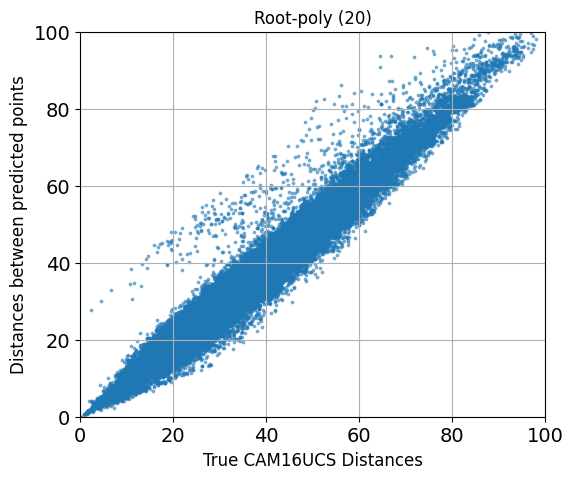

[Root-poly (20)] RMSE train/test: 3.2056/3.4731 | R2: 0.9556/0.9461 | Corr: 0.9979/0.9974 | STRESS: 0.0785/0.0875 |  spearman: 0.9973/0.9965 


In [27]:
m_rootpoly, reg_rp = eval_reg(X_rootpoly, Y, "Root-poly (20)", save=True)

# Зависимость качества от размера тестовой выборки, RGB ROOT POLY


--- Test size: 0.1 ---


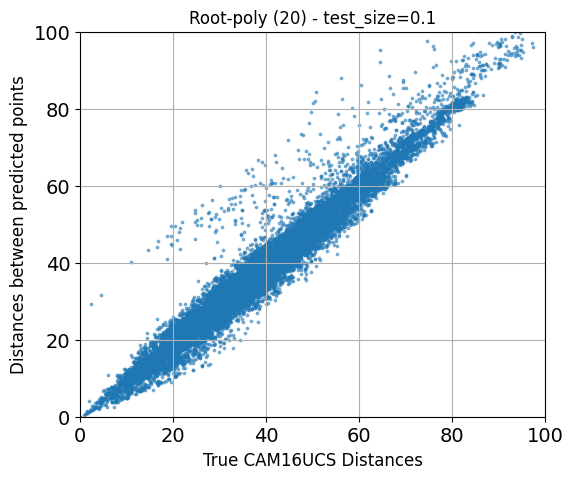

[Root-poly (20) - test_size=0.1] RMSE train/test: 3.2079/3.8339 | R2: 0.9553/0.9351 | Corr: 0.9979/0.9967 | STRESS: 0.0786/0.0984 |  spearman: 0.9973/0.9957 

--- Test size: 0.2 ---


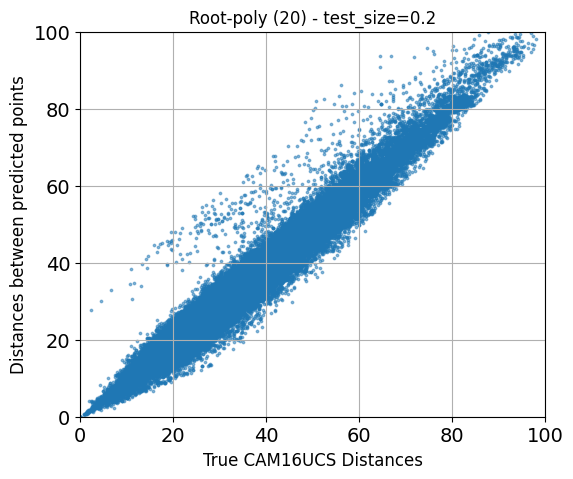

[Root-poly (20) - test_size=0.2] RMSE train/test: 3.2056/3.4731 | R2: 0.9556/0.9461 | Corr: 0.9979/0.9974 | STRESS: 0.0785/0.0875 |  spearman: 0.9973/0.9965 

--- Test size: 0.3 ---


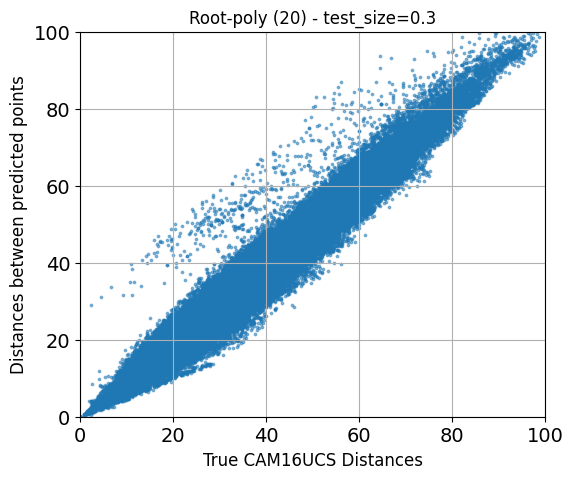

[Root-poly (20) - test_size=0.3] RMSE train/test: 3.1813/3.4292 | R2: 0.9558/0.9490 | Corr: 0.9980/0.9975 | STRESS: 0.0782/0.0849 |  spearman: 0.9974/0.9966 

--- Test size: 0.4 ---


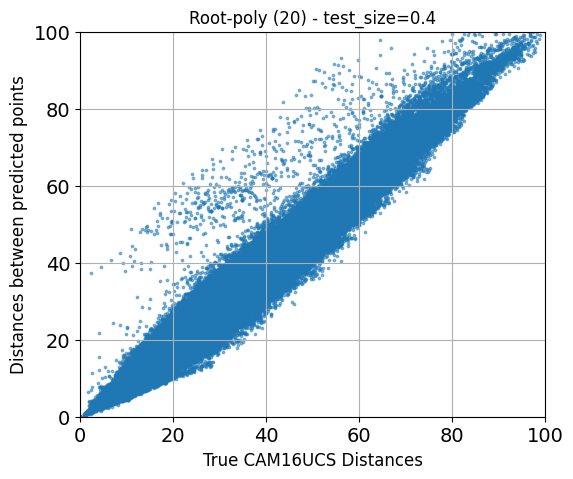

[Root-poly (20) - test_size=0.4] RMSE train/test: 3.1924/3.3996 | R2: 0.9555/0.9492 | Corr: 0.9980/0.9974 | STRESS: 0.0786/0.0844 |  spearman: 0.9972/0.9967 

--- Test size: 0.5 ---


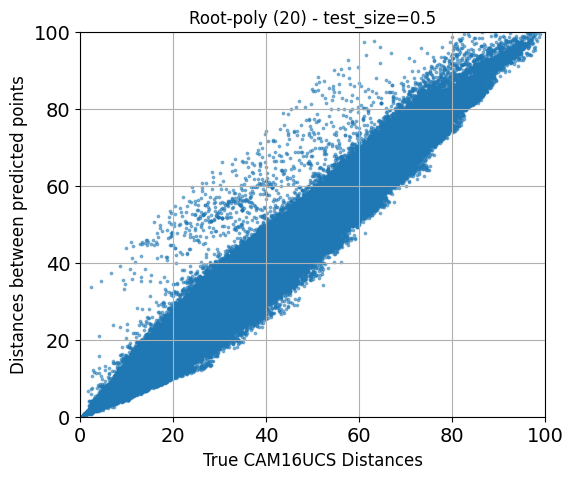

[Root-poly (20) - test_size=0.5] RMSE train/test: 3.1718/3.3712 | R2: 0.9566/0.9501 | Corr: 0.9980/0.9975 | STRESS: 0.0778/0.0835 |  spearman: 0.9972/0.9969 

--- Test size: 0.6 ---


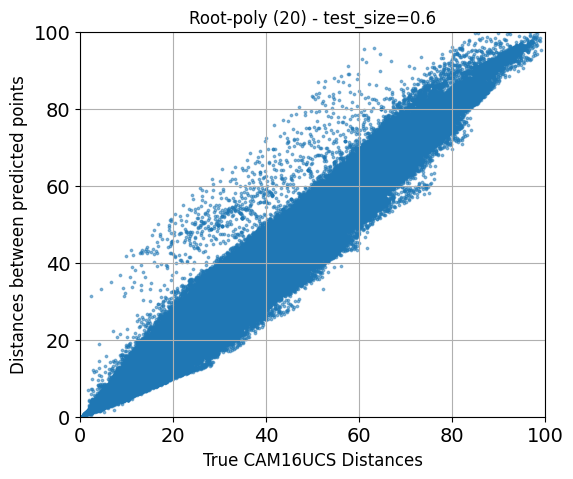

[Root-poly (20) - test_size=0.6] RMSE train/test: 3.1665/3.3547 | R2: 0.9581/0.9497 | Corr: 0.9980/0.9976 | STRESS: 0.0771/0.0833 |  spearman: 0.9973/0.9970 

--- Test size: 0.7 ---


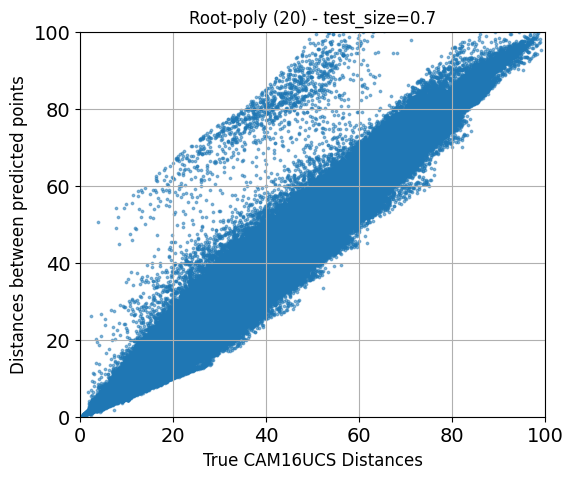

[Root-poly (20) - test_size=0.7] RMSE train/test: 3.2233/3.5214 | R2: 0.9572/0.9419 | Corr: 0.9979/0.9974 | STRESS: 0.0780/0.0898 |  spearman: 0.9973/0.9967 

--- Test size: 0.8 ---


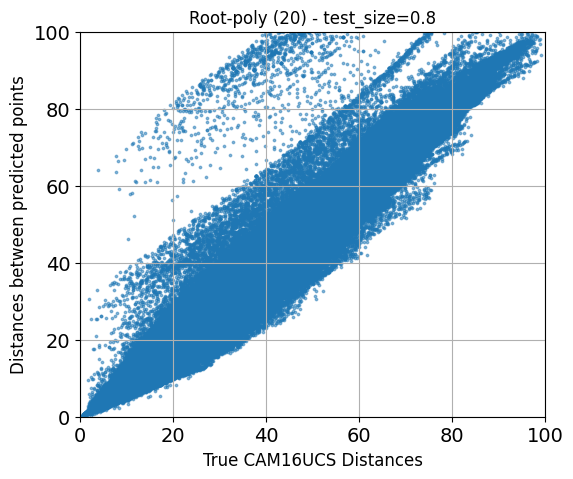

[Root-poly (20) - test_size=0.8] RMSE train/test: 3.0794/3.8202 | R2: 0.9631/0.9281 | Corr: 0.9980/0.9969 | STRESS: 0.0733/0.0997 |  spearman: 0.9971/0.9961 

--- Test size: 0.9 ---


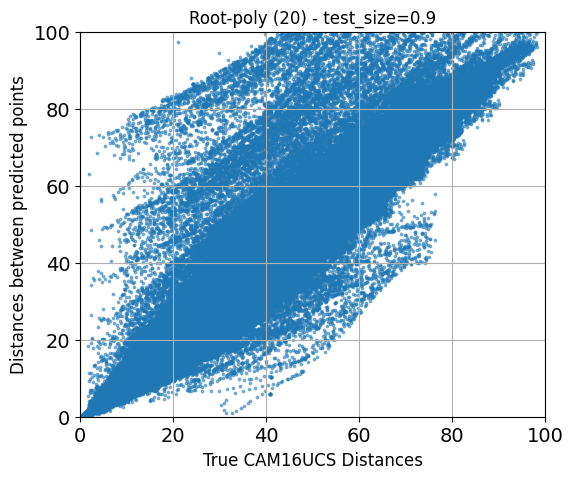

[Root-poly (20) - test_size=0.9] RMSE train/test: 2.8408/9.8184 | R2: 0.9682/0.3701 | Corr: 0.9984/0.9824 | STRESS: 0.0682/0.2754 |  spearman: 0.9977/0.9947 


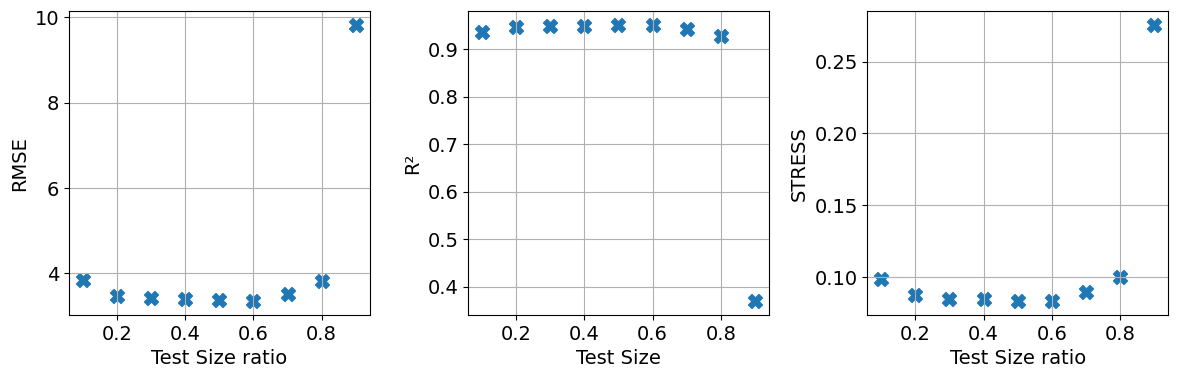

In [28]:
# Dependence of metrics on test size for root poly

METRICS_BY_TEST_SIZE = {}
for test_size in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    print(f"\n--- Test size: {test_size} ---")
    METRICS_BY_TEST_SIZE[test_size], reg_rp = eval_reg(X_rootpoly, Y, test_size=test_size, name=f"Root-poly (20) - test_size={test_size}")
# final plot of test size vs metrics for root poly
test_sizes = list(METRICS_BY_TEST_SIZE.keys())
rmse_tests = [METRICS_BY_TEST_SIZE[ts]['rmse_test'] for ts in test_sizes]
r2_tests = [METRICS_BY_TEST_SIZE[ts]['r2_test'] for ts in test_sizes]
stress_test = [METRICS_BY_TEST_SIZE[ts]['stress_test'] for ts in test_sizes]   
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.scatter(test_sizes, rmse_tests, marker='X', s = 100)
plt.grid()
plt.xlabel("Test Size ratio")
plt.ylabel("RMSE")
plt.subplot(1, 3, 2)
plt.scatter(test_sizes, r2_tests, marker='X', s = 100)
plt.grid()
plt.xlabel("Test Size")
plt.ylabel("R²")
plt.subplot(1, 3, 3)
plt.scatter(test_sizes, stress_test, marker='X', s = 100)
plt.grid()
plt.xlabel("Test Size ratio")
plt.ylabel("STRESS")
plt.tight_layout()
plt.show()

# Vision ecnoder embeddins: metrics vs test size


--- Test size: 0.1 ---


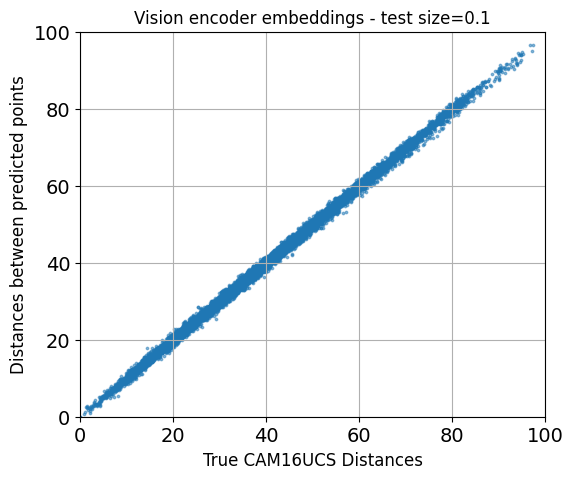

[Vision encoder embeddings - test size=0.1] RMSE train/test: 0.0007/0.7380 | R2: 1.0000/0.9978 | Corr: 1.0000/0.9998 | STRESS: 0.0000/0.0179 |  spearman: 1.0000/0.9997 

--- Test size: 0.2 ---


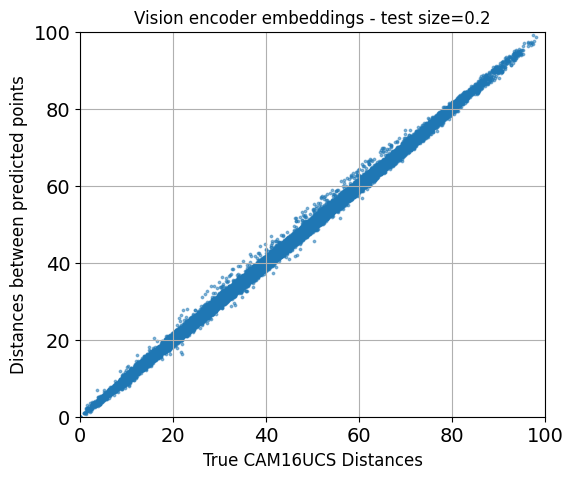

[Vision encoder embeddings - test size=0.2] RMSE train/test: 0.0000/0.6644 | R2: 1.0000/0.9981 | Corr: 1.0000/0.9999 | STRESS: 0.0000/0.0165 |  spearman: 1.0000/0.9998 

--- Test size: 0.3 ---


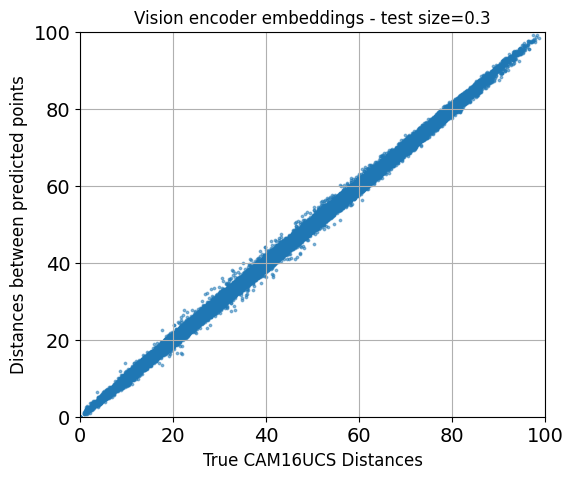

[Vision encoder embeddings - test size=0.3] RMSE train/test: 0.0000/0.6495 | R2: 1.0000/0.9982 | Corr: 1.0000/0.9999 | STRESS: 0.0000/0.0158 |  spearman: 1.0000/0.9998 

--- Test size: 0.4 ---


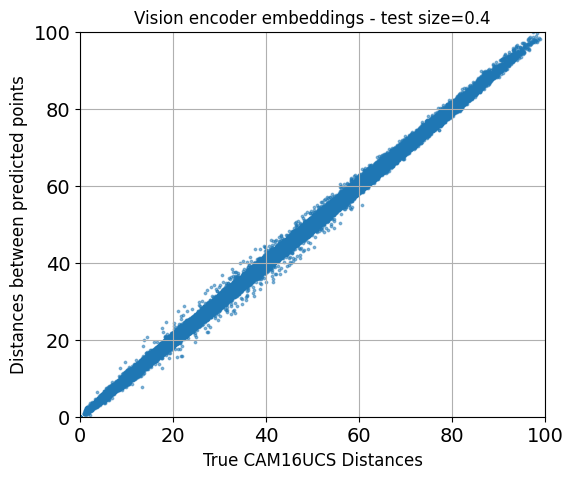

[Vision encoder embeddings - test size=0.4] RMSE train/test: 0.0000/0.6132 | R2: 1.0000/0.9984 | Corr: 1.0000/0.9999 | STRESS: 0.0000/0.0149 |  spearman: 1.0000/0.9998 

--- Test size: 0.5 ---


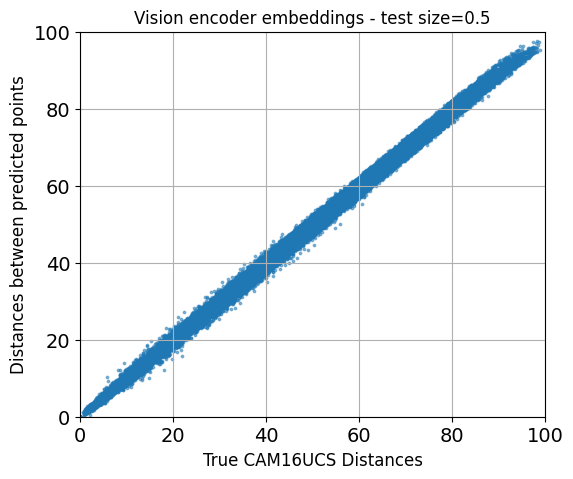

[Vision encoder embeddings - test size=0.5] RMSE train/test: 0.0000/0.6626 | R2: 1.0000/0.9981 | Corr: 1.0000/0.9999 | STRESS: 0.0000/0.0163 |  spearman: 1.0000/0.9998 

--- Test size: 0.6 ---


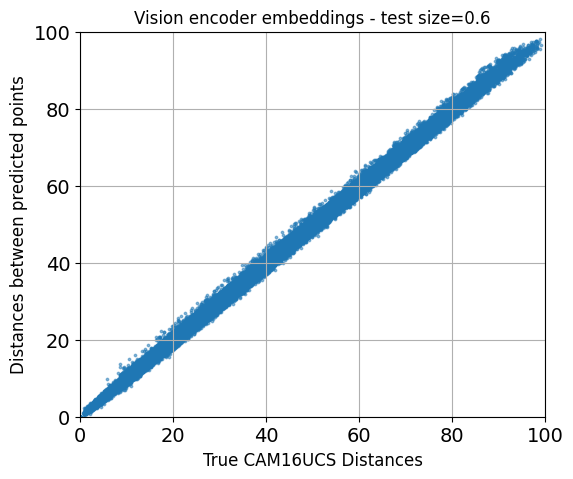

[Vision encoder embeddings - test size=0.6] RMSE train/test: 0.0000/0.6322 | R2: 1.0000/0.9982 | Corr: 1.0000/0.9999 | STRESS: 0.0000/0.0156 |  spearman: 1.0000/0.9998 

--- Test size: 0.7 ---


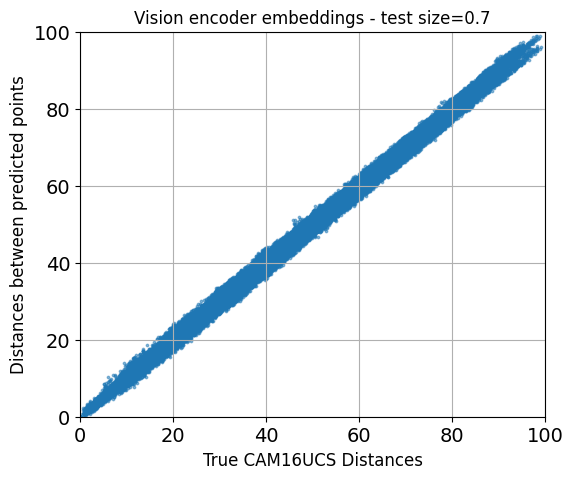

[Vision encoder embeddings - test size=0.7] RMSE train/test: 0.0000/0.6586 | R2: 1.0000/0.9981 | Corr: 1.0000/0.9999 | STRESS: 0.0000/0.0163 |  spearman: 1.0000/0.9998 

--- Test size: 0.8 ---


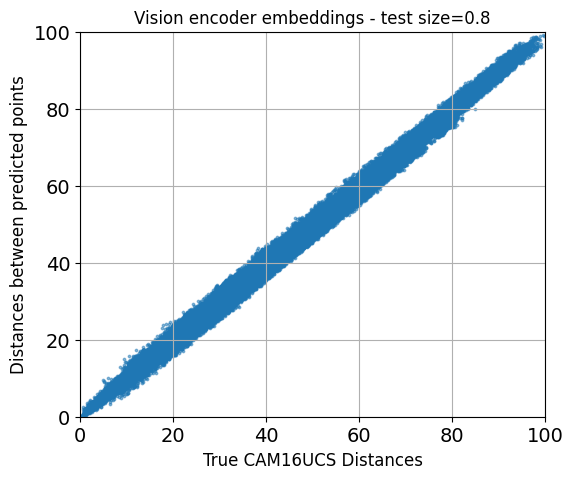

[Vision encoder embeddings - test size=0.8] RMSE train/test: 0.0000/0.7680 | R2: 1.0000/0.9973 | Corr: 1.0000/0.9998 | STRESS: 0.0000/0.0192 |  spearman: 1.0000/0.9998 

--- Test size: 0.9 ---


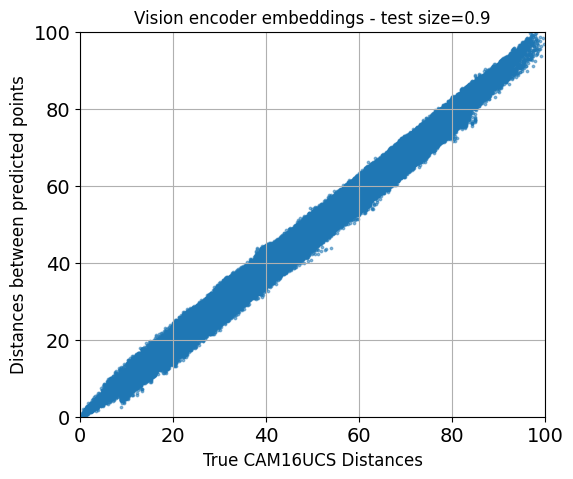

[Vision encoder embeddings - test size=0.9] RMSE train/test: 0.0000/1.0306 | R2: 1.0000/0.9950 | Corr: 1.0000/0.9997 | STRESS: 0.0000/0.0263 |  spearman: 1.0000/0.9997 


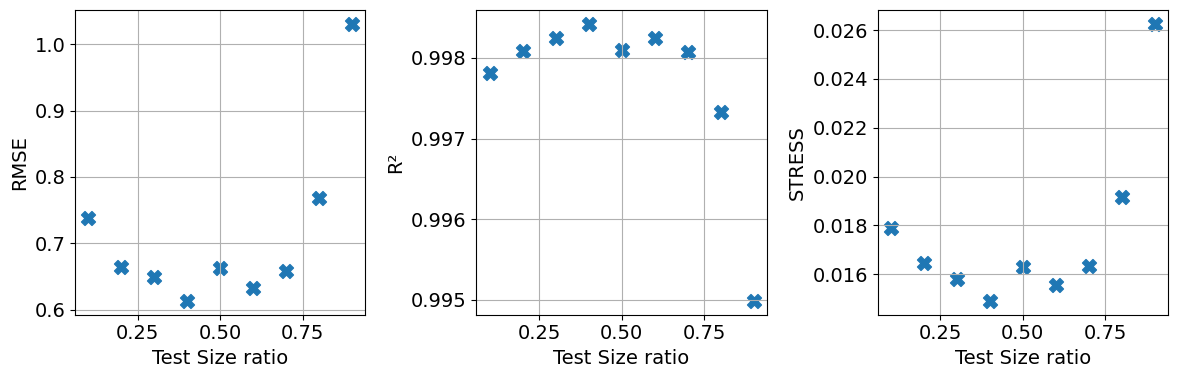

In [29]:
# Dependence of metrics on test size for root poly

METRICS_BY_TEST_SIZE = {}
for test_size in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    print(f"\n--- Test size: {test_size} ---")
    METRICS_BY_TEST_SIZE[test_size], reg_rp = eval_reg(vl, Y, test_size=test_size, name=f"Vision encoder embeddings - test size={test_size}")
# final plot of test size vs metrics for root poly
test_sizes = list(METRICS_BY_TEST_SIZE.keys())
rmse_tests = [METRICS_BY_TEST_SIZE[ts]['rmse_test'] for ts in test_sizes]
r2_tests = [METRICS_BY_TEST_SIZE[ts]['r2_test'] for ts in test_sizes]
stress_tests = [METRICS_BY_TEST_SIZE[ts]['stress_test'] for ts in test_sizes]   
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.scatter(test_sizes, rmse_tests, marker='X', s = 100)
plt.grid()
plt.xlabel("Test Size ratio")
plt.ylabel("RMSE")
plt.subplot(1, 3, 2)
plt.scatter(test_sizes, r2_tests, marker='X', s = 100)
plt.grid()
plt.xlabel("Test Size ratio")
plt.ylabel("R²")
plt.subplot(1, 3, 3)
plt.scatter(test_sizes, stress_tests, marker='X', s = 100)
plt.grid()
plt.xlabel("Test Size ratio")
plt.ylabel("STRESS")
plt.tight_layout()
plt.show()

# Language model embeddins vs test size


--- Test size: 0.1 ---


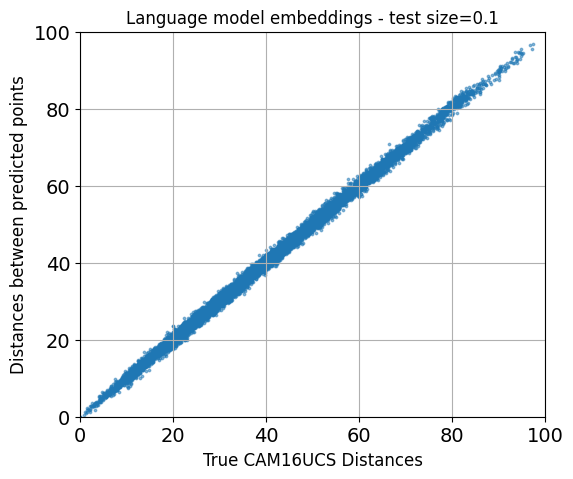

[Language model embeddings - test size=0.1] RMSE train/test: 0.0007/0.8431 | R2: 1.0000/0.9971 | Corr: 1.0000/0.9998 | STRESS: 0.0000/0.0205 |  spearman: 1.0000/0.9997 

--- Test size: 0.2 ---


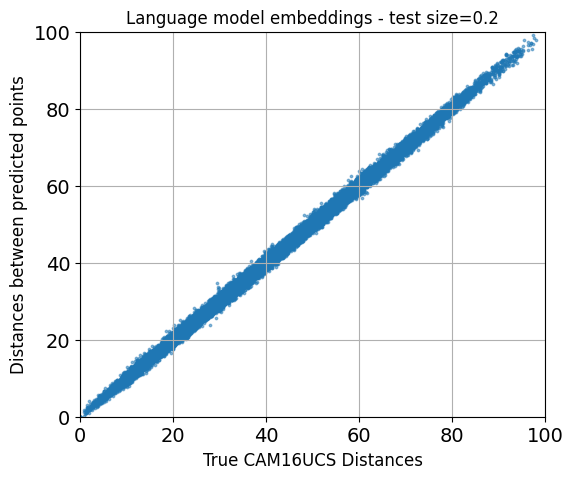

[Language model embeddings - test size=0.2] RMSE train/test: 0.0000/0.7583 | R2: 1.0000/0.9976 | Corr: 1.0000/0.9999 | STRESS: 0.0000/0.0183 |  spearman: 1.0000/0.9998 

--- Test size: 0.3 ---


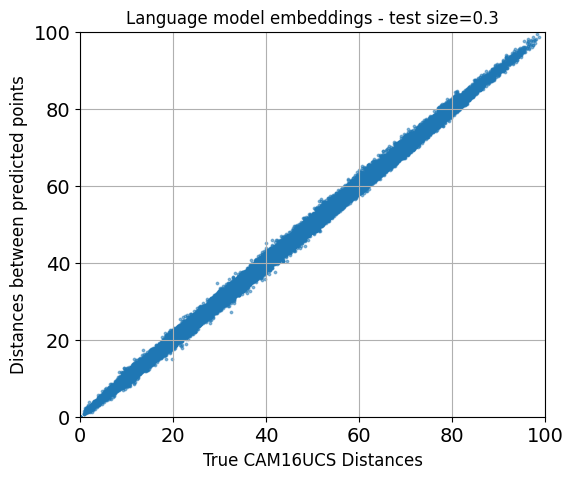

[Language model embeddings - test size=0.3] RMSE train/test: 0.0000/0.7370 | R2: 1.0000/0.9977 | Corr: 1.0000/0.9999 | STRESS: 0.0000/0.0178 |  spearman: 1.0000/0.9998 

--- Test size: 0.4 ---


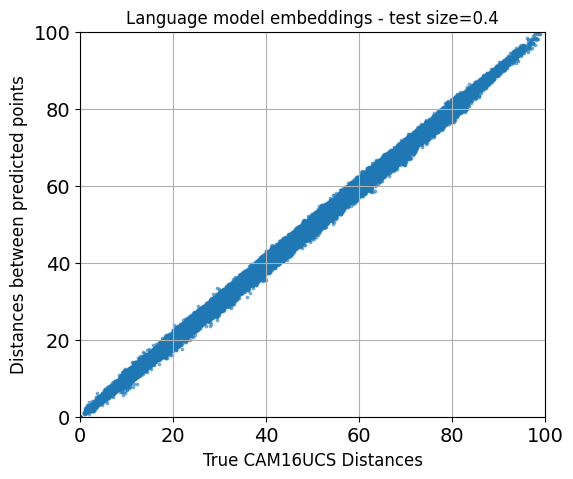

[Language model embeddings - test size=0.4] RMSE train/test: 0.0000/0.6991 | R2: 1.0000/0.9979 | Corr: 1.0000/0.9999 | STRESS: 0.0000/0.0171 |  spearman: 1.0000/0.9998 

--- Test size: 0.5 ---


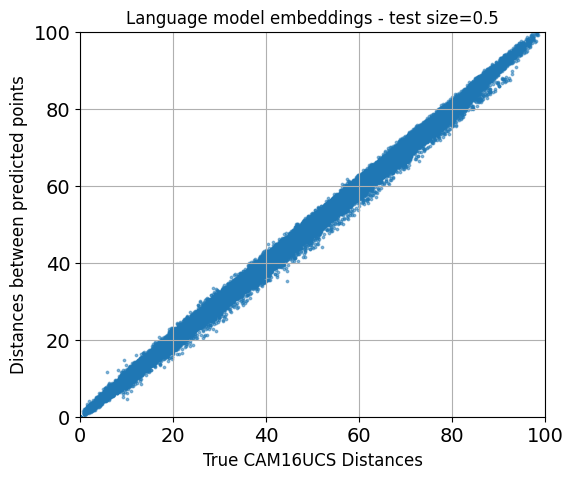

[Language model embeddings - test size=0.5] RMSE train/test: 0.0000/0.7144 | R2: 1.0000/0.9978 | Corr: 1.0000/0.9999 | STRESS: 0.0000/0.0177 |  spearman: 1.0000/0.9998 

--- Test size: 0.6 ---


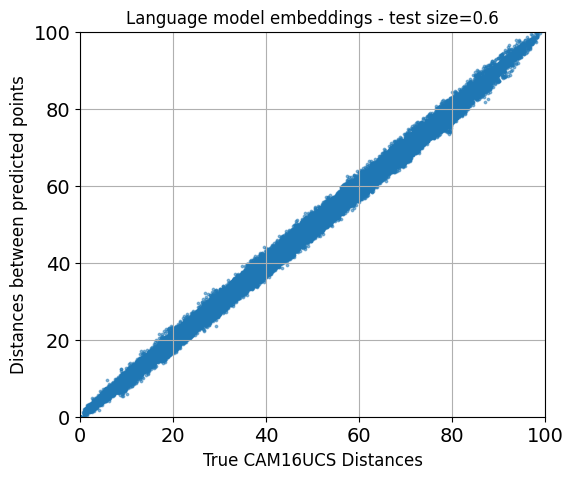

[Language model embeddings - test size=0.6] RMSE train/test: 0.0000/0.6922 | R2: 1.0000/0.9978 | Corr: 1.0000/0.9999 | STRESS: 0.0000/0.0173 |  spearman: 1.0000/0.9998 

--- Test size: 0.7 ---


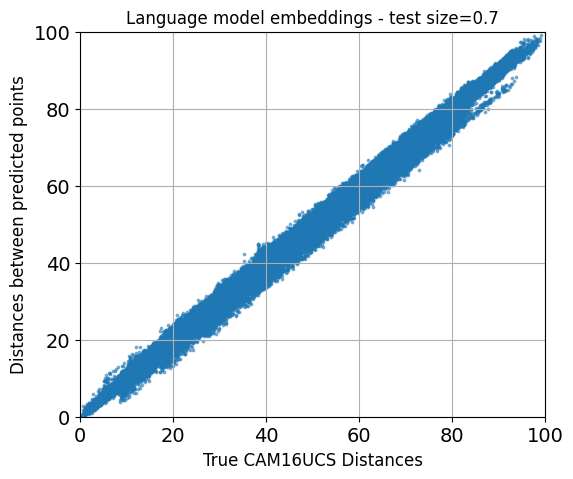

[Language model embeddings - test size=0.7] RMSE train/test: 0.0000/0.8152 | R2: 1.0000/0.9969 | Corr: 1.0000/0.9998 | STRESS: 0.0000/0.0208 |  spearman: 1.0000/0.9998 

--- Test size: 0.8 ---


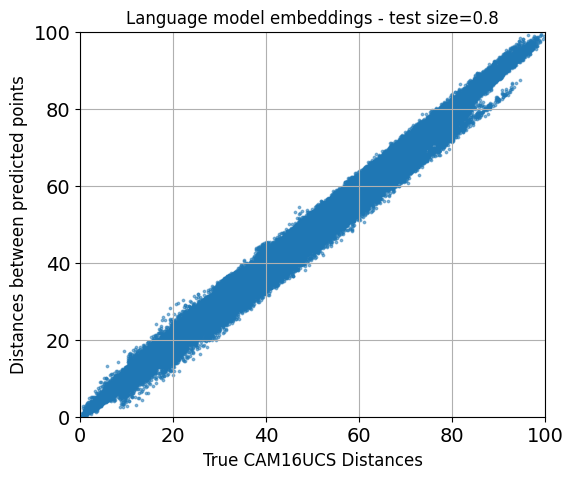

[Language model embeddings - test size=0.8] RMSE train/test: 0.0000/0.9627 | R2: 1.0000/0.9955 | Corr: 1.0000/0.9998 | STRESS: 0.0000/0.0244 |  spearman: 1.0000/0.9997 

--- Test size: 0.9 ---


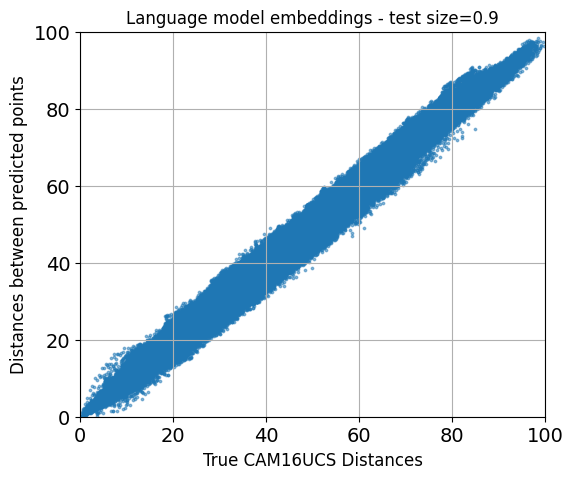

[Language model embeddings - test size=0.9] RMSE train/test: 0.0000/1.1880 | R2: 1.0000/0.9935 | Corr: 1.0000/0.9996 | STRESS: 0.0000/0.0300 |  spearman: 1.0000/0.9995 


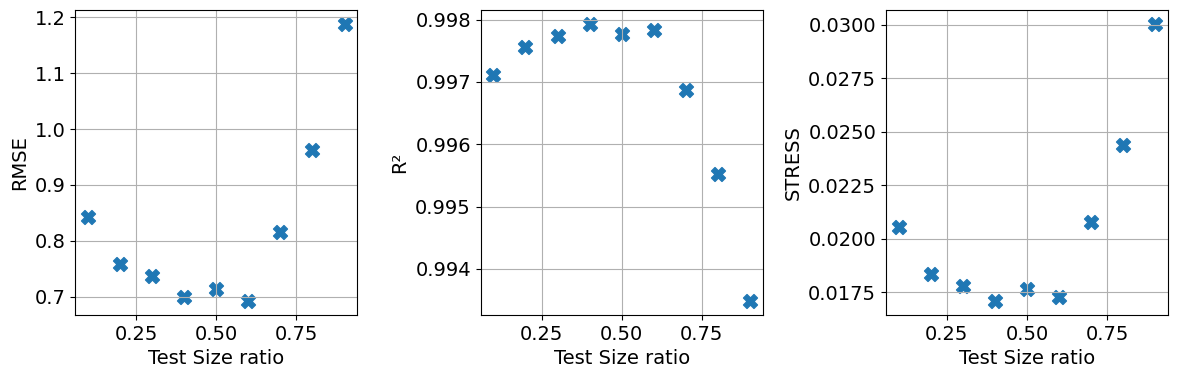

In [30]:
# Dependence of metrics on test size for root poly

METRICS_BY_TEST_SIZE = {}
for test_size in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    print(f"\n--- Test size: {test_size} ---")
    METRICS_BY_TEST_SIZE[test_size], reg_rp = eval_reg(lm, Y, test_size=test_size, name=f"Language model embeddings - test size={test_size}")
# final plot of test size vs metrics for root poly
test_sizes = list(METRICS_BY_TEST_SIZE.keys())
rmse_tests = [METRICS_BY_TEST_SIZE[ts]['rmse_test'] for ts in test_sizes]
r2_tests = [METRICS_BY_TEST_SIZE[ts]['r2_test'] for ts in test_sizes]
stress_tests = [METRICS_BY_TEST_SIZE[ts]['stress_test'] for ts in test_sizes]   
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.scatter(test_sizes, rmse_tests, marker='X', s = 100)
plt.grid()
plt.xlabel("Test Size ratio")
plt.ylabel("RMSE")
plt.subplot(1, 3, 2)
plt.scatter(test_sizes, r2_tests, marker='X', s = 100)
plt.grid()
plt.xlabel("Test Size ratio")
plt.ylabel("R²")
plt.subplot(1, 3, 3)
plt.scatter(test_sizes, stress_tests, marker='X', s = 100)
plt.grid()
plt.xlabel("Test Size ratio")
plt.ylabel("STRESS")
plt.tight_layout()
plt.show()


--- Test size: 0.1 ---
[Language model embeddings - test size=0.1] RMSE train/test: 0.0007/0.8431 | R2: 1.0000/0.9971 | Corr: 1.0000/0.9998 | STRESS: 0.0000/0.0205 |  spearman: 1.0000/0.9997 
[Vision encoder embeddings - test size=0.1] RMSE train/test: 0.0007/0.7380 | R2: 1.0000/0.9978 | Corr: 1.0000/0.9998 | STRESS: 0.0000/0.0179 |  spearman: 1.0000/0.9997 

--- Test size: 0.2 ---
[Language model embeddings - test size=0.2] RMSE train/test: 0.0000/0.7583 | R2: 1.0000/0.9976 | Corr: 1.0000/0.9999 | STRESS: 0.0000/0.0183 |  spearman: 1.0000/0.9998 
[Vision encoder embeddings - test size=0.2] RMSE train/test: 0.0000/0.6644 | R2: 1.0000/0.9981 | Corr: 1.0000/0.9999 | STRESS: 0.0000/0.0165 |  spearman: 1.0000/0.9998 

--- Test size: 0.3 ---
[Language model embeddings - test size=0.3] RMSE train/test: 0.0000/0.7370 | R2: 1.0000/0.9977 | Corr: 1.0000/0.9999 | STRESS: 0.0000/0.0178 |  spearman: 1.0000/0.9998 
[Vision encoder embeddings - test size=0.3] RMSE train/test: 0.0000/0.6495 | R2: 1.

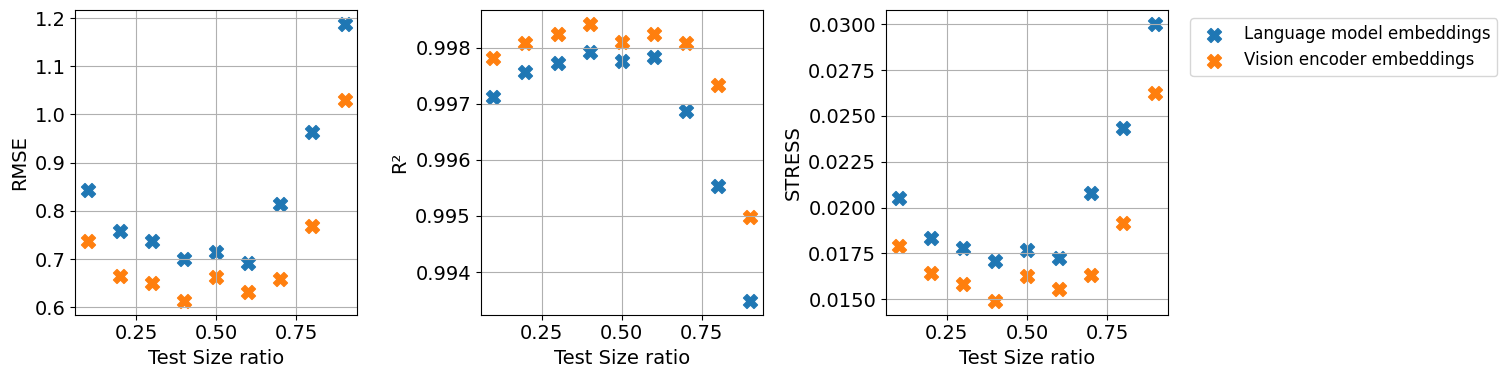

In [31]:
# Dependence of metrics on test size for root poly

METRICS_BY_TEST_SIZE_LM = {}
METRICS_BY_TEST_SIZE_VL = {}
for test_size in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    print(f"\n--- Test size: {test_size} ---")
    METRICS_BY_TEST_SIZE_LM[test_size], reg_rp = eval_reg(lm, Y, test_size=test_size, name=f"Language model embeddings - test size={test_size}", plot=False)
    METRICS_BY_TEST_SIZE_VL[test_size], reg_rp = eval_reg(vl, Y, test_size=test_size, name=f"Vision encoder embeddings - test size={test_size}", plot=False)
# final plot of test size vs metrics for root poly
plt.figure(figsize=(12, 4))
for data_metrcis, name in zip([METRICS_BY_TEST_SIZE_LM, METRICS_BY_TEST_SIZE_VL], ["Language model embeddings", "Vision encoder embeddings"]):
    test_sizes = list(data_metrcis.keys())
    rmse_tests = [data_metrcis[ts]['rmse_test'] for ts in test_sizes]
    r2_tests = [data_metrcis[ts]['r2_test'] for ts in test_sizes]
    stress_tests = [data_metrcis[ts]['stress_test'] for ts in test_sizes]   
    plt.subplot(1, 3, 1)
    plt.scatter(test_sizes, rmse_tests, marker='X', s = 100, label=name)
    plt.grid(True)
    plt.xlabel("Test Size ratio")
    plt.ylabel("RMSE")
    plt.subplot(1, 3, 2)
    plt.scatter(test_sizes, r2_tests, marker='X', s = 100, label = name)
    plt.grid(True)
    plt.xlabel("Test Size ratio")
    plt.ylabel("R²")
    plt.subplot(1, 3, 3)
    plt.scatter(test_sizes, stress_tests, marker='X', s = 100, label=name)
    plt.grid(True)
    plt.xlabel("Test Size ratio")
    plt.ylabel("STRESS")
    plt.tight_layout()
plt.legend(fontsize=12, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# Embeddings (PCA, 99% of dispersion)


--- Test size: 0.1 ---
[Language model  (PCA 27) - test size=0.1] RMSE train/test: 1.8899/1.9979 | R2: 0.9845/0.9830 | Corr: 0.9991/0.9990 | STRESS: 0.0463/0.0499 |  spearman: 0.9987/0.9984 
[Vision encoder (PCA 14) - test size=0.1] RMSE train/test: 1.6928/1.8985 | R2: 0.9876/0.9845 | Corr: 0.9993/0.9991 | STRESS: 0.0415/0.0479 |  spearman: 0.9991/0.9987 

--- Test size: 0.2 ---
[Language model  (PCA 27) - test size=0.2] RMSE train/test: 1.8929/1.9308 | R2: 0.9845/0.9838 | Corr: 0.9991/0.9991 | STRESS: 0.0463/0.0481 |  spearman: 0.9987/0.9986 
[Vision encoder (PCA 14) - test size=0.2] RMSE train/test: 1.6888/1.8063 | R2: 0.9877/0.9858 | Corr: 0.9993/0.9992 | STRESS: 0.0413/0.0450 |  spearman: 0.9991/0.9988 

--- Test size: 0.3 ---
[Language model  (PCA 27) - test size=0.3] RMSE train/test: 1.8757/1.9550 | R2: 0.9846/0.9838 | Corr: 0.9991/0.9990 | STRESS: 0.0461/0.0481 |  spearman: 0.9987/0.9986 
[Vision encoder (PCA 14) - test size=0.3] RMSE train/test: 1.6791/1.7920 | R2: 0.9877/0.98

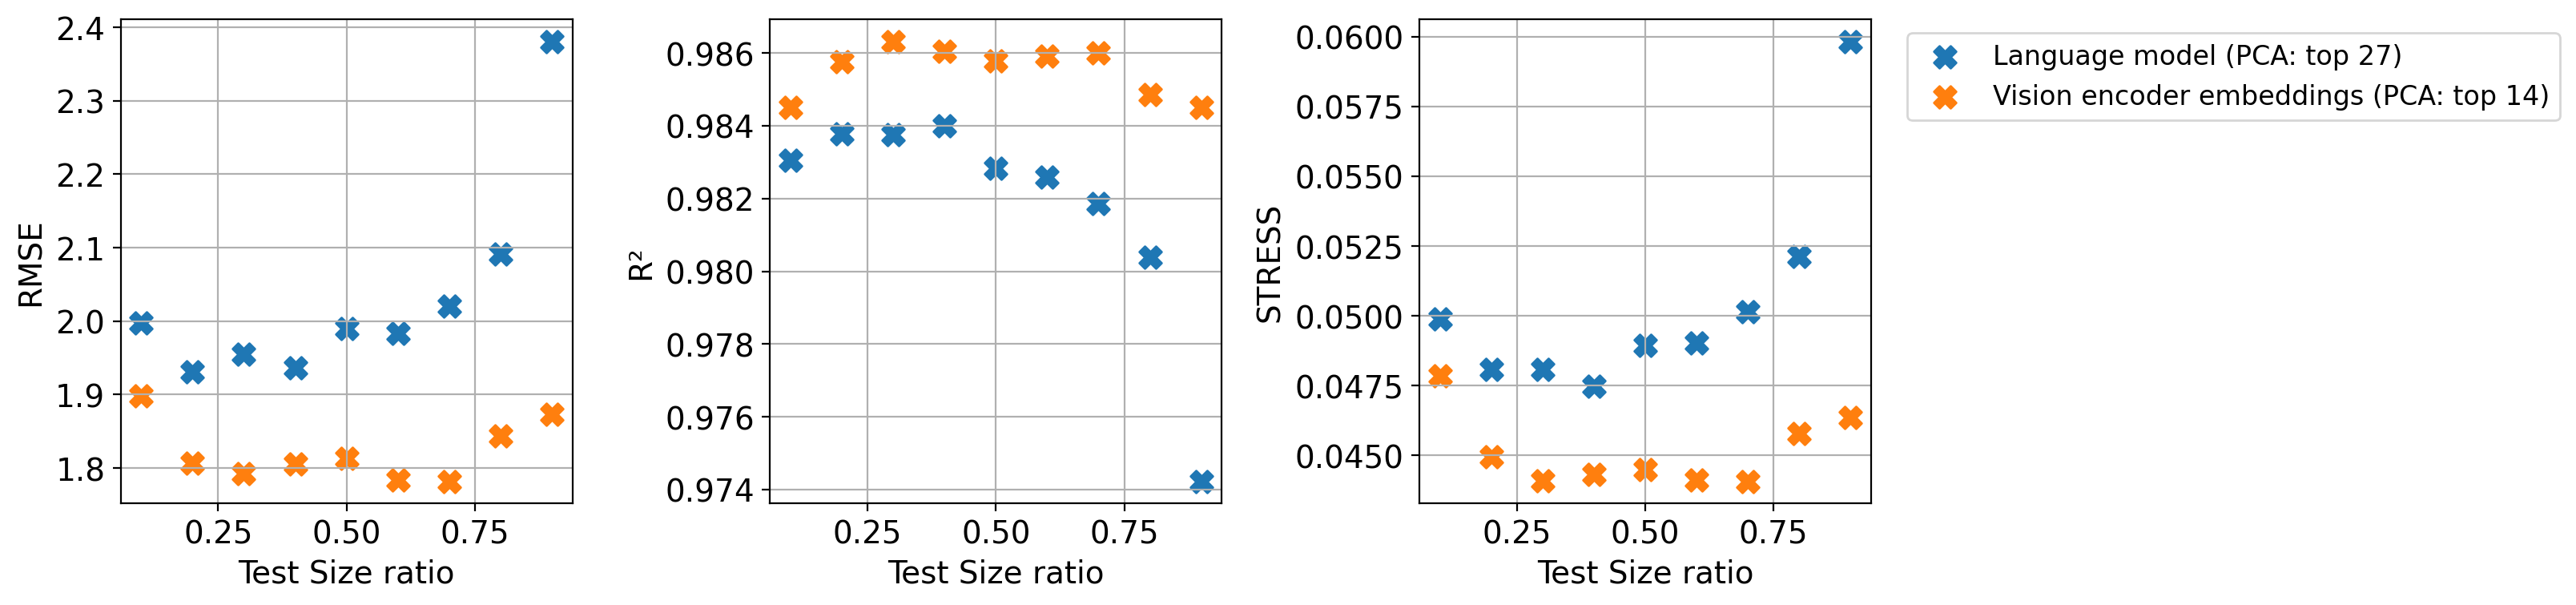

In [32]:
# Dependence of metrics on test size for root poly

METRICS_BY_TEST_SIZE_LM = {}
METRICS_BY_TEST_SIZE_VL = {}
for test_size in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    print(f"\n--- Test size: {test_size} ---")
    METRICS_BY_TEST_SIZE_LM[test_size], reg_rp = eval_reg(lm_pca, Y, test_size=test_size, name=f"Language model  (PCA 27) - test size={test_size}", plot=False)
    METRICS_BY_TEST_SIZE_VL[test_size], reg_rp = eval_reg(vl_pca, Y, test_size=test_size, name=f"Vision encoder (PCA 14) - test size={test_size}", plot=False)
# final plot of test size vs metrics for root poly
plt.figure(figsize=(12, 4), dpi=200)
for data_metrcis, name in zip([METRICS_BY_TEST_SIZE_LM, METRICS_BY_TEST_SIZE_VL], ["Language model (PCA: top 27)", "Vision encoder embeddings (PCA: top 14)"]):
    test_sizes = list(data_metrcis.keys())
    rmse_tests = [data_metrcis[ts]['rmse_test'] for ts in test_sizes]
    r2_tests = [data_metrcis[ts]['r2_test'] for ts in test_sizes]
    stress_tests = [data_metrcis[ts]['stress_test'] for ts in test_sizes]   
    plt.subplot(1, 3, 1)
    plt.scatter(test_sizes, rmse_tests, marker='X', s = 100, label=name)
    plt.grid(True)
    plt.xlabel("Test Size ratio")
    plt.ylabel("RMSE")
    plt.subplot(1, 3, 2)
    plt.scatter(test_sizes, r2_tests, marker='X', s = 100, label = name)
    plt.grid(True)
    plt.xlabel("Test Size ratio")
    plt.ylabel("R²")
    plt.subplot(1, 3, 3)
    plt.scatter(test_sizes, stress_tests, marker='X', s = 100, label=name)
    plt.grid(True)
    plt.xlabel("Test Size ratio")
    plt.ylabel("STRESS")
    plt.tight_layout()
plt.legend(fontsize=12, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# BASELINE: MLP[3,32,128, 128,32,3]

In [33]:
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

def eval_mlp(X, y, name, hidden=(32, 128, 128, 32), lr=1e-3, max_iter=500, seed=42, test_size=0.2, plot=False, save=True, return_points=False):
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=test_size, random_state=seed, shuffle=True)

    mlp = make_pipeline(
        StandardScaler(),
        MLPRegressor(
            hidden_layer_sizes=hidden,
            activation='relu',
            solver='adam',
            alpha=1e-4,
            learning_rate_init=lr,
            max_iter=max_iter,
            batch_size=128,
            random_state=seed,
            early_stopping=True,
            n_iter_no_change=20,
            verbose=False,
        )
    )
    mlp.fit(Xtr, ytr)

    ytr_pred, yte_pred = mlp.predict(Xtr), mlp.predict(Xte)

    # def corr(a, b):
    #     return pearsonr(a.reshape(-1), b.reshape(-1))[0]

    # metrics = dict(
    #     rmse_train = root_mean_squared_error(ytr, ytr_pred),
    #     rmse_test  = root_mean_squared_error(yte, yte_pred),
    #     r2_train   = r2_score(ytr, ytr_pred, multioutput="variance_weighted"),
    #     r2_test    = r2_score(yte, yte_pred, multioutput="variance_weighted"),
    #     corr_train = corr(ytr, ytr_pred),
    #     corr_test  = corr(yte, yte_pred),
    #     model      = mlp,
    # )
    
    def corr(a, b):
        return pearsonr(a.reshape(-1), b.reshape(-1))[0]

    # plot test vs pred distances
    D_true = pairwise_distances(yte, metric="euclidean")
    D_pred = pairwise_distances(yte_pred, metric="euclidean")
    tri = np.triu_indices(D_true.shape[0], k=1)
    
    D_true_train = pairwise_distances(ytr, metric="euclidean")
    D_pred_train = pairwise_distances(ytr_pred, metric="euclidean")
    tri_train = np.triu_indices(D_true_train.shape[0], k=1)
    
    metrics = dict(
        stress_test = safe_stress(D_true, D_pred, ord=2),
        stress_train = safe_stress(D_true_train, D_pred_train, ord=2),
        spearman_test = spearmanr(yte.reshape(-1), yte_pred.reshape(-1))[0],
        spearman_train = spearmanr(ytr.reshape(-1), ytr_pred.reshape(-1))[0],
        rmse_train = root_mean_squared_error(D_true_train, D_pred_train),
        rmse_test  = root_mean_squared_error(D_true, D_pred),
        r2_train   = r2_score(D_true_train, D_pred_train, multioutput="variance_weighted"),
        r2_test    = r2_score(D_true, D_pred, multioutput="variance_weighted"),
        corr_train = corr(ytr, ytr_pred),
        corr_test  = corr(yte, yte_pred),
    )
    if plot:
        plt.figure(figsize=(6, 5))
        plt.grid()
        plt.scatter(D_true[tri], D_pred[tri], s=3, alpha=0.5)
        plt.xlabel("True CAM16UCS Distances", fontsize=12)
        plt.ylabel("Distances between predicted points", fontsize=12)
        plt.title(name, fontsize=14)
        plt.xlim(0, 100)
        plt.ylim(0, 100)
        # save in pdf
        if save:
            plt.savefig(f"{name}_regression.png", dpi=200)
        #plt.title(f"{name} - Test Distances: True vs Predicted, RMSE={metrics['rmse_test']:.4f}, R2={metrics['r2_test']:.4f}, Corr={metrics['corr_test']:.4f}", fontsize=10)
        plt.show()
    
    print(f"[MLP {name}] RMSE train/test: {metrics['rmse_train']:.4f}/{metrics['rmse_test']:.4f} | "
          f"R2: {metrics['r2_train']:.4f}/{metrics['r2_test']:.4f} | "
          f"Corr: {metrics['corr_train']:.4f}/{metrics['corr_test']:.4f} |"
          f"Spearman: {metrics['spearman_train']:.4f}/{metrics['spearman_test']:.4f} |"
          f"STRESS: {metrics['stress_train']:.4f}/{metrics['stress_test']:.4f} |"
          ""
          )
    pred = mlp.predict(X)
    if return_points:
        return metrics, pred, D_true[tri], D_pred[tri]
    return metrics, pred

In [34]:
# Сравнение результатов обучения MLP
mlp_lm     = eval_mlp(lm,      cam, "mlp_lm")
mlp_vl     = eval_mlp(vl,      cam, "mlp_vl")
mlp_lm_pca = eval_mlp(lm_pca,  cam, "mlp_lm_pca")
mlp_vl_pca = eval_mlp(vl_pca,  cam, "mlp_vl_pca")
mlp_rgb = eval_mlp(X_base,  Y, "mlp_rgb")
mlp_rgb_root_poly = eval_mlp(X_rootpoly,  Y, "mlp_root poly")

[MLP mlp_lm] RMSE train/test: 0.6435/0.8915 | R2: 0.9982/0.9965 | Corr: 0.9999/0.9998 |Spearman: 0.9998/0.9997 |STRESS: 0.0156/0.0223 |
[MLP mlp_vl] RMSE train/test: 0.7090/0.8865 | R2: 0.9979/0.9967 | Corr: 0.9999/0.9998 |Spearman: 0.9998/0.9997 |STRESS: 0.0169/0.0213 |
[MLP mlp_lm_pca] RMSE train/test: 1.2022/1.6594 | R2: 0.9938/0.9881 | Corr: 0.9996/0.9992 |Spearman: 0.9995/0.9991 |STRESS: 0.0292/0.0412 |
[MLP mlp_vl_pca] RMSE train/test: 0.9818/1.4809 | R2: 0.9958/0.9903 | Corr: 0.9998/0.9994 |Spearman: 0.9997/0.9993 |STRESS: 0.0241/0.0367 |
[MLP mlp_rgb] RMSE train/test: 0.8226/0.9062 | R2: 0.9970/0.9962 | Corr: 0.9998/0.9998 |Spearman: 0.9997/0.9997 |STRESS: 0.0203/0.0231 |
[MLP mlp_root poly] RMSE train/test: 0.7934/0.9096 | R2: 0.9972/0.9963 | Corr: 0.9998/0.9998 |Spearman: 0.9997/0.9996 |STRESS: 0.0196/0.0229 |



--- Test size: 0.1 ---
[MLP RGB + MLP - test_size=0.1] RMSE train/test: 0.7590/0.9082 | R2: 0.9974/0.9962 | Corr: 0.9998/0.9998 |Spearman: 0.9997/0.9996 |STRESS: 0.0188/0.0236 |

--- Test size: 0.2 ---
[MLP RGB + MLP - test_size=0.2] RMSE train/test: 0.8226/0.9062 | R2: 0.9970/0.9962 | Corr: 0.9998/0.9998 |Spearman: 0.9997/0.9997 |STRESS: 0.0203/0.0231 |

--- Test size: 0.3 ---
[MLP RGB + MLP - test_size=0.3] RMSE train/test: 0.8156/0.8606 | R2: 0.9971/0.9968 | Corr: 0.9998/0.9998 |Spearman: 0.9997/0.9996 |STRESS: 0.0202/0.0213 |

--- Test size: 0.4 ---
[MLP RGB + MLP - test_size=0.4] RMSE train/test: 0.8918/0.9143 | R2: 0.9965/0.9964 | Corr: 0.9998/0.9998 |Spearman: 0.9996/0.9996 |STRESS: 0.0221/0.0227 |

--- Test size: 0.5 ---
[MLP RGB + MLP - test_size=0.5] RMSE train/test: 0.8117/0.8570 | R2: 0.9971/0.9967 | Corr: 0.9998/0.9998 |Spearman: 0.9997/0.9997 |STRESS: 0.0202/0.0214 |

--- Test size: 0.6 ---
[MLP RGB + MLP - test_size=0.6] RMSE train/test: 1.0981/1.1541 | R2: 0.9949/0.994

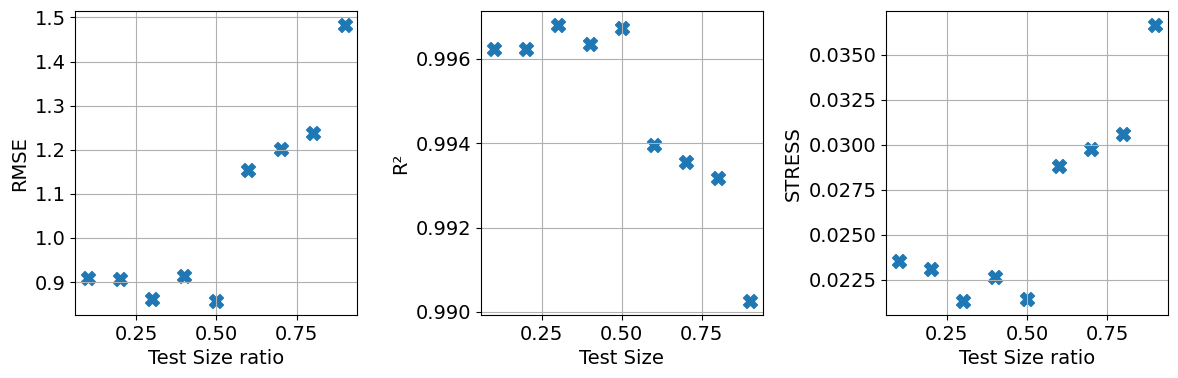

In [35]:
# Dependence of metrics on test size for root poly

METRICS_BY_TEST_SIZE = {}
for test_size in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    print(f"\n--- Test size: {test_size} ---")
    METRICS_BY_TEST_SIZE[test_size], _ = eval_mlp(X_base, Y, test_size=test_size, name=f"RGB + MLP - test_size={test_size}")
# final plot of test size vs metrics for root poly
test_sizes = list(METRICS_BY_TEST_SIZE.keys())
rmse_tests = [METRICS_BY_TEST_SIZE[ts]['rmse_test'] for ts in test_sizes]
r2_tests = [METRICS_BY_TEST_SIZE[ts]['r2_test'] for ts in test_sizes]
stress_test = [METRICS_BY_TEST_SIZE[ts]['stress_test'] for ts in test_sizes]   
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.scatter(test_sizes, rmse_tests, marker='X', s = 100)
plt.grid()
plt.xlabel("Test Size ratio")
plt.ylabel("RMSE")
plt.subplot(1, 3, 2)
plt.scatter(test_sizes, r2_tests, marker='X', s = 100)
plt.grid()
plt.xlabel("Test Size")
plt.ylabel("R²")
plt.subplot(1, 3, 3)
plt.scatter(test_sizes, stress_test, marker='X', s = 100)
plt.grid()
plt.xlabel("Test Size ratio")
plt.ylabel("STRESS")
plt.tight_layout()
plt.show()

# Визуализация цветов

[rootpoly] RMSE train/test: 3.2056/3.4731 | R2: 0.9556/0.9461 | Corr: 0.9979/0.9974 | STRESS: 0.0785/0.0875 |  spearman: 0.9973/0.9965 
[vl] RMSE train/test: 0.0000/0.6644 | R2: 1.0000/0.9981 | Corr: 1.0000/0.9999 | STRESS: 0.0000/0.0165 |  spearman: 1.0000/0.9998 
[lm] RMSE train/test: 0.0000/0.7583 | R2: 1.0000/0.9976 | Corr: 1.0000/0.9999 | STRESS: 0.0000/0.0183 |  spearman: 1.0000/0.9998 
[MLP mlp] RMSE train/test: 0.8226/0.9062 | R2: 0.9970/0.9962 | Corr: 0.9998/0.9998 |Spearman: 0.9997/0.9997 |STRESS: 0.0203/0.0231 |


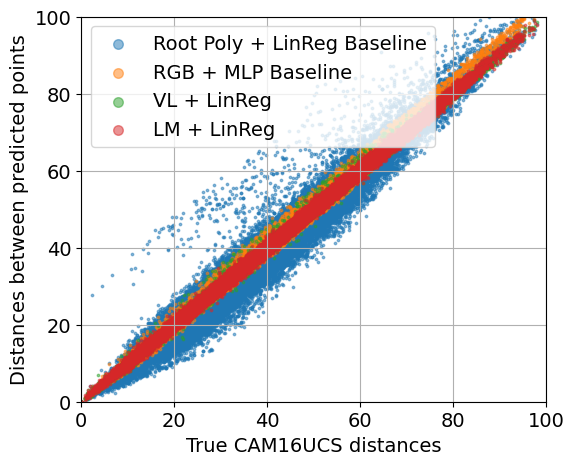

In [36]:
_, rootpoly_pred, root_x, root_y = eval_reg(X_rootpoly, cam, name="rootpoly", return_points=True, plot=False)
_, vl_pred, vl_x, vl_y = eval_reg(vl, cam, name="vl", return_points=True, plot=False)
_, lm_pred, lm_x, lm_y = eval_reg(lm, cam, name="lm", return_points=True, plot=False)
_, mlp_pred, mlp_x, mlp_y = eval_mlp(X_base, cam, name="mlp", plot=False, return_points=True)

plt.figure(figsize=(6, 5))
plt.grid()
plt.scatter(root_x, root_y, s=3, alpha=0.5, label="Root Poly + LinReg Baseline")
plt.scatter(mlp_x, mlp_y, s=3, alpha=0.5, label = "RGB + MLP Baseline")
plt.scatter(vl_x, vl_y, s=3, alpha=0.5, label = "VL + LinReg")
plt.scatter(lm_x, lm_y, s=3, alpha=0.5, label = "LM + LinReg")
plt.xlabel("True CAM16UCS distances", fontsize=14)
plt.ylabel("Distances between predicted points", fontsize=14)
# Create legend
plt.legend(fontsize=14, markerscale=4)

plt.xlim(0, 100)
plt.ylim(0, 100)
# save in pdf
plt.savefig(f"comparison_regression.png", dpi=200)
#plt.title(f"{name} - Test Distances: True vs Predicted, RMSE={metrics['rmse_test']:.4f}, R2={metrics['r2_test']:.4f}, Corr={metrics['corr_test']:.4f}", fontsize=10)
plt.show()

In [40]:
import matplotlib.pyplot as plt
import numpy as np
from colour import CAM16UCS_to_XYZ, XYZ_to_sRGB

# Ground truth RGB
gt_RGB = X_base
indexes_to_compare = [1273, 1, 124]

# Prepare predictions and model names
predictions = [vl_pred, lm_pred]
model_names = ["VL + LinReg", "LM + LinReg"]

In [41]:
all_colors = analyzer.chain_loader.get_all_available_colors()
hcv_all = [(raw["H"],raw["C"],raw["V"]) for raw in all_colors]

# Анализ ошибок

--- Pearson Correlation with dE ---
VL + LinReg:
  Correlation with Chroma (C): 0.065
  Correlation with Value (V):  0.049
LM + LinReg:
  Correlation with Chroma (C): 0.022
  Correlation with Value (V):  0.043
-----------------------------------


/var/folders/4m/l3r2f5js3z959cxtw9_5q5pr0000gn/T/ipykernel_77979/4274690484.py:71: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1.5}` instead.

  sns.pointplot(data=df, x='Value', y='dE', hue='Model', palette=palette,
/var/folders/4m/l3r2f5js3z959cxtw9_5q5pr0000gn/T/ipykernel_77979/4274690484.py:79: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1.5}` instead.

  sns.pointplot(data=df, x='Chroma', y='dE', hue='Model', palette=palette,


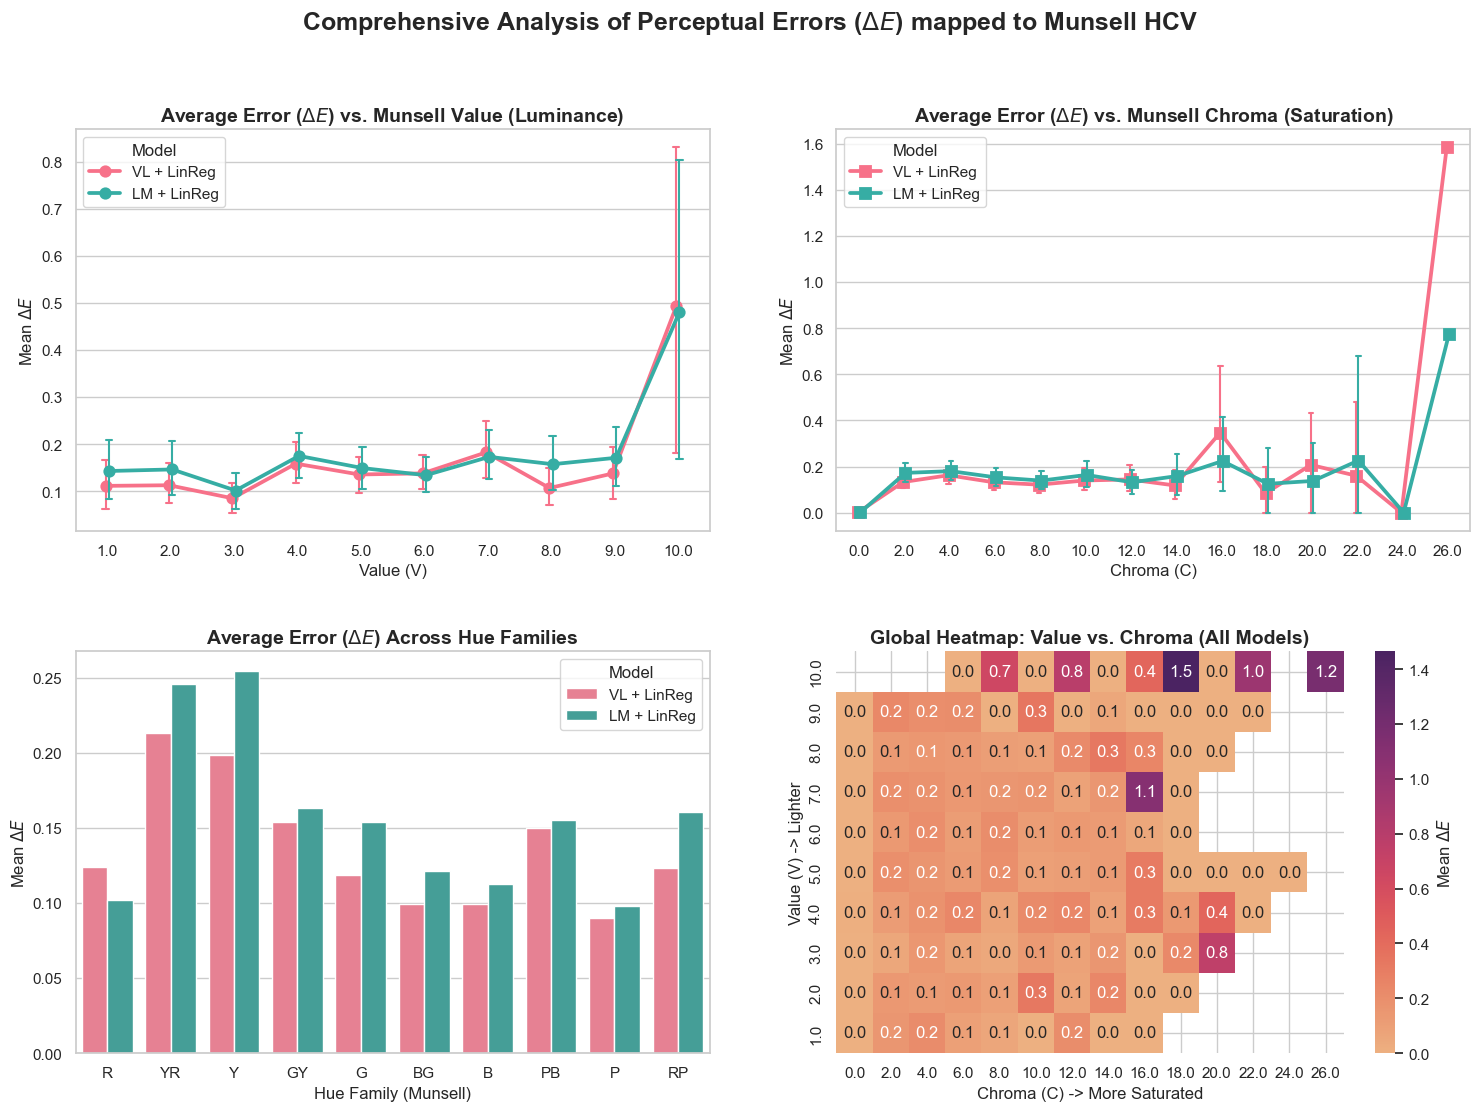

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# ---------------------------------------------------------
# 1. DATA PREPARATION
# ---------------------------------------------------------

# Create a list to hold all records
data_records = []

for j, model_name in enumerate(model_names):
    for idx, (h, c, v) in enumerate(hcv_all):
        # Calculate dE using L2 norm (as in your original code)
        de = np.linalg.norm(Y[idx] - predictions[j][idx], ord=2)
        
        # Clean Hue string (Extract the main color family, e.g., '2.5R' -> 'R')
        # Handle 'N' (Neutral) as well
        if h == 'N':
            hue_family = 'N'
        else:
            hue_family = re.sub(r'[0-9.]', '', h)
            
        data_records.append({
            'Model': model_name,
            'Index': idx,
            'Hue_Raw': h,
            'Hue_Family': hue_family,
            'Chroma': float(c),
            'Value': float(v),
            'dE': de
        })

# Convert to DataFrame
df = pd.DataFrame(data_records)

# Define standard Munsell Hue order for logical plotting
munsell_order = ['R', 'YR', 'Y', 'GY', 'G', 'BG', 'B', 'PB', 'P', 'RP', 'N']
valid_hues = [h for h in munsell_order if h in df['Hue_Family'].unique()]

# ---------------------------------------------------------
# 2. STATISTICAL CORRELATION
# ---------------------------------------------------------

print("--- Pearson Correlation with dE ---")
for model in model_names:
    model_df = df[df['Model'] == model]
    corr_c = model_df['Chroma'].corr(model_df['dE'])
    corr_v = model_df['Value'].corr(model_df['dE'])
    print(f"{model}:")
    print(f"  Correlation with Chroma (C): {corr_c:.3f}")
    print(f"  Correlation with Value (V):  {corr_v:.3f}")
print("-----------------------------------")

# ---------------------------------------------------------
# 3. VISUALIZATION DASHBOARD
# ---------------------------------------------------------

# Set aesthetic style
sns.set_theme(style="whitegrid")
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.2)

# Color palette for models
palette = sns.color_palette("husl", len(model_names))

# Plot 1: Error vs. Value (V) - Line/Point Plot
ax1 = fig.add_subplot(gs[0, 0])
sns.pointplot(data=df, x='Value', y='dE', hue='Model', palette=palette, 
              dodge=True, markers='o', errwidth=1.5, capsize=0.1, ax=ax1)
ax1.set_title(r'Average Error ($\Delta E$) vs. Munsell Value (Luminance)', fontsize=14, fontweight='bold')
ax1.set_ylabel(r'Mean $\Delta E$')
ax1.set_xlabel('Value (V)')

# Plot 2: Error vs. Chroma (C) - Line/Point Plot
ax2 = fig.add_subplot(gs[0, 1])
sns.pointplot(data=df, x='Chroma', y='dE', hue='Model', palette=palette, 
              dodge=True, markers='s', errwidth=1.5, capsize=0.1, ax=ax2)
ax2.set_title(r'Average Error ($\Delta E$) vs. Munsell Chroma (Saturation)', fontsize=14, fontweight='bold')
ax2.set_ylabel(r'Mean $\Delta E$')
ax2.set_xlabel('Chroma (C)')

# Plot 3: Error vs. Hue (H) - Bar Plot
ax3 = fig.add_subplot(gs[1, 0])
sns.barplot(data=df, x='Hue_Family', y='dE', hue='Model', palette=palette, 
            order=valid_hues, errorbar=None, ax=ax3)
ax3.set_title(r'Average Error ($\Delta E$) Across Hue Families', fontsize=14, fontweight='bold')
ax3.set_ylabel(r'Mean $\Delta E$')
ax3.set_xlabel('Hue Family (Munsell)')

# Plot 4: Heatmap of V vs C (Averaged across all models)
ax4 = fig.add_subplot(gs[1, 1])
heatmap_data = df.pivot_table(values='dE', index='Value', columns='Chroma', aggfunc='mean')
# Reverse the y-axis so higher values (lighter colors) are at the top
heatmap_data = heatmap_data.sort_index(ascending=False) 
sns.heatmap(heatmap_data, cmap='flare', annot=True, fmt=".1f", cbar_kws={'label': r'Mean $\Delta E$'}, ax=ax4)
ax4.set_title(r'Global Heatmap: Value vs. Chroma (All Models)', fontsize=14, fontweight='bold')
ax4.set_ylabel('Value (V) -> Lighter')
ax4.set_xlabel('Chroma (C) -> More Saturated')

# Add an overall title
fig.suptitle(r'Comprehensive Analysis of Perceptual Errors ($\Delta E$) mapped to Munsell HCV', 
             fontsize=18, fontweight='bold', y=0.98)

# Save and Show
plt.savefig("hcv_error_analysis.pdf", format="pdf", dpi=300, bbox_inches='tight')
plt.show()

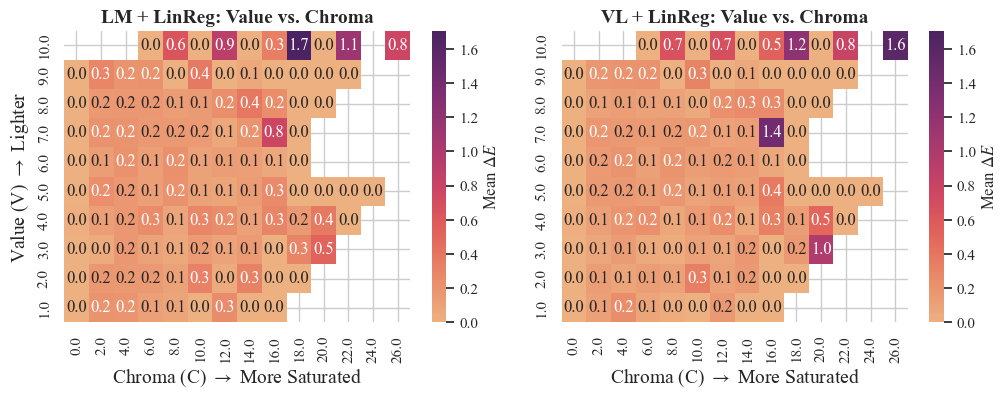

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# ---------------------------------------------------------
# 1. DATA PREPARATION
# ---------------------------------------------------------

data_records = []

for j, model_name in enumerate(model_names):
    for idx, (h, c, v) in enumerate(hcv_all):
        # Calculate dE using L2 norm
        de = np.linalg.norm(Y[idx] - predictions[j][idx], ord=2)
        
        # Clean Hue string (Extract the main color family, e.g., '2.5R' -> 'R')
        if h == 'N':
            hue_family = 'N'
        else:
            hue_family = re.sub(r'[0-9.]', '', h)
            
        data_records.append({
            'Model': model_name,
            'Index': idx,
            'Hue_Raw': h,
            'Hue_Family': hue_family,
            'Chroma': float(c),
            'Value': float(v),
            'dE': de
        })

# Convert to DataFrame
df_all = pd.DataFrame(data_records)

# =========================================================
# FILTER FOR SPECIFIC MODELS
# =========================================================
target_models = ["VL + LinReg", "LM + LinReg"] # Update these strings if your model_names differ slightly

# Filter the dataframe to only include the target models
df = df_all[df_all['Model'].isin(target_models)].copy()

if df.empty:
    print(f"Warning: No data found for models {target_models}. Check your 'model_names' list.")

# Define standard Munsell Hue order for logical plotting
munsell_order = ['R', 'YR', 'Y', 'GY', 'G', 'BG', 'B', 'PB', 'P', 'RP', 'N']
valid_hues = [h for h in munsell_order if h in df['Hue_Family'].unique()]

# ---------------------------------------------------------
# 2. VISUALIZATION DASHBOARD
# ---------------------------------------------------------

# Set aesthetic style and Fonts (Times New Roman)
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['mathtext.fontset'] = 'stix' 

# Create figure with 3 rows and 2 columns
fig = plt.figure(figsize=(12, 14))
gs = fig.add_gridspec(3, 2, hspace=0.35, wspace=0.15)

# Use distinct colors for the two models
palette = sns.color_palette("Set1", len(target_models))
# Plot 3: Error vs. Hue (H) [Row 1, Span across both columns]
# ax3 = fig.add_subplot(gs[0, :])
# sns.barplot(data=df, x='Hue_Family', y='dE', hue='Model', palette=palette, 
#             order=valid_hues, errorbar=None, ax=ax3)
# ax3.set_title(r'Average Error ($\Delta E$) Across Hue Families', fontsize=14, fontweight='bold')
# ax3.set_ylabel(r'Mean $\Delta E$', fontsize=14)
# ax3.set_xlabel('Hue Family (Munsell)', fontsize=14)

# --- HEATMAPS ---
# Calculate global min and max across both models for consistent color scaling
pivot_lm = df[df['Model'] == "LM + LinReg"].pivot_table(values='dE', index='Value', columns='Chroma', aggfunc='mean')
pivot_vl = df[df['Model'] == "VL + LinReg"].pivot_table(values='dE', index='Value', columns='Chroma', aggfunc='mean')

# Reverse y-axis so higher values (lighter colors) are at the top
pivot_lm = pivot_lm.sort_index(ascending=False)
pivot_vl = pivot_vl.sort_index(ascending=False)

# Get min/max for colorbar synchronization
vmin = min(pivot_lm.min().min(), pivot_vl.min().min())
vmax = max(pivot_lm.max().max(), pivot_vl.max().max())

# Plot 4: Heatmap LM [Row 2, Col 0]
ax4 = fig.add_subplot(gs[0, 0])
sns.heatmap(pivot_lm, cmap='flare', annot=True, fmt=".1f", vmin=vmin, vmax=vmax,
            cbar_kws={'label': r'Mean $\Delta E$'}, ax=ax4)
ax4.set_title(r'LM + LinReg: Value vs. Chroma', fontsize=14, fontweight='bold')
ax4.set_ylabel(r'Value (V) $\rightarrow$ Lighter', fontsize=14)
ax4.set_xlabel(r'Chroma (C) $\rightarrow$ More Saturated', fontsize=14)

# Plot 5: Heatmap VL [Row 2, Col 1]
ax5 = fig.add_subplot(gs[0, 1])
sns.heatmap(pivot_vl, cmap='flare', annot=True, fmt=".1f", vmin=vmin, vmax=vmax,
            cbar_kws={'label': r'Mean $\Delta E$'}, ax=ax5)
ax5.set_title(r'VL + LinReg: Value vs. Chroma', fontsize=14, fontweight='bold')
ax5.set_ylabel('', fontsize=14) # Hide ylabel to avoid clutter
ax5.set_xlabel(r'Chroma (C) $\rightarrow$ More Saturated', fontsize=14)

# # Add an overall title
# fig.suptitle(r'Perceptual Errors ($\Delta E$) in dependence on Chroma and Value (LM vs. VL Models)', 
#              fontsize=18, fontweight='bold', y=0.92)

# Save and Show
plt.savefig("hcv_error_analysis_LM_VL_double_heatmap.pdf", format="pdf", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from scipy.stats import pearsonr, spearmanr
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt
from colour import xyY_to_XYZ, XYZ_to_sRGB
from colour.models import XYZ_to_CAM16UCS
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap, rgb_to_hsv
import warnings
warnings.filterwarnings('ignore')

def get_rgb_colors_from_meta(color_meta_all):
    """Извлекает RGB цвета из метаданных"""
    keys = sorted(color_meta_all.keys(), key=lambda k: int(k))
    rgb_colors = np.array([
        [color_meta_all[k]['RGB']['R'],
         color_meta_all[k]['RGB']['G'],
         color_meta_all[k]['RGB']['B']]
        for k in keys
    ])
    # Клиппинг в диапазон [0, 1]
    rgb_colors = np.clip(rgb_colors, 0, 1)
    return rgb_colors

def compute_hsv_differences(rgb_colors, pair_indices):
    """Вычисляет различия в HSV пространстве для пар цветов"""
    hue_diffs = []
    value_diffs = []
    
    for i, j in pair_indices:
        hsv1 = rgb_to_hsv(rgb_colors[i])
        hsv2 = rgb_to_hsv(rgb_colors[j])
        
        # Hue difference (circular)
        h_diff = np.abs(hsv1[0] - hsv2[0])
        if h_diff > 0.5:
            h_diff = 1.0 - h_diff
        hue_diffs.append(h_diff)
        
        # Value difference
        v_diff = np.abs(hsv1[2] - hsv2[2])
        value_diffs.append(v_diff)
    
    return np.array(hue_diffs), np.array(value_diffs)

def linear_color_mapping(embeddings, colors_xyY, color_meta_all=None, layer_name="LM", alpha=1.0):
    # Преобразуем xyY → CAM16-LCD (векторизованно)
    colors_cam = np.array([XYZ_to_CAM16UCS(xyY_to_XYZ(c)) for c in colors_xyY])
    print(f"\n{'='*60}")
    print(f"{layer_name} layer: Converted to CAM16-UCS shape: {colors_cam.shape}")
    
    # Получаем RGB цвета если есть метаданные
    rgb_colors = None
    if color_meta_all is not None:
        rgb_colors = get_rgb_colors_from_meta(color_meta_all)

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        embeddings, colors_cam, test_size=0.8, random_state=42
    )

    # Сравнение разных моделей регрессии
    models = {
        'Ridge': Ridge(alpha=alpha),
        'Lasso': Lasso(alpha=alpha/10, max_iter=2000),
        'ElasticNet': ElasticNet(alpha=alpha/10, l1_ratio=0.5, max_iter=2000)
    }
    
    best_model = None
    best_score = -np.inf
    
    for name, model in models.items():
        cv_scores = cross_val_score(model, X_train, y_train, cv=5, 
                                   scoring='r2', n_jobs=-1)
        mean_cv_score = np.mean(cv_scores)
        print(f"  {name}: CV R² = {mean_cv_score:.4f} ± {np.std(cv_scores):.4f}")
        
        if mean_cv_score > best_score:
            best_score = mean_cv_score
            best_model = model
            best_model_name = name
    
    # Обучаем лучшую модель
    reg = best_model
    reg.fit(X_train, y_train)
    print(f"  Best model: {best_model_name}")
    
    y_pred_test = reg.predict(X_test)
    y_pred_all = reg.predict(embeddings)

    # Расширенная оценка точности
    r2 = r2_score(y_test, y_pred_test, multioutput='variance_weighted')
    r2_per_dim = r2_score(y_test, y_pred_test, multioutput='raw_values')
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    mae = mean_absolute_error(y_test, y_pred_test)
    
    print(f"\n{layer_name} layer performance:")
    print(f"  Overall R² = {r2:.4f}, RMSE = {rmse:.4f}, MAE = {mae:.4f}")
    print(f"  R² per dimension: L={r2_per_dim[0]:.3f}, a={r2_per_dim[1]:.3f}, b={r2_per_dim[2]:.3f}")

    # Вычисляем попарные расстояния
    v_emb = pdist(embeddings, metric='cosine')
    v_true = pdist(colors_cam, metric='euclidean')
    v_pred = pdist(y_pred_all, metric='euclidean')
    
    # Корреляции между расстояниями
    correlations = {}
    
    # True vs Predicted
    pearson_r, pearson_p = pearsonr(v_true, v_pred)
    spearman_r, spearman_p = spearmanr(v_true, v_pred)
    correlations['true_pred'] = {
        'pearson': (pearson_r, pearson_p),
        'spearman': (spearman_r, spearman_p)
    }
    
    # Embedding vs True
    emb_true_pr, emb_true_pp = pearsonr(v_emb, v_true)
    emb_true_sr, emb_true_sp = spearmanr(v_emb, v_true)
    correlations['emb_true'] = {
        'pearson': (emb_true_pr, emb_true_pp),
        'spearman': (emb_true_sr, emb_true_sp)
    }
    
    print(f"\n{layer_name} layer distance correlations:")
    print(f"  Pearson(dist_true, dist_pred)  = {pearson_r:.4f} (p = {pearson_p:.2e})")
    print(f"  Spearman(dist_true, dist_pred) = {spearman_r:.4f} (p = {spearman_p:.2e})")
    print(f"  Pearson(dist_emb, dist_true)   = {emb_true_pr:.4f} (p = {emb_true_pp:.2e})")
    print(f"  Spearman(dist_emb, dist_true)  = {emb_true_sr:.4f} (p = {emb_true_sp:.2e})")
    
    # Анализ сохранения локальной структуры
    k_neighbors = [5, 10, 20]
    for k in k_neighbors:
        knn_accuracy = compute_knn_preservation(embeddings, colors_cam, y_pred_all, k)
        print(f"  k-NN preservation (k={k}): {knn_accuracy:.3f}")
    
    # Анализ изотропности
    isotropy_score = analyze_isotropy(v_true, v_pred)
    print(f"  Isotropy score: {isotropy_score:.3f}")
    
    # === ВИЗУАЛИЗАЦИЯ ТОЛЬКО HUE И VALUE РАЗЛИЧИЙ ===
    
    if rgb_colors is not None:
        # Подготовка пар точек
        n = len(rgb_colors)
        pair_indices = np.array([(i, j) for i in range(n) for j in range(i+1, n)])
        
        # Семплируем для визуализации
        max_points = 10000
        if len(pair_indices) > max_points:
            sample_idx = np.random.choice(len(pair_indices), max_points, replace=False)
            sampled_pairs = pair_indices[sample_idx]
            sampled_v_true = v_true[sample_idx]
            sampled_v_pred = v_pred[sample_idx]
            sampled_v_emb = v_emb[sample_idx]
            sampled_errors = sampled_v_pred - sampled_v_true
        else:
            sampled_pairs = pair_indices
            sampled_v_true = v_true
            sampled_v_pred = v_pred
            sampled_v_emb = v_emb
            sampled_errors = v_pred - v_true
        
        # Вычисляем HSV различия
        hue_diffs, value_diffs = compute_hsv_differences(rgb_colors, sampled_pairs)
        
        # === ОСНОВНЫЕ ГРАФИКИ HUE И VALUE ===
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        
        # 1. Расстояния с цветом по HUE difference
        ax1 = axes[0, 0]
        scatter1 = ax1.scatter(sampled_v_true, sampled_v_pred, s=2, alpha=0.5,
                              c=hue_diffs, cmap='hsv')
        ax1.plot([0, max(sampled_v_true)], [0, max(sampled_v_true)], 'r--', alpha=0.5)
        ax1.set_xlabel('True distances (CAM16-LCD)')
        ax1.set_ylabel('Predicted distances')
        ax1.set_title(f'{layer_name}: Colored by HUE difference')
        plt.colorbar(scatter1, ax=ax1, label='Hue difference')
        
        # 2. Расстояния с цветом по VALUE difference
        ax2 = axes[0, 1]
        scatter2 = ax2.scatter(sampled_v_true, sampled_v_pred, s=2, alpha=0.5,
                              c=value_diffs, cmap='hsv')
        ax2.plot([0, max(sampled_v_true)], [0, max(sampled_v_true)], 'r--', alpha=0.5)
        ax2.set_xlabel('True distances (CAM16-LCD)')
        ax2.set_ylabel('Predicted distances')
        ax2.set_title(f'{layer_name}: Colored by VALUE difference')
        plt.colorbar(scatter2, ax=ax2, label='Value difference')
        
        # 3. Ошибки vs HUE difference
        ax3 = axes[0, 2]
        scatter3 = ax3.scatter(hue_diffs, np.abs(sampled_errors), s=2, alpha=0.3,
                              c=sampled_v_true, cmap='viridis')
        ax3.set_xlabel('Hue difference')
        ax3.set_ylabel('Absolute prediction error')
        ax3.set_title(f'{layer_name}: Error vs Hue difference')
        plt.colorbar(scatter3, ax=ax3, label='True distance')
        
        # 4. Ошибки vs VALUE difference
        ax4 = axes[1, 0]
        scatter4 = ax4.scatter(value_diffs, np.abs(sampled_errors), s=2, alpha=0.3,
                              c=sampled_v_true, cmap='viridis')
        ax4.set_xlabel('Value difference')
        ax4.set_ylabel('Absolute prediction error')
        ax4.set_title(f'{layer_name}: Error vs Value difference')
        plt.colorbar(scatter4, ax=ax4, label='True distance')
        
        # 5. 2D histogram: Hue vs Value differences
        ax5 = axes[1, 1]
        h = ax5.hist2d(hue_diffs, value_diffs, bins=30, cmap='YlOrRd')
        ax5.set_xlabel('Hue difference')
        ax5.set_ylabel('Value difference')
        ax5.set_title(f'{layer_name}: Distribution of Hue vs Value differences')
        plt.colorbar(h[3], ax=ax5, label='Count')
        
        # 6. Корреляции с ошибкой
        ax6 = axes[1, 2]
        correlations_with_error = {
            'Hue diff': pearsonr(hue_diffs, np.abs(sampled_errors))[0],
            'Value diff': pearsonr(value_diffs, np.abs(sampled_errors))[0],
            'Emb dist': pearsonr(sampled_v_emb, np.abs(sampled_errors))[0],
            'True dist': pearsonr(sampled_v_true, np.abs(sampled_errors))[0],
        }
        
        bars = ax6.bar(range(len(correlations_with_error)), 
                       list(correlations_with_error.values()),
                       tick_label=list(correlations_with_error.keys()))
        ax6.set_ylabel('Correlation with |error|')
        ax6.set_title(f'{layer_name}: Feature correlations with prediction error')
        ax6.axhline(0, color='black', linestyle='-', linewidth=0.5)
        ax6.grid(True, alpha=0.3, axis='y')
        
        # Цветовая кодировка баров
        colors_bars = ['purple', 'gray', 'green', 'blue']
        for bar, color in zip(bars, colors_bars):
            bar.set_color(color)
            bar.set_alpha(0.7)
        
        # Добавляем значения на бары
        for bar, val in zip(bars, correlations_with_error.values()):
            height = bar.get_height()
            ax6.text(bar.get_x() + bar.get_width()/2., height,
                    f'{val:.3f}', ha='center', va='bottom' if val > 0 else 'top')
        
        plt.tight_layout()
        plt.show()
        
        # === ДЕТАЛЬНЫЙ АНАЛИЗ ПО КАТЕГОРИЯМ ===
        fig2, axes2 = plt.subplots(1, 2, figsize=(14, 6))
        
        # Анализ ошибок по категориям HUE
        ax1 = axes2[0]
        n_hue_bins = 6
        hue_bins = np.linspace(0, hue_diffs.max(), n_hue_bins+1)
        hue_categories = np.digitize(hue_diffs, hue_bins) - 1
        
        hue_errors = []
        hue_labels = []
        for cat in range(n_hue_bins):
            mask = hue_categories == cat
            if np.sum(mask) > 10:  # Минимум 10 точек в категории
                hue_errors.append(np.abs(sampled_errors[mask]))
                hue_labels.append(f'{hue_bins[cat]:.2f}-{hue_bins[cat+1]:.2f}')
        
        bp1 = ax1.boxplot(hue_errors, labels=hue_labels)
        ax1.set_xlabel('Hue difference range')
        ax1.set_ylabel('Absolute prediction error')
        ax1.set_title(f'{layer_name}: Error distribution by HUE category')
        ax1.grid(True, alpha=0.3)
        ax1.tick_params(axis='x', rotation=45)
        
        # Анализ ошибок по категориям VALUE
        ax2 = axes2[1]
        n_value_bins = 6
        value_bins = np.linspace(0, value_diffs.max(), n_value_bins+1)
        value_categories = np.digitize(value_diffs, value_bins) - 1
        
        value_errors = []
        value_labels = []
        for cat in range(n_value_bins):
            mask = value_categories == cat
            if np.sum(mask) > 10:  # Минимум 10 точек в категории
                value_errors.append(np.abs(sampled_errors[mask]))
                value_labels.append(f'{value_bins[cat]:.2f}-{value_bins[cat+1]:.2f}')
        
        bp2 = ax2.boxplot(value_errors, labels=value_labels)
        ax2.set_xlabel('Value difference range')
        ax2.set_ylabel('Absolute prediction error')
        ax2.set_title(f'{layer_name}: Error distribution by VALUE category')
        ax2.grid(True, alpha=0.3)
        ax2.tick_params(axis='x', rotation=45)
        
        plt.tight_layout()
        plt.show()
        
        # Печать статистики
        print(f"\n{layer_name} - HSV Analysis Summary:")
        print(f"  Hue difference range: [{hue_diffs.min():.3f}, {hue_diffs.max():.3f}]")
        print(f"  Value difference range: [{value_diffs.min():.3f}, {value_diffs.max():.3f}]")
        print(f"  Correlation(hue_diff, |error|): {correlations_with_error['Hue diff']:.3f}")
        print(f"  Correlation(value_diff, |error|): {correlations_with_error['Value diff']:.3f}")
    
    # Анализ матрицы преобразования
    W = reg.coef_
    b = reg.intercept_
    
    # Singular value decomposition
    U, s, Vt = np.linalg.svd(W)
    effective_rank = np.sum(s > 0.01 * s[0])
    condition_number = s[0] / s[-1] if s[-1] > 0 else np.inf
    
    print(f"\n{layer_name} layer transformation analysis:")
    print(f"  Matrix W shape: {W.shape}, Bias b shape: {b.shape}")
    print(f"  Effective rank: {effective_rank}/{min(W.shape)}")
    print(f"  Condition number: {condition_number:.2f}")
    print(f"  Top 3 singular values: {s[:3]}")
    
    return {
        'predictions': y_pred_all,
        'model': reg,
        'W': W,
        'b': b,
        'correlations': correlations,
        'metrics': {
            'r2': r2,
            'rmse': rmse,
            'mae': mae,
            'isotropy': isotropy_score
        }
    }

# Остальные функции остаются без изменений
def compute_knn_preservation(embeddings, true_colors, pred_colors, k=10):
    """Проверяет, сохраняются ли k ближайших соседей после преобразования"""
    from sklearn.neighbors import NearestNeighbors
    
    nn_emb = NearestNeighbors(n_neighbors=k+1, metric='cosine')
    nn_true = NearestNeighbors(n_neighbors=k+1, metric='euclidean')
    nn_pred = NearestNeighbors(n_neighbors=k+1, metric='euclidean')
    
    nn_emb.fit(embeddings)
    nn_true.fit(true_colors)
    nn_pred.fit(pred_colors)
    
    preservation_scores = []
    for i in range(len(embeddings)):
        emb_neighbors = set(nn_emb.kneighbors([embeddings[i]], return_distance=False)[0][1:])
        true_neighbors = set(nn_true.kneighbors([true_colors[i]], return_distance=False)[0][1:])
        pred_neighbors = set(nn_pred.kneighbors([pred_colors[i]], return_distance=False)[0][1:])
        
        intersection = len(true_neighbors & pred_neighbors)
        union = len(true_neighbors | pred_neighbors)
        preservation_scores.append(intersection / union if union > 0 else 0)
    
    return np.mean(preservation_scores)

def analyze_isotropy(true_distances, pred_distances):
    """Анализирует изотропность преобразования"""
    n_bins = 10
    bins = np.percentile(true_distances, np.linspace(0, 100, n_bins+1))
    bin_indices = np.digitize(true_distances, bins) - 1
    
    errors_by_bin = []
    for i in range(n_bins):
        mask = bin_indices == i
        if np.sum(mask) > 0:
            rel_errors = np.abs((pred_distances[mask] - true_distances[mask]) / 
                              (true_distances[mask] + 1e-6))
            errors_by_bin.append(np.std(rel_errors))
    
    isotropy = 1.0 / (1.0 + np.std(errors_by_bin))
    return isotropy


Starting color space calibration analysis with HSV focus...

LM layer: Converted to CAM16-UCS shape: (1755, 3)
  Ridge: CV R² = 0.9986 ± 0.0003
  Lasso: CV R² = 0.9954 ± 0.0005
  ElasticNet: CV R² = 0.9964 ± 0.0005
  Best model: Ridge

LM layer performance:
  Overall R² = 0.9987, RMSE = 1.0950, MAE = 0.6781
  R² per dimension: L=0.999, a=0.998, b=0.999

LM layer distance correlations:
  Pearson(dist_true, dist_pred)  = 0.9986 (p = 0.00e+00)
  Spearman(dist_true, dist_pred) = 0.9987 (p = 0.00e+00)
  Pearson(dist_emb, dist_true)   = 0.6637 (p = 0.00e+00)
  Spearman(dist_emb, dist_true)  = 0.6661 (p = 0.00e+00)
  k-NN preservation (k=5): 0.763
  k-NN preservation (k=10): 0.822
  k-NN preservation (k=20): 0.857
  Isotropy score: 0.990


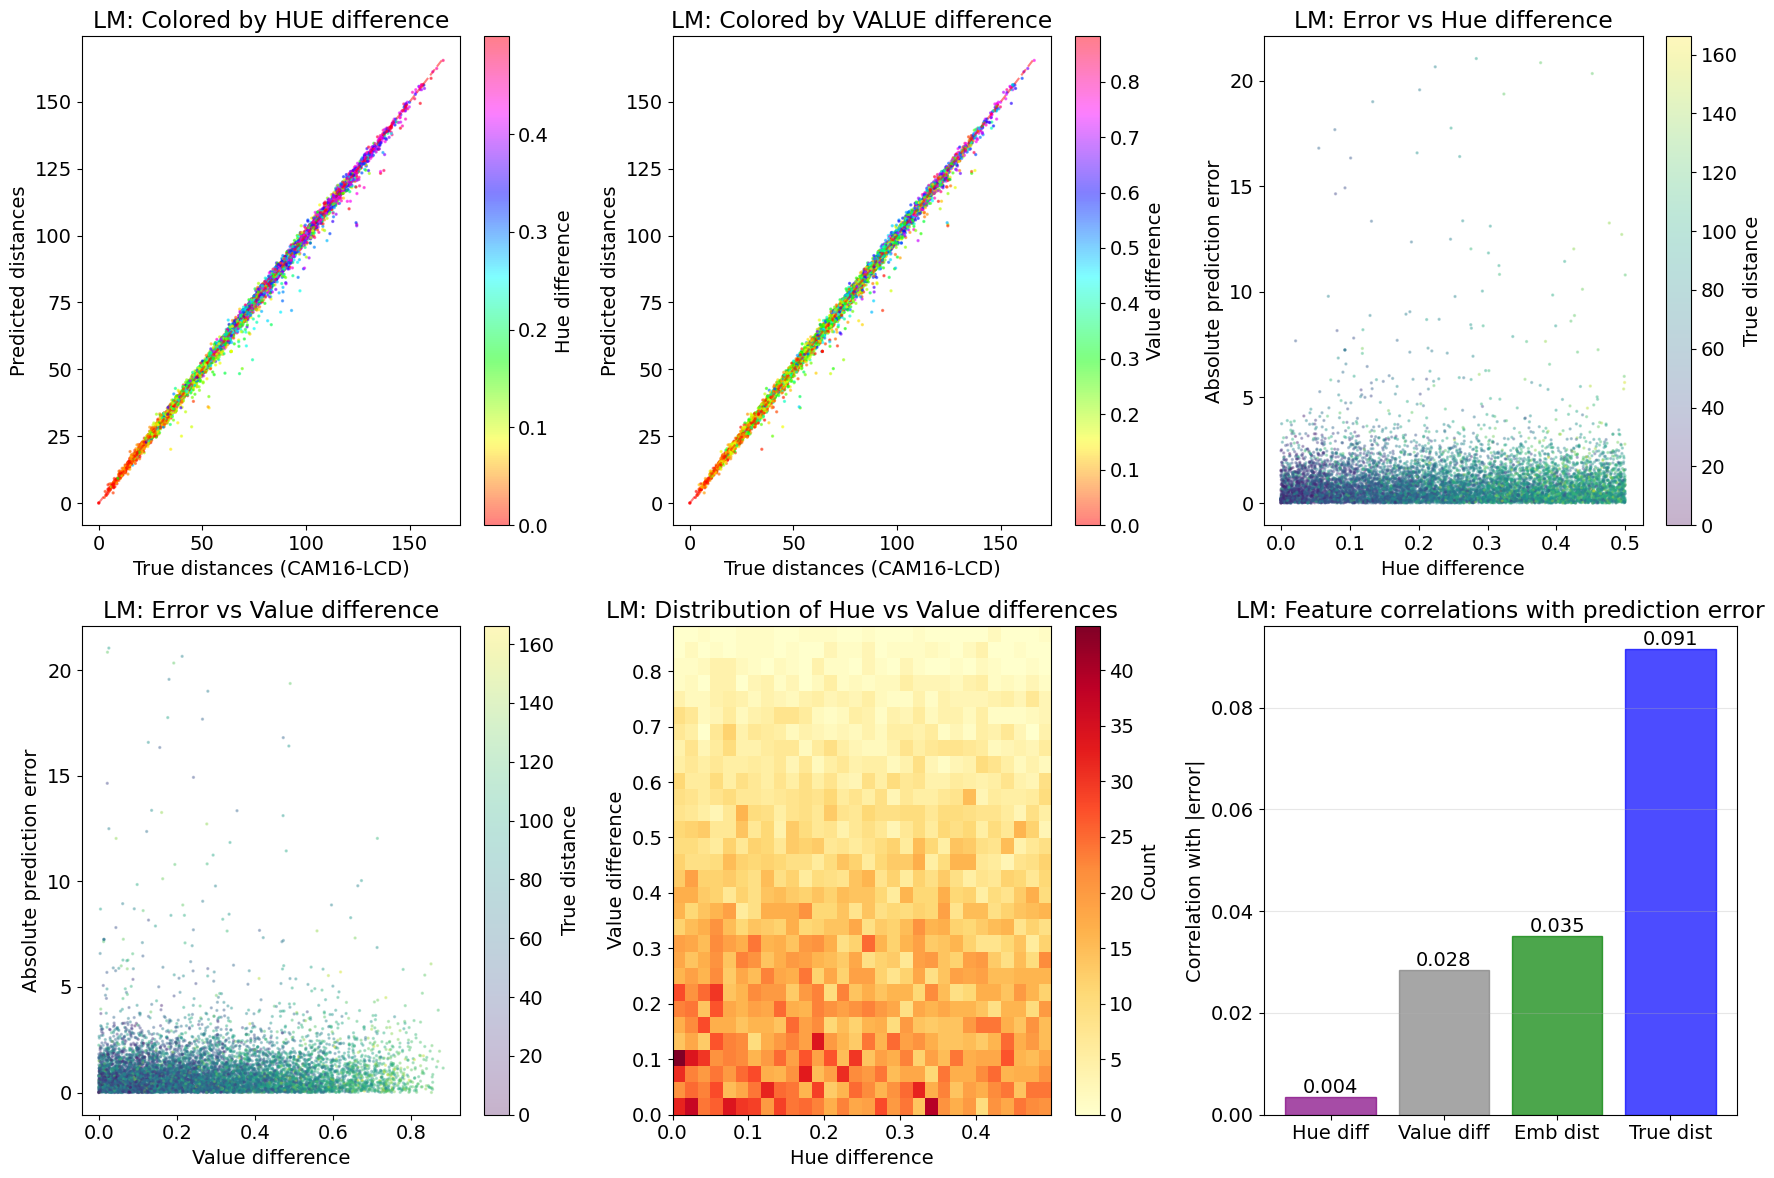

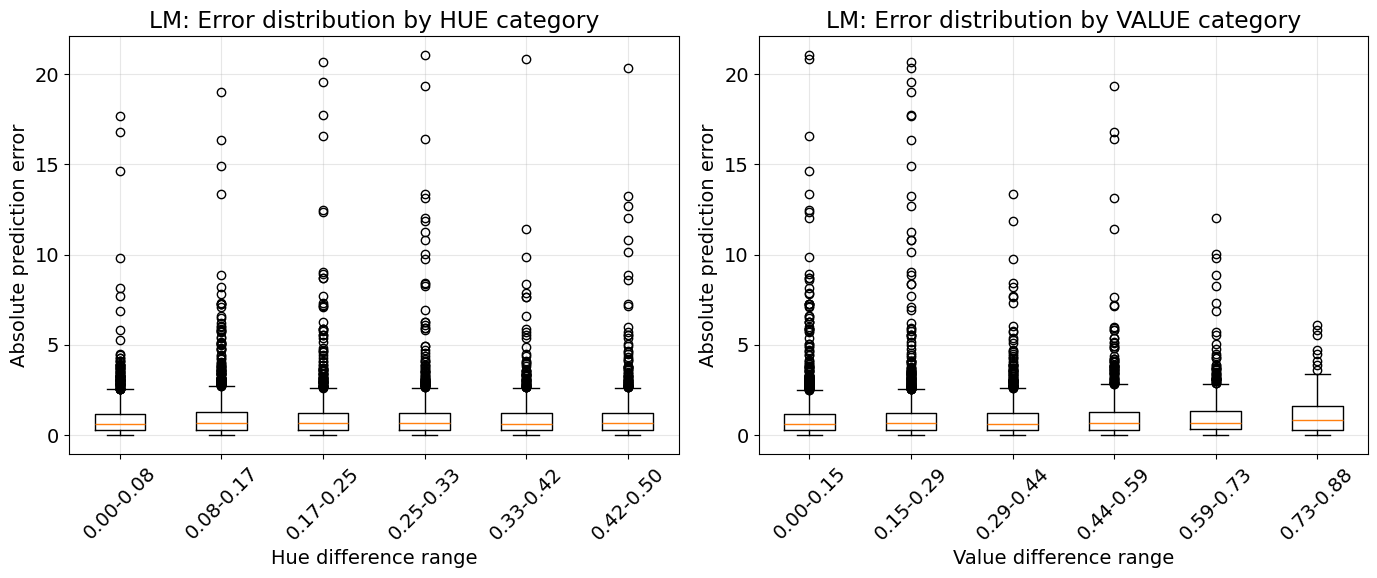


LM - HSV Analysis Summary:
  Hue difference range: [0.000, 0.500]
  Value difference range: [0.000, 0.882]
  Correlation(hue_diff, |error|): 0.004
  Correlation(value_diff, |error|): 0.028

LM layer transformation analysis:
  Matrix W shape: (3, 3584), Bias b shape: (3,)
  Effective rank: 3/3
  Condition number: 1.53
  Top 3 singular values: [ 7.15822514  5.43231175  4.66472364]

Vision layer: Converted to CAM16-UCS shape: (1755, 3)
  Ridge: CV R² = 0.9969 ± 0.0005
  Lasso: CV R² = 0.9777 ± 0.0027
  ElasticNet: CV R² = 0.9746 ± 0.0034
  Best model: Ridge

Vision layer performance:
  Overall R² = 0.9975, RMSE = 1.5535, MAE = 1.0842
  R² per dimension: L=0.997, a=0.997, b=0.998

Vision layer distance correlations:
  Pearson(dist_true, dist_pred)  = 0.9968 (p = 0.00e+00)
  Spearman(dist_true, dist_pred) = 0.9971 (p = 0.00e+00)
  Pearson(dist_emb, dist_true)   = 0.5865 (p = 0.00e+00)
  Spearman(dist_emb, dist_true)  = 0.6294 (p = 0.00e+00)
  k-NN preservation (k=5): 0.722
  k-NN preservat

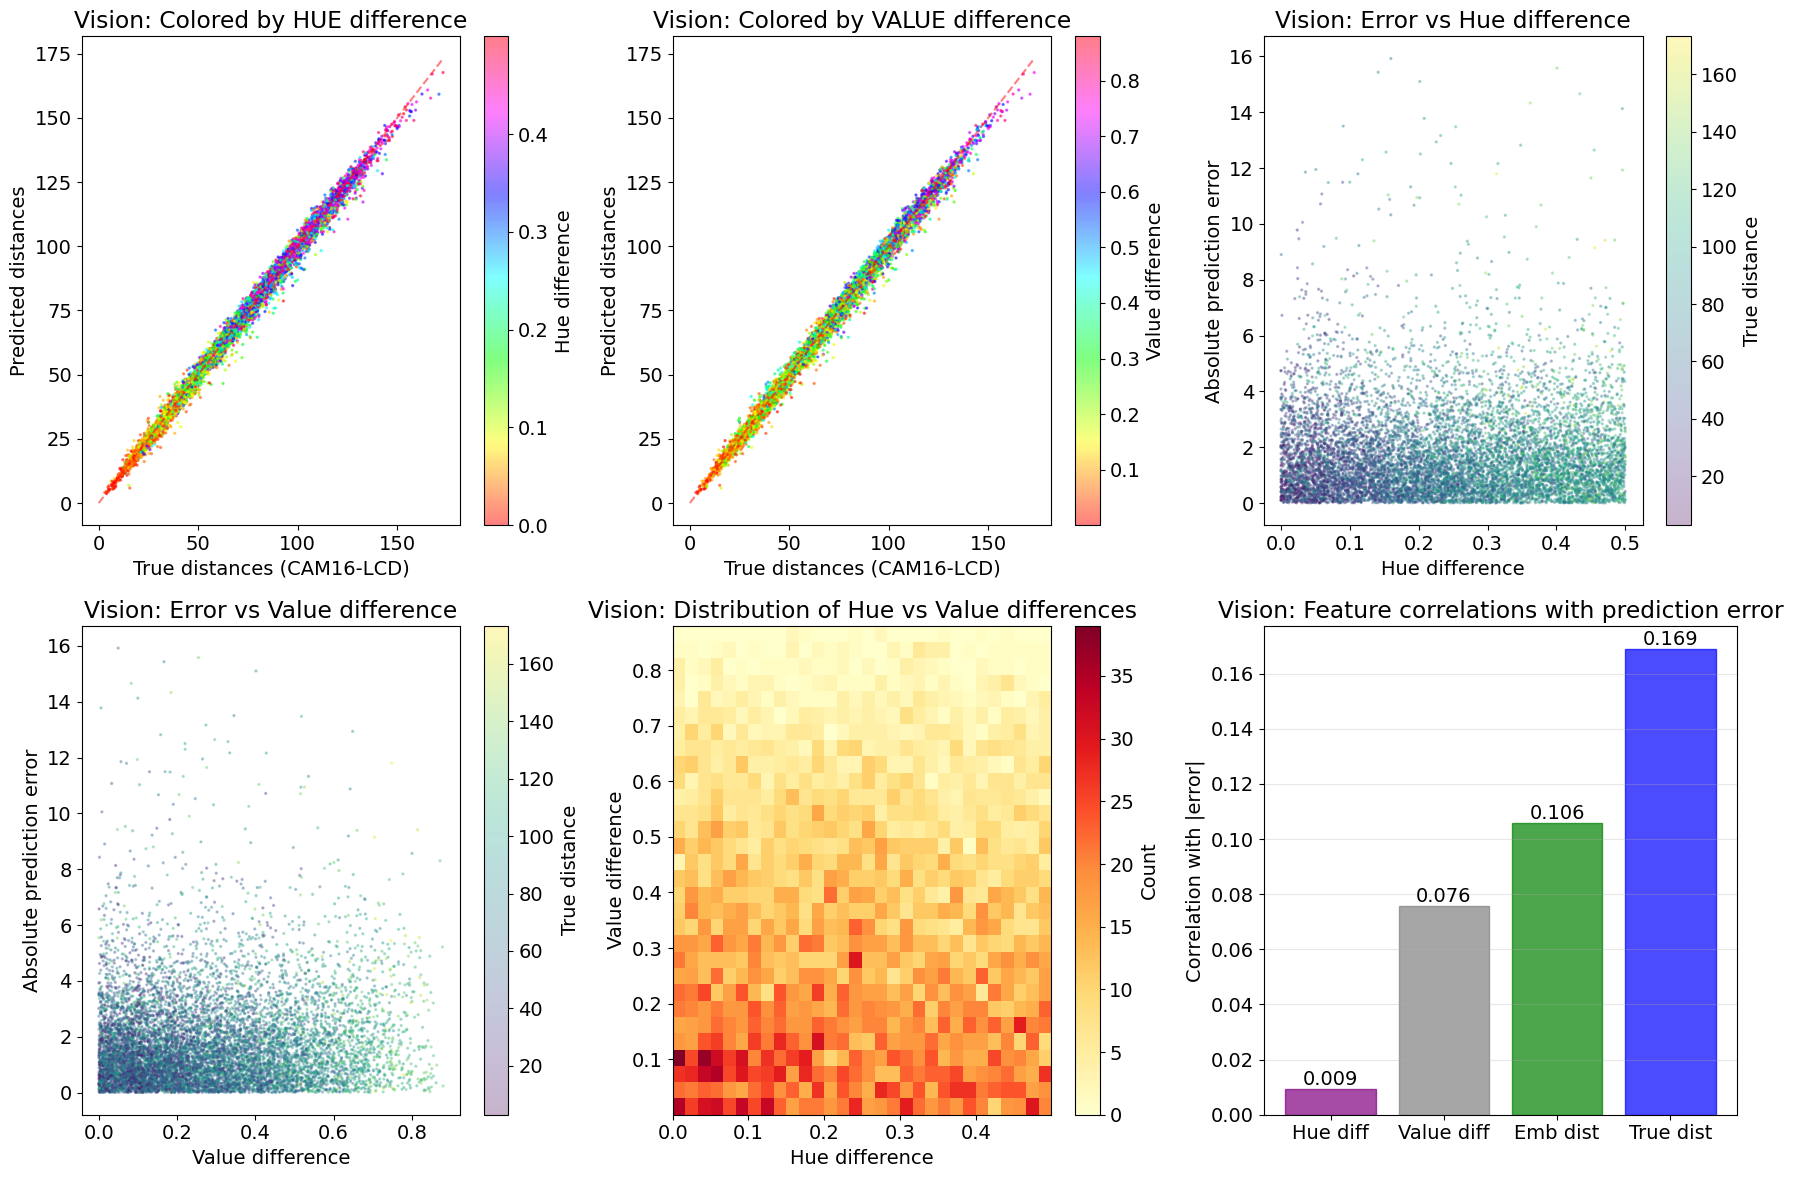

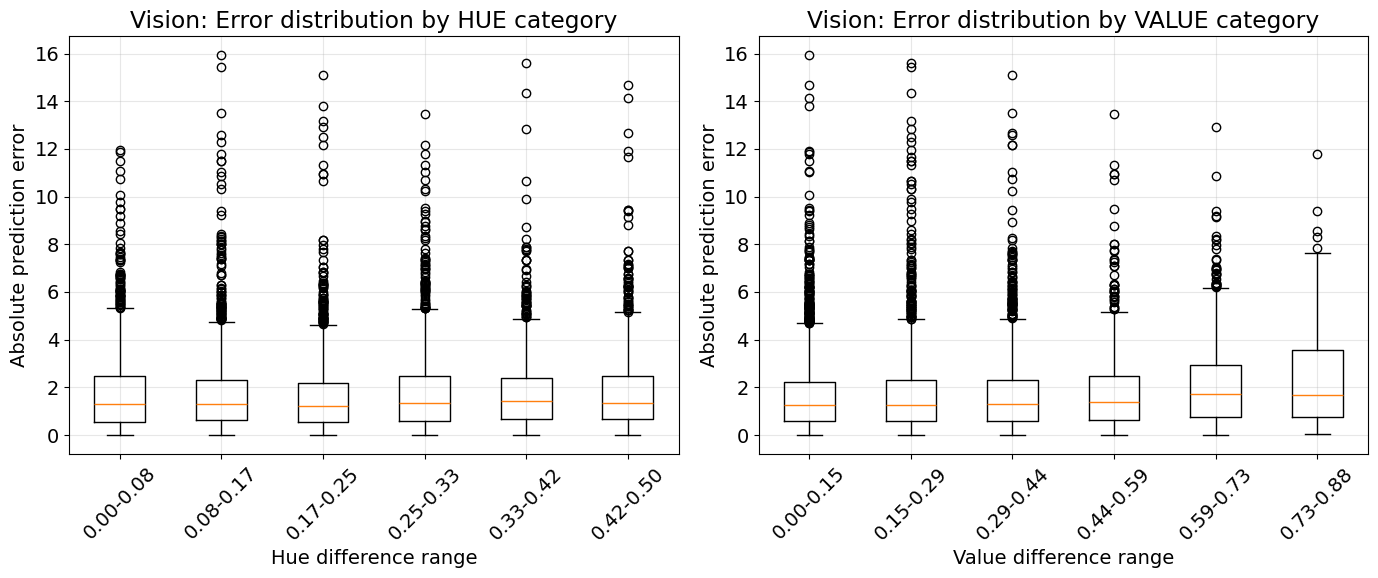


Vision - HSV Analysis Summary:
  Hue difference range: [0.000, 0.500]
  Value difference range: [0.000, 0.880]
  Correlation(hue_diff, |error|): 0.009
  Correlation(value_diff, |error|): 0.076

Vision layer transformation analysis:
  Matrix W shape: (3, 3584), Bias b shape: (3,)
  Effective rank: 3/3
  Condition number: 1.51
  Top 3 singular values: [ 37.36999944  28.79273994  24.70699898]

Cross-layer comparison:
  Correlation between LM and Vision predictions:
    Pearson = 0.9999
    Spearman = 0.9997
  Distance preservation between layers: 0.9975


In [ ]:
# Запуск анализа
print("Starting color space calibration analysis with HSV focus...")

# LM layer с цветовой информацией
results_lm = linear_color_mapping(lm, colors_xyY=colors_xyY, 
                                 color_meta_all=meta,
                                 layer_name="LM", alpha=1.0)

# Vision layer с цветовой информацией
results_vl = linear_color_mapping(vl, colors_xyY=colors_xyY,
                                 color_meta_all=meta, 
                                 layer_name="Vision", alpha=1.0)

# Сравнение между слоями
print(f"\n{'='*60}")
print("Cross-layer comparison:")

pred_corr_pearson = pearsonr(results_lm['predictions'].flatten(), 
                             results_vl['predictions'].flatten())[0]
pred_corr_spearman = spearmanr(results_lm['predictions'].flatten(), 
                               results_vl['predictions'].flatten())[0]

print(f"  Correlation between LM and Vision predictions:")
print(f"    Pearson = {pred_corr_pearson:.4f}")
print(f"    Spearman = {pred_corr_spearman:.4f}")

v_pred_lm = pdist(results_lm['predictions'], metric='euclidean')
v_pred_vl = pdist(results_vl['predictions'], metric='euclidean')
dist_corr = pearsonr(v_pred_lm, v_pred_vl)[0]
print(f"  Distance preservation between layers: {dist_corr:.4f}")

## Feature importance для координат с помощью лин рега (эмб -> cam)


=== LM -> CAM ===


,target_dim,train_r2,test_r2,train_rmse_z,test_rmse_z
0,0,0.999943,0.999534,0.007540,0.021657
1,1,0.999939,0.999404,0.007821,0.022432
2,2,0.999944,0.999539,0.007482,0.022536



=== Vision -> CAM ===


,target_dim,train_r2,test_r2,train_rmse_z,test_rmse_z
0,0,0.999940,0.998873,0.007716,0.033669
1,1,0.999940,0.998991,0.007773,0.029182
2,2,0.999946,0.999255,0.007319,0.028641


,model,feature_idx,coef_cam_0,coef_cam_1,coef_cam_2,abs_mean,abs_max,l2_norm
3337,LM,3337,-0.035580,0.037332,-0.026348,0.033087,0.037332,0.057912
654,LM,654,-0.025542,0.038787,-0.031883,0.032070,0.038787,0.056332
3240,LM,3240,-0.026774,0.041636,-0.011407,0.026606,0.041636,0.050799
1535,LM,1535,0.028308,-0.021035,0.027433,0.025592,0.028308,0.044681
1123,LM,1123,0.018869,-0.030989,0.025268,0.025042,0.030989,0.044213
300,LM,300,-0.013210,0.025730,-0.034288,0.024410,0.034288,0.044858
2035,LM,2035,-0.024897,0.014597,-0.031960,0.023818,0.031960,0.043063
1105,LM,1105,0.042204,0.003236,0.024031,0.023157,0.042204,0.048674
2239,LM,2239,0.027061,-0.012014,-0.029988,0.023021,0.029988,0.042142
1159,LM,1159,-0.012521,0.025675,-0.030250,0.022815,0.030250,0.041606


,model,feature_idx,coef_cam_0,coef_cam_1,coef_cam_2,abs_mean,abs_max,l2_norm
2173,Vision,2173,-0.017664,0.034077,-0.043546,0.031762,0.043546,0.058047
2799,Vision,2799,0.030143,-0.024006,0.031883,0.028677,0.031883,0.050014
560,Vision,560,-0.048033,0.021052,-0.009460,0.026181,0.048033,0.053290
65,Vision,65,-0.017482,0.031069,-0.028765,0.025772,0.031069,0.045808
329,Vision,329,-0.034453,0.024133,-0.016115,0.024900,0.034453,0.045045
3547,Vision,3547,0.032961,-0.014771,0.026144,0.024625,0.032961,0.044588
1023,Vision,1023,0.025495,-0.016913,0.029716,0.024041,0.029716,0.042651
1503,Vision,1503,-0.032187,0.019747,-0.019978,0.023971,0.032187,0.042721
3224,Vision,3224,-0.020417,-0.031808,0.018479,0.023568,0.031808,0.042073
1315,Vision,1315,0.014692,-0.031563,0.022706,0.022987,0.031563,0.041565


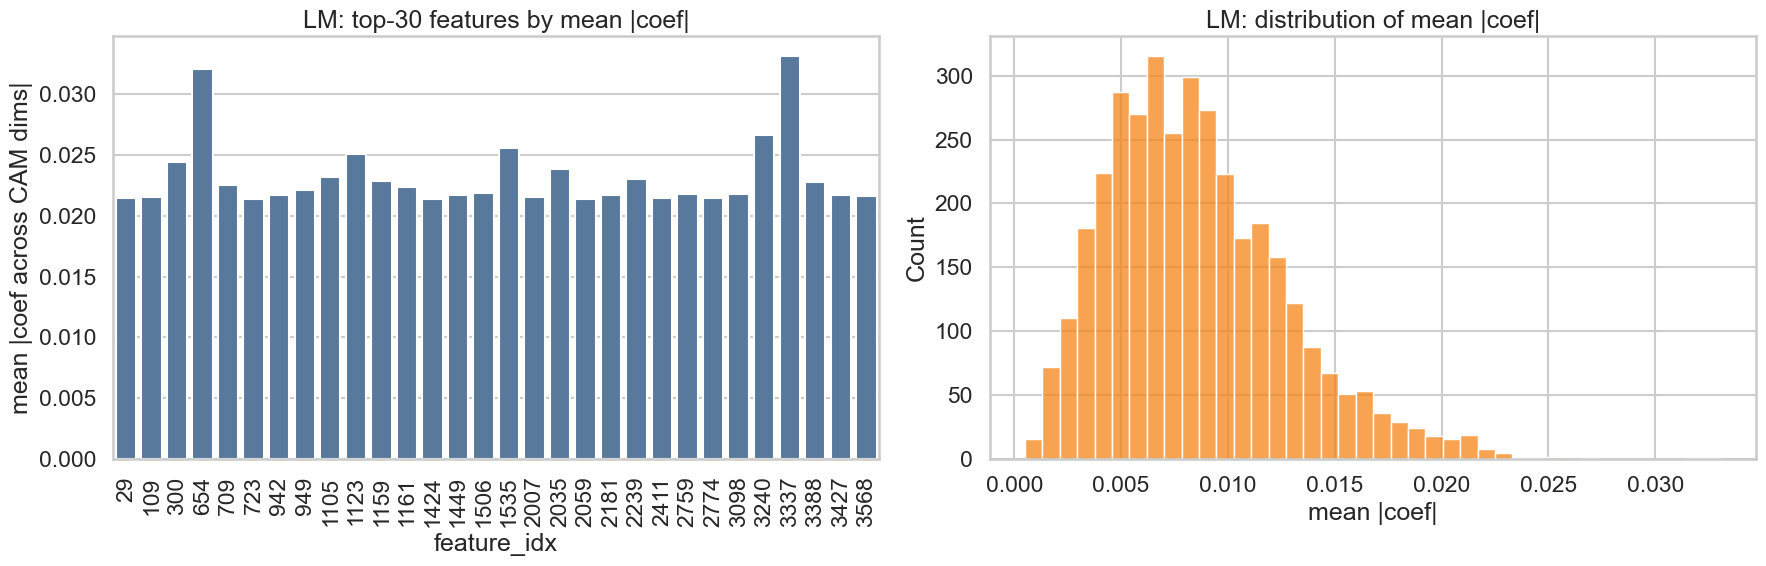

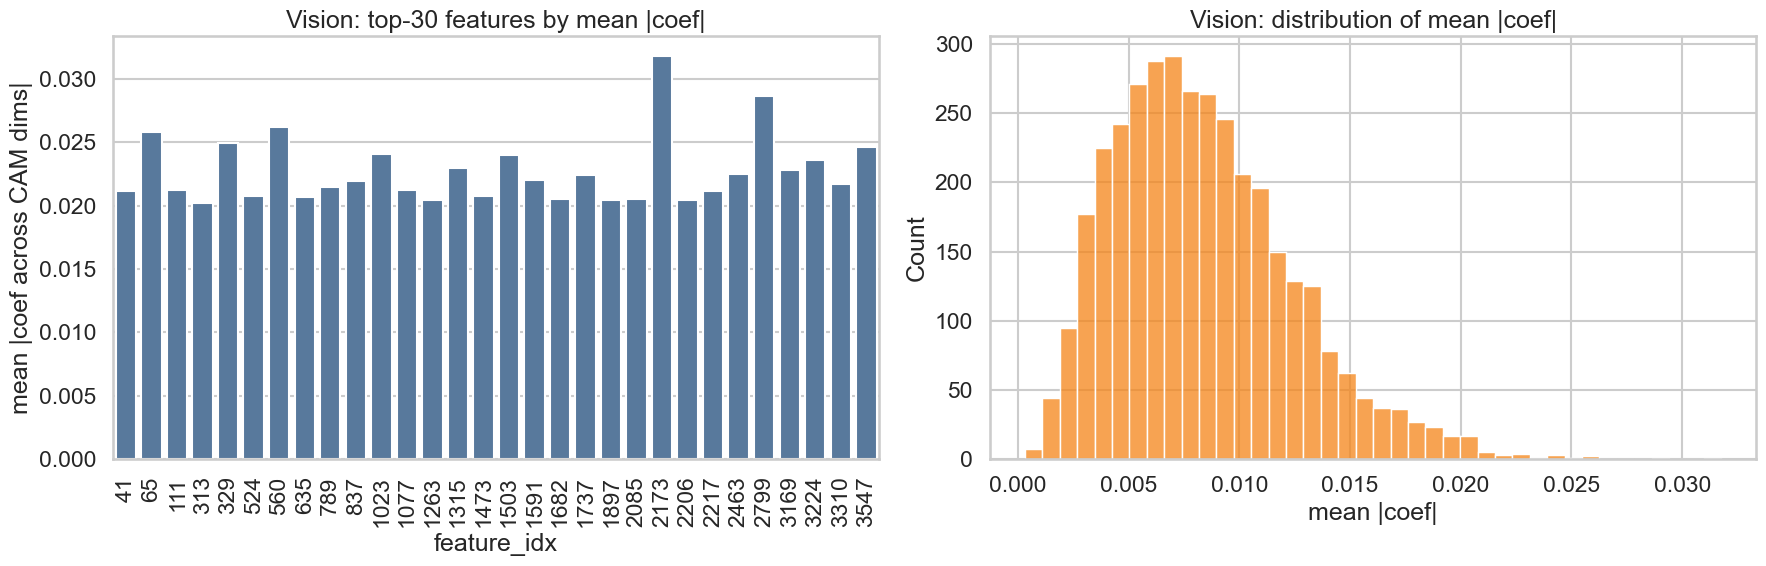

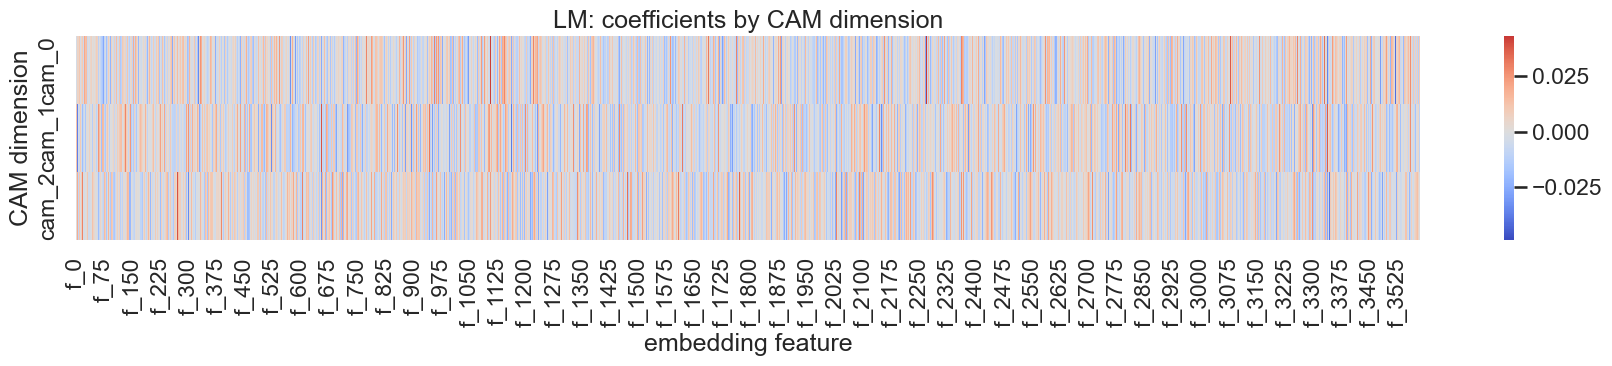

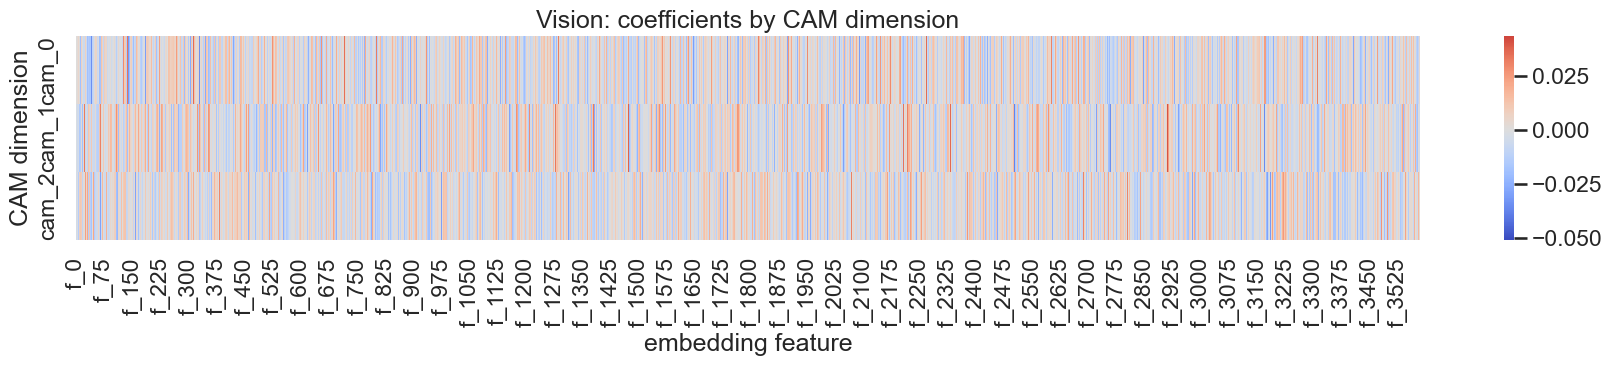

,feature_idx,abs_mean_lm,abs_mean_vl
3337,3337,0.033087,0.002857
654,654,0.032070,0.012937
3240,3240,0.026606,0.006625
1535,1535,0.025592,0.008109
1123,1123,0.025042,0.006770
300,300,0.024410,0.016694
2035,2035,0.023818,0.016645
1105,1105,0.023157,0.007957
2239,2239,0.023021,0.003466
1159,1159,0.022815,0.009906


,feature_idx,abs_mean_lm,abs_mean_vl
2173,2173,0.012493,0.031762
2799,2799,0.009053,0.028677
560,560,0.002941,0.026181
65,65,0.006090,0.025772
329,329,0.010514,0.024900
3547,3547,0.006862,0.024625
1023,1023,0.008304,0.024041
1503,1503,0.002217,0.023971
3224,3224,0.002890,0.023568
1315,1315,0.011016,0.022987


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

sns.set(style="whitegrid", context="talk")

SEED = 42


def fit_linear_cam_model(X, Y, model_name="LM", test_size=0.2, random_state=42):
    X = np.asarray(X, dtype=np.float32)
    Y = np.asarray(Y, dtype=np.float32)

    x_mask = np.isfinite(X).all(axis=1)
    y_mask = np.isfinite(Y).all(axis=1)
    mask = x_mask & y_mask

    X = X[mask]
    Y = Y[mask]

    X_train, X_test, Y_train, Y_test = train_test_split(
        X, Y, test_size=test_size, random_state=random_state
    )

    pipe = Pipeline([
        ("x_scaler", StandardScaler()),
        ("lr", LinearRegression())
    ])

    y_scaler = StandardScaler()
    Y_train_z = y_scaler.fit_transform(Y_train)
    Y_test_z = y_scaler.transform(Y_test)

    pipe.fit(X_train, Y_train_z)

    Y_pred_train_z = pipe.predict(X_train)
    Y_pred_test_z = pipe.predict(X_test)

    train_r2 = r2_score(Y_train_z, Y_pred_train_z, multioutput="raw_values")
    test_r2 = r2_score(Y_test_z, Y_pred_test_z, multioutput="raw_values")

    train_rmse = np.sqrt(np.mean((Y_pred_train_z - Y_train_z) ** 2, axis=0))
    test_rmse = np.sqrt(np.mean((Y_pred_test_z - Y_test_z) ** 2, axis=0))

    lr = pipe.named_steps["lr"]
    coef = lr.coef_   # shape: (n_targets, n_features)
    intercept = lr.intercept_

    metrics_df = pd.DataFrame({
        "target_dim": np.arange(Y.shape[1]),
        "train_r2": train_r2,
        "test_r2": test_r2,
        "train_rmse_z": train_rmse,
        "test_rmse_z": test_rmse,
    })

    print(f"\n=== {model_name} -> CAM ===")
    display(metrics_df)

    return {
        "model_name": model_name,
        "pipe": pipe,
        "y_scaler": y_scaler,
        "coef": coef,
        "intercept": intercept,
        "metrics": metrics_df,
        "X_train": X_train,
        "X_test": X_test,
        "Y_train": Y_train,
        "Y_test": Y_test,
    }


def build_feature_importance_df(coef, model_name="LM"):
    """
    coef shape = (n_cam_dims, n_features)
    """
    coef = np.asarray(coef)

    rows = []
    for feat_idx in range(coef.shape[1]):
        vals = coef[:, feat_idx]
        rows.append({
            "model": model_name,
            "feature_idx": feat_idx,
            "coef_cam_0": vals[0],
            "coef_cam_1": vals[1] if coef.shape[0] > 1 else np.nan,
            "coef_cam_2": vals[2] if coef.shape[0] > 2 else np.nan,
            "abs_mean": np.mean(np.abs(vals)),
            "abs_max": np.max(np.abs(vals)),
            "l2_norm": np.sqrt(np.sum(vals ** 2)),
        })
    return pd.DataFrame(rows).sort_values("abs_mean", ascending=False)


def plot_feature_importance(imp_df, model_name="LM", top_k=30):
    top = imp_df.head(top_k).copy()

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    sns.barplot(
        data=top,
        x="feature_idx",
        y="abs_mean",
        ax=axes[0],
        color="#4C78A8"
    )
    axes[0].set_title(f"{model_name}: top-{top_k} features by mean |coef|")
    axes[0].set_xlabel("feature_idx")
    axes[0].set_ylabel("mean |coef across CAM dims|")
    axes[0].tick_params(axis="x", rotation=90)

    sns.histplot(
        imp_df["abs_mean"],
        bins=40,
        ax=axes[1],
        color="#F58518"
    )
    axes[1].set_title(f"{model_name}: distribution of mean |coef|")
    axes[1].set_xlabel("mean |coef|")

    plt.tight_layout()
    plt.show()


def plot_coef_heatmap(coef, model_name="LM"):
    coef_df = pd.DataFrame(
        coef,
        index=[f"cam_{i}" for i in range(coef.shape[0])],
        columns=[f"f_{i}" for i in range(coef.shape[1])]
    )

    plt.figure(figsize=(18, 4))
    sns.heatmap(coef_df, center=0, cmap="coolwarm")
    plt.title(f"{model_name}: coefficients by CAM dimension")
    plt.xlabel("embedding feature")
    plt.ylabel("CAM dimension")
    plt.tight_layout()
    plt.show()


def compare_importance_profiles(imp_lm, imp_vl, top_k=30):
    merged = imp_lm[["feature_idx", "abs_mean"]].merge(
        imp_vl[["feature_idx", "abs_mean"]],
        on="feature_idx",
        how="outer",
        suffixes=("_lm", "_vl")
    ).fillna(0)

    display(merged.sort_values("abs_mean_lm", ascending=False).head(top_k))
    display(merged.sort_values("abs_mean_vl", ascending=False).head(top_k))


# ------------------------------------------------------------
# 3. Запуск
# ------------------------------------------------------------


X_lm = np.asarray(lm, dtype=np.float32)
X_vl = np.asarray(vl, dtype=np.float32)
Y_cam = np.asarray(cam, dtype=np.float32)

lm_cam_res = fit_linear_cam_model(X_lm, Y_cam, model_name="LM", random_state=SEED)
vl_cam_res = fit_linear_cam_model(X_vl, Y_cam, model_name="Vision", random_state=SEED)

imp_lm = build_feature_importance_df(lm_cam_res["coef"], model_name="LM")
imp_vl = build_feature_importance_df(vl_cam_res["coef"], model_name="Vision")

display(imp_lm.head(20))
display(imp_vl.head(20))

plot_feature_importance(imp_lm, model_name="LM", top_k=30)
plot_feature_importance(imp_vl, model_name="Vision", top_k=30)

plot_coef_heatmap(lm_cam_res["coef"], model_name="LM")
plot_coef_heatmap(vl_cam_res["coef"], model_name="Vision")

compare_importance_profiles(imp_lm, imp_vl, top_k=30)


# ОСНОВНОЕ: построение метрики на Манселе с расстояниями в пространстве CAM (использующиеся в тезисах)


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt
import math
from vsl_ial.stress import stress as stress_fn


# ============================================================
# 0) Utils
# ============================================================

def sanitize_X(X):
    X = np.asarray(X, dtype=np.float32)
    m = np.isfinite(X).all(axis=1)
    if m.sum() < len(m):
        print(f"sanitize_X: dropped {len(m)-m.sum()}/{len(m)} rows with NaN/Inf")
    return X[m], m


def safe_corr(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)

    if len(y_true) < 2:
        return np.nan, np.nan
    if np.allclose(y_true, y_true[0]) or np.allclose(y_pred, y_pred[0]):
        return np.nan, np.nan

    pr = float(pearsonr(y_true, y_pred)[0])
    sr = spearmanr(y_true, y_pred)
    sr_r = float(getattr(sr, "correlation", sr.statistic))
    return pr, sr_r


def safe_stress(d_true, d_pred, ord=2):
    d_true = np.asarray(d_true, dtype=np.float64)
    d_pred = np.asarray(d_pred, dtype=np.float64)
    m = np.isfinite(d_true) & np.isfinite(d_pred)
    if m.sum() < 2:
        return np.nan
    return float(stress_fn(d_pred[m], d_true[m], ord=ord))


def make_log_m_grid(max_dim, min_dim=3, n_points=6, include_max=True):
    """
    Логарифмически равномерная сетка по m.
    """
    max_dim = int(max_dim)
    min_dim = int(min_dim)

    if max_dim < 1:
        raise ValueError(f"max_dim must be >= 1, got {max_dim}")

    min_dim = max(1, min_dim)

    if min_dim >= max_dim:
        return [max_dim]

    raw = np.geomspace(min_dim, max_dim, num=n_points)
    grid = np.unique(np.clip(np.round(raw).astype(int), min_dim, max_dim))

    if include_max and grid[-1] != max_dim:
        grid = np.append(grid, max_dim)

    return sorted(set(grid.tolist()))


def prepare_pairs_df(pairs_df, n_objects, dataset_name=None):
    """
    Ожидает колонки:
      - i, j: индексы объектов
      - dv: целевое расстояние (НЕ квадрат)
      - (опционально) dataset
    """
    p = pairs_df.copy()

    if dataset_name is not None:
        if "dataset" not in p.columns:
            raise ValueError("pairs_df has no 'dataset' column, but dataset_name was provided.")
        p = p[p["dataset"] == dataset_name].copy()

    required = {"i", "j", "dv"}
    missing = required - set(p.columns)
    if missing:
        raise ValueError(f"pairs_df missing required columns: {missing}")

    p = p[np.isfinite(p["i"]) & np.isfinite(p["j"]) & np.isfinite(p["dv"])].copy()
    p["i"] = p["i"].astype(np.int64)
    p["j"] = p["j"].astype(np.int64)
    p["dv"] = p["dv"].astype(np.float32)

    p = p[(p["i"] >= 0) & (p["j"] >= 0) & (p["i"] < n_objects) & (p["j"] < n_objects)]
    p = p[p["i"] != p["j"]]
    p = p[p["dv"] >= 0.0]

    # canonical order i<j
    i = p["i"].to_numpy()
    j = p["j"].to_numpy()
    i2 = np.minimum(i, j)
    j2 = np.maximum(i, j)
    p = p.copy()
    p["i"] = i2
    p["j"] = j2

    # убрать дубликаты пар (если есть), усреднить dv
    p = p.groupby(["i", "j"], as_index=False)["dv"].mean()

    if len(p) == 0:
        raise ValueError("No valid pairs left after filtering.")

    return p


def make_pair_batch_from_pairs(X, i, j, d_true):
    V = X[i] - X[j]
    t2 = d_true * d_true
    m = np.isfinite(V).all(axis=1) & np.isfinite(t2)
    if not np.all(m):
        V = V[m]
        t2 = t2[m]
    return V, t2


def compute_pred_true_for_pairs(X, A, i, j, d_true):
    dX = X[i] - X[j]
    AdX = dX @ A.T
    pred2 = np.sum(AdX * AdX, axis=1)
    pred = np.sqrt(np.maximum(pred2, 0.0))

    t = np.asarray(d_true, dtype=np.float32)
    t2 = t * t

    m = np.isfinite(t) & np.isfinite(pred) & np.isfinite(t2) & np.isfinite(pred2)
    return t[m], pred[m], t2[m], pred2[m]


# ============================================================
# 1) L = mean ( ||A v||^2 - t2 )^2
# ============================================================

def loss_and_grad_A_squared_full(A, V, t2):
    AV = V @ A.T
    s = np.sum(AV * AV, axis=1)
    e = (s - t2)
    loss = float(np.mean(e * e))

    c = (4.0 * e).astype(np.float32)
    grad = ((c[:, None] * AV).T @ V) / max(1, V.shape[0])
    return loss, grad


# ============================================================
# 2) AdamW  + grad clipping
# ============================================================

class AdamW:
    def __init__(self, shape, lr=1e-3, beta1=0.9, beta2=0.999, eps=1e-8, weight_decay=1e-4):
        self.lr = float(lr)
        self.b1 = float(beta1)
        self.b2 = float(beta2)
        self.eps = float(eps)
        self.wd = float(weight_decay)
        self.m = np.zeros(shape, dtype=np.float32)
        self.v = np.zeros(shape, dtype=np.float32)
        self.t = 0

    def step(self, param, grad):
        self.t += 1
        if self.wd > 0:
            param = param * (1.0 - self.lr * self.wd)

        self.m = self.b1 * self.m + (1.0 - self.b1) * grad
        self.v = self.b2 * self.v + (1.0 - self.b2) * (grad * grad)

        mhat = self.m / (1.0 - self.b1 ** self.t)
        vhat = self.v / (1.0 - self.b2 ** self.t)

        param = param - self.lr * mhat / (np.sqrt(vhat) + self.eps)
        return param


# ============================================================
# 3) Metrics on DISTANCES 
# ============================================================

def dist_errors(d_true, d_pred, eps=1e-6):
    d_true = np.asarray(d_true, dtype=np.float64)
    d_pred = np.asarray(d_pred, dtype=np.float64)

    err = d_pred - d_true
    mae = float(np.mean(np.abs(err)))
    rmse = float(np.sqrt(np.mean(err * err)))

    denom = np.maximum(np.abs(d_true), eps)
    mape = float(np.mean(np.abs(err) / denom) * 100.0)
    smape = float(np.mean(2.0 * np.abs(err) / np.maximum(np.abs(d_true) + np.abs(d_pred), eps)) * 100.0)

    pr, sr = safe_corr(d_true, d_pred)
    st = safe_stress(d_true, d_pred, ord=2)

    return {
        "rmse": rmse,
        "mae": mae,
        "mape": mape,
        "smape": smape,
        "pearson": pr,
        "spearman": sr,
        "stress": st,
    }


def estimate_val_loss_sq_objective_pairs(X, A, i, j, d_true, max_eval_pairs=None, rng=None):
    if max_eval_pairs is not None and len(i) > max_eval_pairs:
        if rng is None:
            rng = np.random.default_rng(0)
        idx = rng.choice(len(i), size=max_eval_pairs, replace=False)
        i, j, d_true = i[idx], j[idx], d_true[idx]

    V, t2 = make_pair_batch_from_pairs(X, i, j, d_true)
    AV = V @ A.T
    pred2 = np.sum(AV * AV, axis=1)
    e = pred2 - t2
    return float(np.mean(e * e))


def eval_dist_metrics_pairs(X, A, i, j, d_true, max_eval_pairs=None, rng=None):
    if max_eval_pairs is not None and len(i) > max_eval_pairs:
        if rng is None:
            rng = np.random.default_rng(0)
        idx = rng.choice(len(i), size=max_eval_pairs, replace=False)
        i, j, d_true = i[idx], j[idx], d_true[idx]

    d_true_arr, d_pred_arr, _, _ = compute_pred_true_for_pairs(X, A, i, j, d_true)
    return dist_errors(d_true_arr, d_pred_arr)


# ============================================================
# 4) Init: A = alpha * I
# ============================================================

def init_alphaI_from_pairs(X, i, j, d_true, eps=1e-12):
    dx = X[i] - X[j]
    dx2 = np.sum(dx * dx, axis=1)
    dy2 = d_true * d_true

    num = float(np.dot(dy2, dx2))
    den = float(np.dot(dx2, dx2)) + eps
    alpha2 = max(num / den, 0.0)
    return float(np.sqrt(alpha2))


# ============================================================
# 5) Training loop on explicit pairs_df
# ============================================================

def fit_fullA_distance_squares_pairs(
    X,
    i_train, j_train, d_train,
    i_val, j_val, d_val,
    n_steps=1200,
    batch_size=512,
    lr=3e-4,
    weight_decay=3e-4,
    grad_clip=5.0,
    seed=42,
    log_every=50,
    val_every=200,
    patience=5,
    min_delta=0.0,
    plot_from_step=100,
    max_eval_pairs=80_000,
    m_dim=3
):
    rng = np.random.default_rng(seed)
    n_dim = X.shape[1]

    alpha = init_alphaI_from_pairs(X, i_train, j_train, d_train)
    A = np.zeros((m_dim, n_dim), dtype=np.float32)

    k = min(m_dim, n_dim)
    A[:k, :k] = alpha * np.eye(k, dtype=np.float32)

    print(f"Init A = alpha*I, alpha={alpha:.6f}, ||A||={np.linalg.norm(A):.4f}, size={A.shape}")

    opt = AdamW(A.shape, lr=lr, weight_decay=weight_decay)

    hist_train_steps, hist_train_loss = [], []
    hist_val_steps, hist_val_loss = [], []
    hist_val_rmse, hist_val_mae, hist_val_mape, hist_val_smape = [], [], [], []
    hist_val_pearson, hist_val_spearman, hist_val_stress = [], [], []

    best = {"val_loss": np.inf, "A": A.copy(), "step": 0, "val_dist": None}
    bad_count = 0

    n_train_pairs = len(i_train)
    if n_train_pairs == 0:
        raise ValueError("No training pairs.")
    if len(i_val) == 0:
        raise ValueError("No validation pairs.")

    for step in range(1, n_steps + 1):
        bsz = min(batch_size, n_train_pairs)
        idx = rng.integers(0, n_train_pairs, size=bsz, endpoint=False)

        i_b = i_train[idx]
        j_b = j_train[idx]
        d_b = d_train[idx]

        V, t2 = make_pair_batch_from_pairs(X, i_b, j_b, d_b)
        train_loss, grad = loss_and_grad_A_squared_full(A, V, t2)

        gnorm = float(np.linalg.norm(grad))
        if grad_clip is not None and gnorm > grad_clip:
            grad = grad * (grad_clip / (gnorm + 1e-12))

        if not (np.isfinite(train_loss) and np.isfinite(A).all() and np.isfinite(grad).all()):
            raise FloatingPointError(
                f"Non-finite at step={step}: train_loss={train_loss}, ||A||={np.linalg.norm(A)}"
            )

        A = opt.step(A, grad.astype(np.float32))

        if step % log_every == 0 or step == 1:
            hist_train_steps.append(step)
            hist_train_loss.append(train_loss)

        if step % val_every == 0 or step == n_steps:
            val_loss = estimate_val_loss_sq_objective_pairs(
                X, A, i_val, j_val, d_val, max_eval_pairs=max_eval_pairs, rng=rng
            )
            val_dist = eval_dist_metrics_pairs(
                X, A, i_val, j_val, d_val, max_eval_pairs=max_eval_pairs, rng=rng
            )

            hist_val_steps.append(step)
            hist_val_loss.append(val_loss)
            hist_val_rmse.append(val_dist["rmse"])
            hist_val_mae.append(val_dist["mae"])
            hist_val_mape.append(val_dist["mape"])
            hist_val_smape.append(val_dist["smape"])
            hist_val_pearson.append(val_dist["pearson"])
            hist_val_spearman.append(val_dist["spearman"])
            hist_val_stress.append(val_dist["stress"])

            print(f"step={step}/{n_steps} train_loss(batch)={train_loss:.6f} ||grad||={gnorm:.3f} ||A||={np.linalg.norm(A):.3f}")
            print(f"  [val objective] loss={val_loss:.6f}")
            print(
                f"  [val dist] RMSE={val_dist['rmse']:.3f} "
                f"MAE={val_dist['mae']:.3f} "
                f"MAPE={val_dist['mape']:.2f}% "
                f"sMAPE={val_dist['smape']:.2f}% "
                f"Pearson={val_dist['pearson']:.4f} "
                f"Spearman={val_dist['spearman']:.4f} "
                f"Stress={val_dist['stress']:.6f}"
            )

            if val_loss < best["val_loss"] - min_delta:
                best = {"val_loss": val_loss, "A": A.copy(), "step": step, "val_dist": val_dist}
                bad_count = 0
            else:
                bad_count += 1
                if bad_count >= patience:
                    print(
                        f"Early stopping at step={step}: no improvement in VAL LOSS for {patience} validations. "
                        f"Best step={best['step']} val_loss={best['val_loss']:.6f}"
                    )
                    break

    tr_s = np.array(hist_train_steps, dtype=int)
    tr_l = np.array(hist_train_loss, dtype=float)
    va_s = np.array(hist_val_steps, dtype=int)
    va_l = np.array(hist_val_loss, dtype=float)

    m_tr = tr_s >= plot_from_step
    m_va = va_s >= plot_from_step

    plt.figure(figsize=(7, 4))
    if m_tr.any():
        plt.plot(tr_s[m_tr], tr_l[m_tr], label="train objective loss (batch)")
    if m_va.any():
        plt.plot(va_s[m_va], va_l[m_va], marker="o", label="val objective loss")
    plt.xlabel("step")
    plt.ylabel("loss")
    plt.title(f"Objective loss on train vs val (from step {plot_from_step})")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    if len(hist_val_steps) > 0 and m_va.any():
        plt.figure(figsize=(7, 4))
        plt.plot(va_s[m_va], np.array(hist_val_rmse)[m_va], marker="o", label="RMSE (dist)")
        plt.plot(va_s[m_va], np.array(hist_val_mae)[m_va], marker="o", label="MAE (dist)")
        plt.xlabel("step")
        plt.ylabel("error")
        plt.title(f"Val errors on distances (from step {plot_from_step})")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.show()

        plt.figure(figsize=(7, 4))
        plt.plot(va_s[m_va], np.array(hist_val_stress)[m_va], marker="o", label="Stress")
        plt.xlabel("step")
        plt.ylabel("stress")
        plt.title(f"Val stress on distances (from step {plot_from_step})")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.show()

    if len(hist_val_steps) > 0 and m_va.any():
        plt.figure(figsize=(7, 4))
        plt.plot(va_s[m_va], np.array(hist_val_mape)[m_va], marker="o", label="MAPE% (dist)")
        plt.plot(va_s[m_va], np.array(hist_val_smape)[m_va], marker="o", label="sMAPE% (dist)")
        plt.xlabel("step")
        plt.ylabel("percent")
        plt.title(f"Val percentage errors on distances (from step {plot_from_step})")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.show()

    print(f"Best by VAL LOSS: step={best['step']} val_loss={best['val_loss']:.6f}")
    if best["val_dist"] is not None:
        d = best["val_dist"]
        print(
            f"  [best val dist] RMSE={d['rmse']:.3f} "
            f"MAE={d['mae']:.3f} "
            f"MAPE={d['mape']:.2f}% "
            f"sMAPE={d['smape']:.2f}% "
            f"Pearson={d['pearson']:.4f} "
            f"Spearman={d['spearman']:.4f} "
            f"Stress={d['stress']:.6f}"
        )

    history = {
        "train_steps": tr_s,
        "train_loss": tr_l,
        "val_steps": va_s,
        "val_loss": va_l,
        "val_dist_rmse": np.array(hist_val_rmse, dtype=float),
        "val_dist_mae": np.array(hist_val_mae, dtype=float),
        "val_dist_mape": np.array(hist_val_mape, dtype=float),
        "val_dist_smape": np.array(hist_val_smape, dtype=float),
        "val_dist_pearson": np.array(hist_val_pearson, dtype=float),
        "val_dist_spearman": np.array(hist_val_spearman, dtype=float),
        "val_dist_stress": np.array(hist_val_stress, dtype=float),
    }
    return best, history


# ============================================================
# 6) End-to-end runner for pairs_df
# ============================================================

def run_fullA_experiment_pairs(
    embeddings,
    pairs_df,
    dataset_name='leeds',
    layer_name="LM",
    test_size=0.2,
    random_state=42,
    n_steps=1500,
    batch_size=512,
    lr=3e-4,
    weight_decay=3e-4,
    grad_clip=5.0,
    val_every=50,
    patience=5,
    min_delta=0.0,
    plot_from_step=100,
    max_eval_pairs=80_000,
    m_dim=3
):
    X, mask_valid = sanitize_X(embeddings)

    if not np.all(mask_valid):
        raise ValueError(
            "embeddings contain NaN/Inf. Fix embeddings first, otherwise pair indices no longer match object rows."
        )

    p = prepare_pairs_df(pairs_df, n_objects=X.shape[0], dataset_name=dataset_name)

    i_all = p["i"].to_numpy(dtype=np.int64)
    j_all = p["j"].to_numpy(dtype=np.int64)
    d_all = p["dv"].to_numpy(dtype=np.float32)

    idx = np.arange(len(p))
    idx_tr, idx_te = train_test_split(idx, test_size=test_size, random_state=random_state, shuffle=True)

    i_tr, j_tr, d_tr = i_all[idx_tr], j_all[idx_tr], d_all[idx_tr]
    i_te, j_te, d_te = i_all[idx_te], j_all[idx_te], d_all[idx_te]

    print(f"[{layer_name}] X={X.shape}, pairs_train={len(i_tr)}, pairs_val={len(i_te)}, dim={X.shape[1]}, m={m_dim}")

    best, history = fit_fullA_distance_squares_pairs(
        X,
        i_tr, j_tr, d_tr,
        i_te, j_te, d_te,
        n_steps=n_steps,
        batch_size=batch_size,
        lr=lr,
        weight_decay=weight_decay,
        grad_clip=grad_clip,
        seed=42,
        log_every=50,
        val_every=val_every,
        patience=patience,
        min_delta=min_delta,
        plot_from_step=plot_from_step,
        max_eval_pairs=max_eval_pairs,
        m_dim=m_dim
    )

    A_best = best["A"]

    final_loss = estimate_val_loss_sq_objective_pairs(
        X, A_best, i_te, j_te, d_te, max_eval_pairs=200_000, rng=np.random.default_rng(999)
    )
    final_dist = eval_dist_metrics_pairs(
        X, A_best, i_te, j_te, d_te, max_eval_pairs=200_000, rng=np.random.default_rng(1002)
    )

    print(f"[{layer_name}] FINAL val objective loss={final_loss:.6f}")
    print(
        f"[{layer_name}] FINAL val distances: "
        f"RMSE={final_dist['rmse']:.3f} "
        f"MAE={final_dist['mae']:.3f} "
        f"MAPE={final_dist['mape']:.2f}% "
        f"sMAPE={final_dist['smape']:.2f}% "
        f"Pearson={final_dist['pearson']:.4f} "
        f"Spearman={final_dist['spearman']:.4f} "
        f"Stress={final_dist['stress']:.6f}"
    )

    return {
        "A": A_best,
        "best": best,
        "history": history,
        "final": {"loss": final_loss, "dist": final_dist},
        "pairs_used": p,
    }


# ============================================================
# 7) Plot quality vs m
# ============================================================

def plot_quality_vs_m(res):
    m_vals = sorted([k for k in res.keys() if isinstance(k, (int, np.integer, float))])
    if len(m_vals) == 0:
        raise ValueError("В res нет ключей m (чисел). Ожидается формат res[m] = {'lm':..., 'vision':...}")

    metrics = ["rmse", "pearson", "stress"]
    # metrics = ["rmse", "mae", "mape", "smape", "pearson", "spearman", "stress"]

    lm_data = {met: [] for met in metrics}
    vl_data = {met: [] for met in metrics}

    for m in m_vals:
        lm_final = res[m]["lm"]["final"]["dist"]
        vl_final = res[m]["vision"]["final"]["dist"]

        for met in metrics:
            lm_data[met].append(lm_final.get(met, np.nan))
            vl_data[met].append(vl_final.get(met, np.nan))

    ncols = 3
    nrows = math.ceil(len(metrics) / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 4.0 * nrows))
    axes = np.array(axes).reshape(-1)

    for ax, met in zip(axes, metrics):
        ax.plot(m_vals, lm_data[met], marker="o", label="LM")
        ax.plot(m_vals, vl_data[met], marker="o", label="Vision")
        ax.set_title(met.upper())
        ax.set_xlabel("m")
        ax.set_ylabel(met)
        ax.grid(alpha=0.3)
        ax.set_xscale("log")
        ax.legend()

    for ax in axes[len(metrics):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


from sklearn.model_selection import KFold

def run_fullA_kfold_pairs(
    embeddings,
    pairs_df,
    dataset_name='leeds',
    layer_name="LM",
    n_splits=5,
    random_state=42,
    n_steps=1500,
    batch_size=512,
    lr=3e-4,
    weight_decay=3e-4,
    grad_clip=5.0,
    val_every=50,
    patience=5,
    min_delta=0.0,
    max_eval_pairs=80_000,
    m_dim=3,
):
    X, mask_valid = sanitize_X(embeddings)
    if not np.all(mask_valid):
        raise ValueError("embeddings contain NaN/Inf.")

    p = prepare_pairs_df(pairs_df, n_objects=X.shape[0], dataset_name=dataset_name)
    i_all = p["i"].to_numpy(dtype=np.int64)
    j_all = p["j"].to_numpy(dtype=np.int64)
    d_all = p["dv"].to_numpy(dtype=np.float32)

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    fold_metrics = []

    for fold_idx, (idx_tr, idx_te) in enumerate(kf.split(np.arange(len(p)))):
        print(f"\n[{layer_name}] m={m_dim} | Fold {fold_idx+1}/{n_splits} "
              f"(train={len(idx_tr)}, val={len(idx_te)})")

        i_tr, j_tr, d_tr = i_all[idx_tr], j_all[idx_tr], d_all[idx_tr]
        i_te, j_te, d_te = i_all[idx_te], j_all[idx_te], d_all[idx_te]

        best, _ = fit_fullA_distance_squares_pairs(
            X,
            i_tr, j_tr, d_tr,
            i_te, j_te, d_te,
            n_steps=n_steps,
            batch_size=batch_size,
            lr=lr,
            weight_decay=weight_decay,
            grad_clip=grad_clip,
            seed=random_state + fold_idx,
            log_every=200,
            val_every=val_every,
            patience=patience,
            min_delta=min_delta,
            plot_from_step=999_999,  # отключить графики внутри фолда
            max_eval_pairs=max_eval_pairs,
            m_dim=m_dim,
            show_plots=False,        # не показывать графики обучения
        )

        final_dist = eval_dist_metrics_pairs(
            X, best["A"], i_te, j_te, d_te,
            max_eval_pairs=200_000,
            rng=np.random.default_rng(1000 + fold_idx)
        )
        fold_metrics.append(final_dist)
        print(f"  Fold {fold_idx+1}: Pearson={final_dist['pearson']:.4f} "
              f"Spearman={final_dist['spearman']:.4f} "
              f"RMSE={final_dist['rmse']:.3f} "
              f"Stress={final_dist['stress']:.6f}")

    # Агрегация: mean и std по фолдам
    metric_keys = list(fold_metrics[0].keys())
    agg = {}
    for k in metric_keys:
        vals = np.array([fm[k] for fm in fold_metrics], dtype=np.float64)
        agg[k] = {
            "mean": float(np.nanmean(vals)),
            "std":  float(np.nanstd(vals)),
            "values": vals.tolist(),
        }

    print(f"\n[{layer_name}] m={m_dim} | K-Fold Summary (n_splits={n_splits}):")
    for k, v in agg.items():
        print(f"  {k}: {v['mean']:.4f} ± {v['std']:.4f}")

    return {"fold_metrics": fold_metrics, "agg": agg}

def plot_quality_vs_m(res, metrics=None):
    """
    res[m] = {
        "lm":     {"agg": {metric: {"mean": ..., "std": ..., "values": [...]}}},
        "vision": {"agg": {...}}
    }
    """
    if metrics is None:
        metrics = ["rmse", "mae", "pearson", "stress"]

    m_vals = sorted([k for k in res.keys() if isinstance(k, (int, np.integer, float))])
    if not m_vals:
        raise ValueError("res не содержит числовых ключей m.")

    def extract(layer_key, met):
        means, stds = [], []
        for m in m_vals:
            agg = res[m][layer_key]["agg"]
            means.append(agg[met]["mean"])
            stds.append(agg[met]["std"])
        return np.array(means), np.array(stds)

    ncols = 3
    nrows = math.ceil(len(metrics) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 4.0 * nrows))
    axes = np.array(axes).reshape(-1)

    for ax, met in zip(axes, metrics):
        for layer_key, label, color in [("lm", "LM", "steelblue"), ("vision", "Vision", "tomato")]:
            means, stds = extract(layer_key, met)
            ax.plot(m_vals, means, marker="o", label=label, color=color)
            ax.fill_between(
                m_vals,
                means - stds,
                means + stds,
                alpha=0.2,
                color=color
            )
        ax.set_title(met.upper())
        ax.set_xlabel("m")
        ax.set_ylabel(met)
        ax.set_xscale("log")
        ax.grid(alpha=0.3)
        ax.legend(fontsize=8)

    for ax in axes[len(metrics):]:
        ax.axis("off")

    plt.suptitle("Quality vs m  (mean ± 1σ over K folds)", y=1.01)
    plt.tight_layout()
    plt.show()



m_dims: [3, 10, 32, 104, 338, 1100, 3584]
m_dim = 3
[LM] X=(1755, 3584), pairs_train=1231308, pairs_val=307827, dim=3584, m=3
Init A = alpha*I, alpha=0.736407, ||A||=1.2755, size=(3, 3584)
step=50/1500 train_loss(batch)=86763760.000000 ||grad||=52405264.000 ||A||=1.939
  [val objective] loss=95822144.000000
  [val dist] RMSE=46.346 MAE=35.599 MAPE=39.48% sMAPE=45.05% Pearson=0.4623 Spearman=0.4696 Stress=0.428070
step=100/1500 train_loss(batch)=47888748.000000 ||grad||=39555740.000 ||A||=2.440
  [val objective] loss=48313180.000000
  [val dist] RMSE=33.401 MAE=25.863 MAPE=30.03% sMAPE=33.49% Pearson=0.7235 Spearman=0.7099 Stress=0.312424
step=150/1500 train_loss(batch)=23585286.000000 ||grad||=26858424.000 ||A||=2.991
  [val objective] loss=23290684.000000
  [val dist] RMSE=22.169 MAE=17.277 MAPE=20.70% sMAPE=21.43% Pearson=0.8697 Spearman=0.8569 Stress=0.208409
step=200/1500 train_loss(batch)=13116308.000000 ||grad||=14724214.000 ||A||=3.383
  [val objective] loss=11849762.000000
  [v

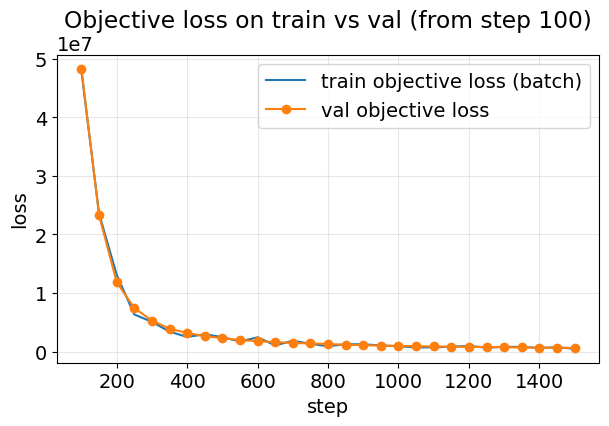

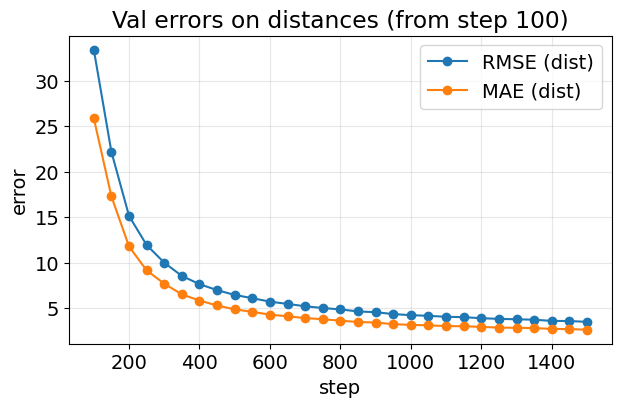

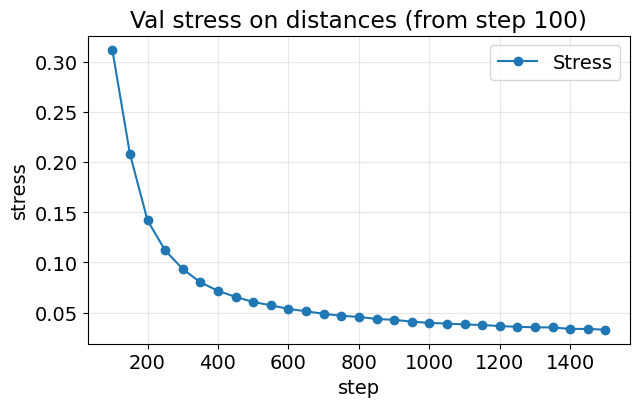

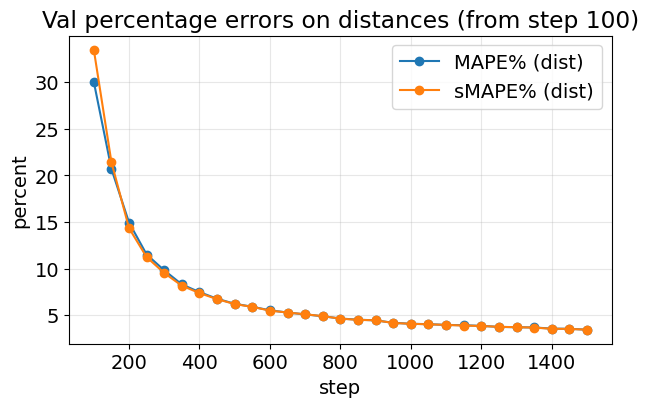

Best by VAL LOSS: step=1500 val_loss=612494.937500
  [best val dist] RMSE=3.495 MAE=2.631 MAPE=3.45% sMAPE=3.45% Pearson=0.9966 Spearman=0.9965 Stress=0.032871
[LM] FINAL val objective loss=621890.000000
[LM] FINAL val distances: RMSE=3.479 MAE=2.629 MAPE=3.47% sMAPE=3.46% Pearson=0.9967 Spearman=0.9965 Stress=0.032680
------------------------------
[Vision] X=(1755, 3584), pairs_train=1231308, pairs_val=307827, dim=3584, m=3
Init A = alpha*I, alpha=7.759919, ||A||=13.4406, size=(3, 3584)
step=50/1500 train_loss(batch)=194561536.000000 ||grad||=5419921.000 ||A||=13.547
  [val objective] loss=214383296.000000
  [val dist] RMSE=96.763 MAE=87.412 MAPE=88.14% sMAPE=159.83% Pearson=0.2765 Spearman=0.2838 Stress=0.553834
step=100/1500 train_loss(batch)=214284384.000000 ||grad||=10660971.000 ||A||=13.818
  [val objective] loss=204407904.000000
  [val dist] RMSE=88.592 MAE=78.418 MAPE=77.74% sMAPE=132.89% Pearson=0.2429 Spearman=0.2438 Stress=0.586706
step=150/1500 train_loss(batch)=208585472.

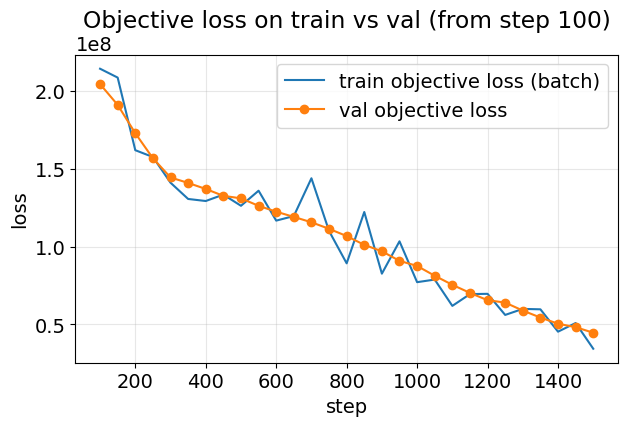

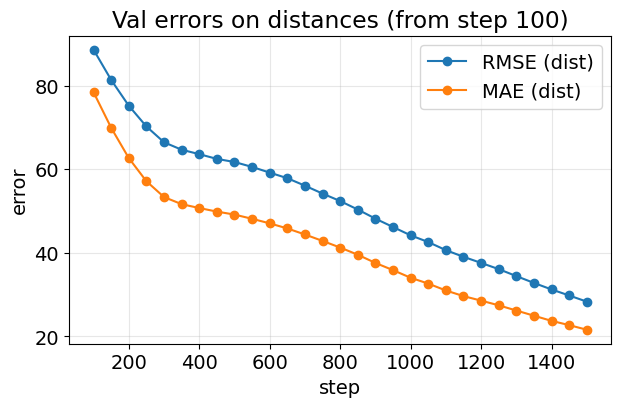

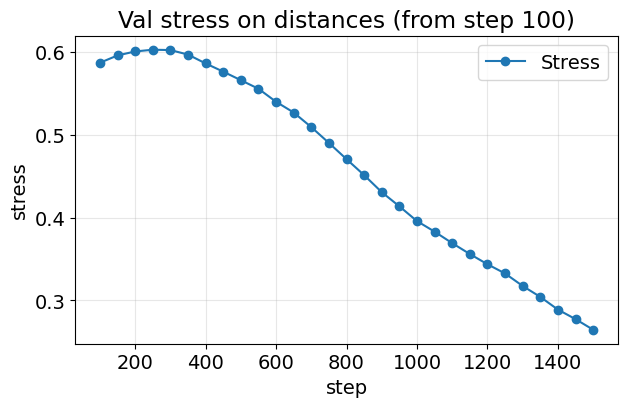

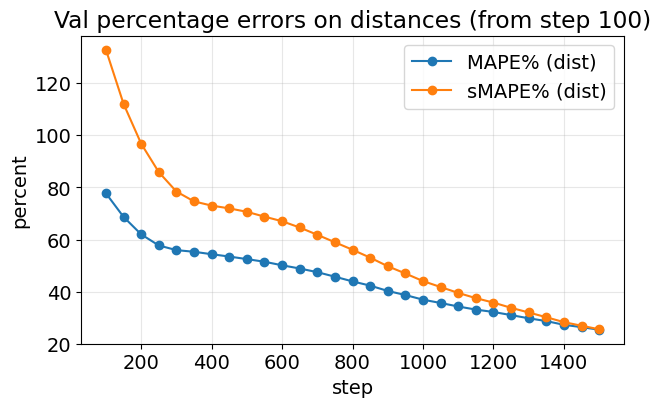

Best by VAL LOSS: step=1500 val_loss=44713812.000000
  [best val dist] RMSE=28.323 MAE=21.601 MAPE=25.36% sMAPE=25.53% Pearson=0.7677 Spearman=0.7739 Stress=0.264739
[Vision] FINAL val objective loss=44724912.000000
[Vision] FINAL val distances: RMSE=28.327 MAE=21.582 MAPE=25.32% sMAPE=25.50% Pearson=0.7687 Spearman=0.7744 Stress=0.264435
m_dim = 10
[LM] X=(1755, 3584), pairs_train=1231308, pairs_val=307827, dim=3584, m=10
Init A = alpha*I, alpha=0.736407, ||A||=2.3287, size=(10, 3584)
step=50/1500 train_loss(batch)=53481200.000000 ||grad||=52054968.000 ||A||=3.002
  [val objective] loss=55256752.000000
  [val dist] RMSE=32.104 MAE=24.931 MAPE=29.31% sMAPE=29.63% Pearson=0.7063 Spearman=0.7060 Stress=0.298219
step=100/1500 train_loss(batch)=15506892.000000 ||grad||=18178984.000 ||A||=3.689
  [val objective] loss=15598561.000000
  [val dist] RMSE=17.060 MAE=13.322 MAPE=16.58% sMAPE=16.01% Pearson=0.9166 Spearman=0.9137 Stress=0.160488
step=150/1500 train_loss(batch)=6901536.000000 ||gra

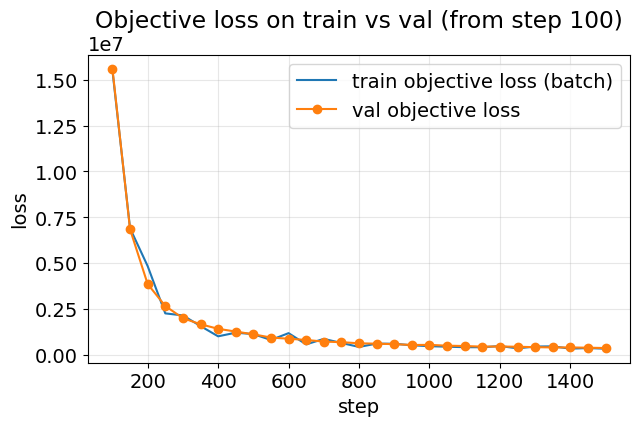

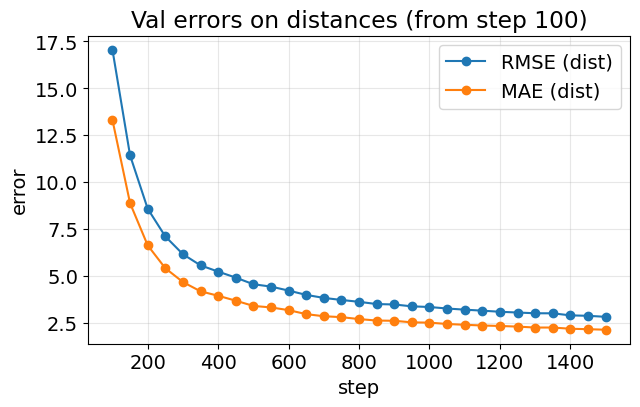

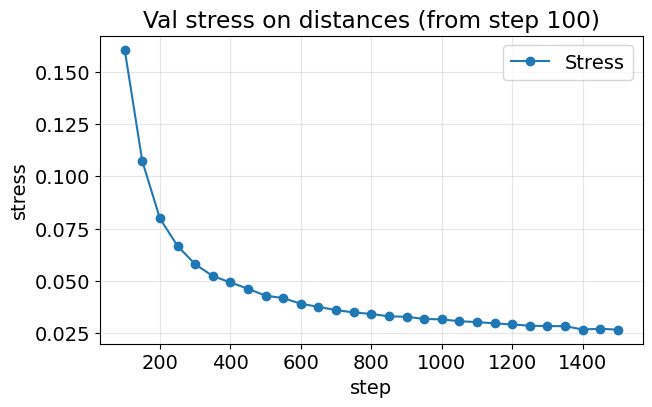

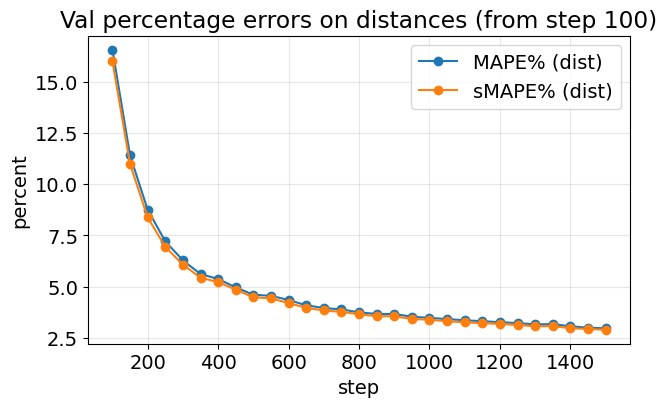

Best by VAL LOSS: step=1500 val_loss=371894.437500
  [best val dist] RMSE=2.838 MAE=2.151 MAPE=2.96% sMAPE=2.89% Pearson=0.9978 Spearman=0.9977 Stress=0.026653
[LM] FINAL val objective loss=380010.031250
[LM] FINAL val distances: RMSE=2.830 MAE=2.145 MAPE=2.96% sMAPE=2.89% Pearson=0.9978 Spearman=0.9978 Stress=0.026547
------------------------------
[Vision] X=(1755, 3584), pairs_train=1231308, pairs_val=307827, dim=3584, m=10
Init A = alpha*I, alpha=7.759919, ||A||=24.5390, size=(10, 3584)
step=50/1500 train_loss(batch)=185058464.000000 ||grad||=9907496.000 ||A||=24.738
  [val objective] loss=204519904.000000
  [val dist] RMSE=88.430 MAE=78.087 MAPE=77.20% sMAPE=131.10% Pearson=0.2355 Spearman=0.2478 Stress=0.571973
step=100/1500 train_loss(batch)=185606928.000000 ||grad||=14282778.000 ||A||=25.242
  [val objective] loss=176267008.000000
  [val dist] RMSE=75.785 MAE=63.510 MAPE=62.64% sMAPE=98.12% Pearson=0.2245 Spearman=0.2292 Stress=0.593202
step=150/1500 train_loss(batch)=168491568

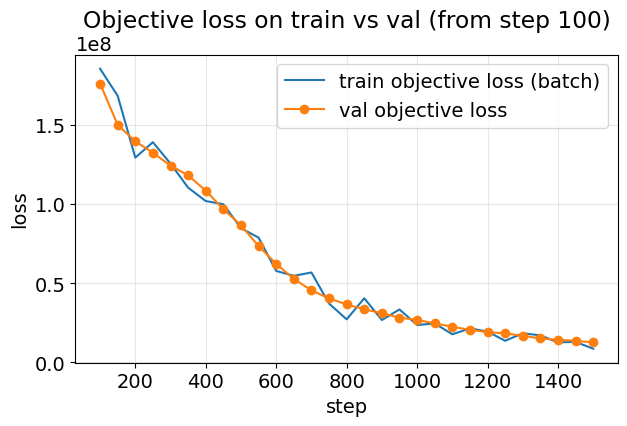

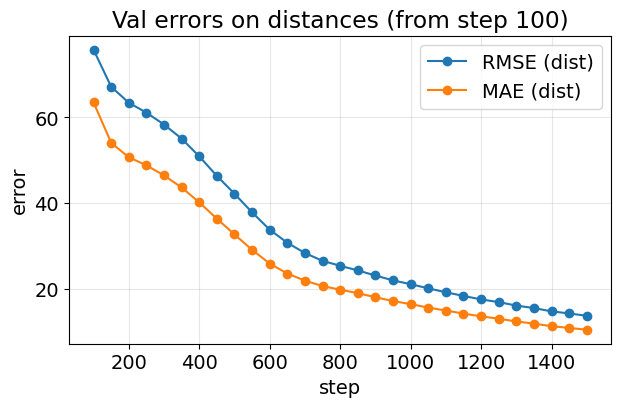

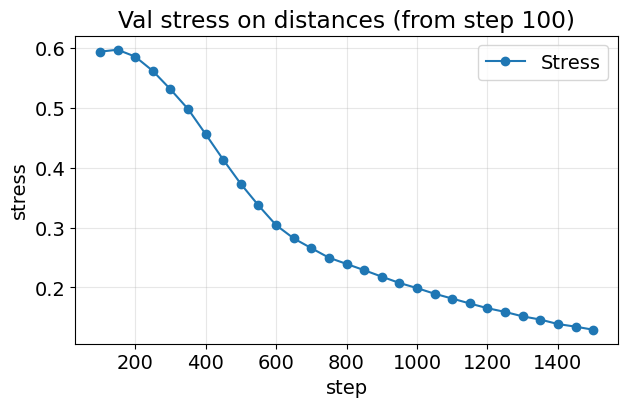

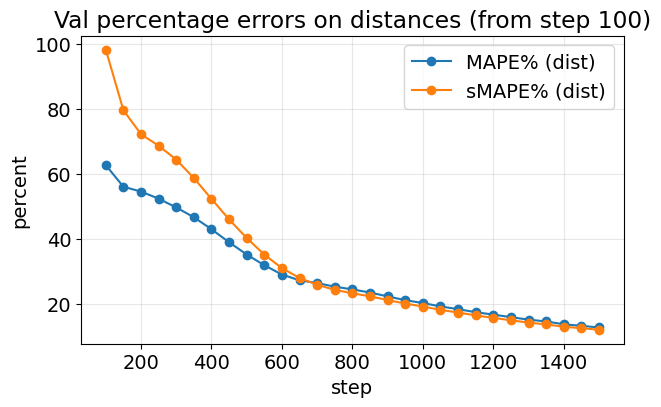

Best by VAL LOSS: step=1500 val_loss=12677335.000000
  [best val dist] RMSE=13.805 MAE=10.562 MAPE=12.80% sMAPE=12.10% Pearson=0.9474 Spearman=0.9520 Stress=0.129569
[Vision] FINAL val objective loss=12660899.000000
[Vision] FINAL val distances: RMSE=13.782 MAE=10.544 MAPE=12.78% sMAPE=12.09% Pearson=0.9476 Spearman=0.9521 Stress=0.129195
m_dim = 32
[LM] X=(1755, 3584), pairs_train=1231308, pairs_val=307827, dim=3584, m=32
Init A = alpha*I, alpha=0.736407, ||A||=4.1657, size=(32, 3584)
step=50/1500 train_loss(batch)=22299324.000000 ||grad||=26070586.000 ||A||=4.935
  [val objective] loss=22904990.000000
  [val dist] RMSE=20.309 MAE=15.982 MAPE=20.05% sMAPE=18.81% Pearson=0.8817 Spearman=0.8815 Stress=0.190114
step=100/1500 train_loss(batch)=5697336.000000 ||grad||=9646826.000 ||A||=5.723
  [val objective] loss=5780501.500000
  [val dist] RMSE=10.280 MAE=7.914 MAPE=10.21% sMAPE=9.82% Pearson=0.9706 Spearman=0.9696 Stress=0.096676
step=150/1500 train_loss(batch)=3417951.000000 ||grad||=1

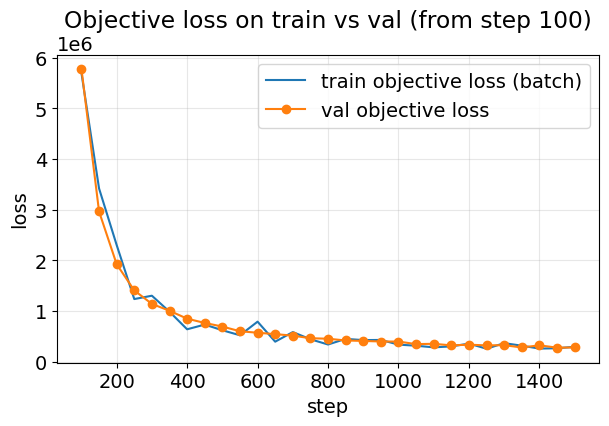

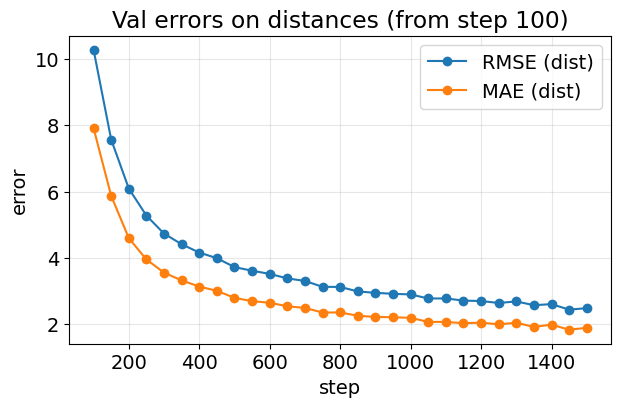

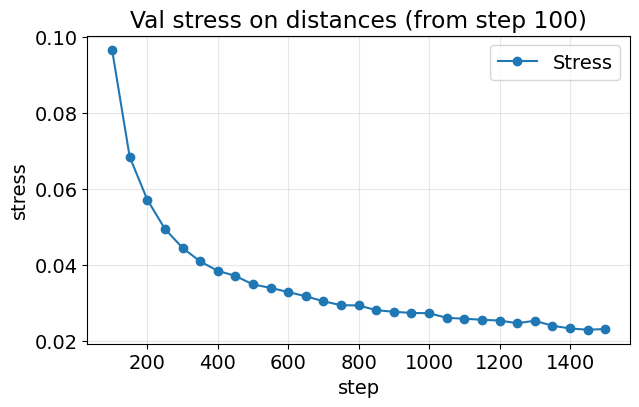

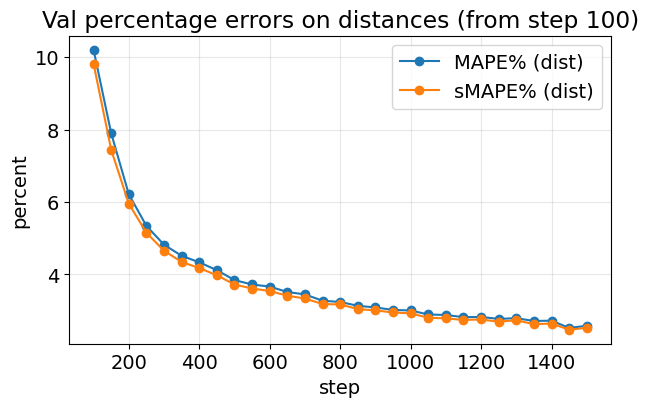

Best by VAL LOSS: step=1450 val_loss=276156.156250
  [best val dist] RMSE=2.440 MAE=1.835 MAPE=2.53% sMAPE=2.47% Pearson=0.9984 Spearman=0.9983 Stress=0.022913
[LM] FINAL val objective loss=276362.531250
[LM] FINAL val distances: RMSE=2.428 MAE=1.826 MAPE=2.53% sMAPE=2.47% Pearson=0.9984 Spearman=0.9983 Stress=0.022787
------------------------------
[Vision] X=(1755, 3584), pairs_train=1231308, pairs_val=307827, dim=3584, m=32
Init A = alpha*I, alpha=7.759919, ||A||=43.8967, size=(32, 3584)
step=50/1500 train_loss(batch)=157992000.000000 ||grad||=13570798.000 ||A||=44.272
  [val objective] loss=176420016.000000
  [val dist] RMSE=74.991 MAE=62.750 MAPE=61.53% sMAPE=94.71% Pearson=0.2298 Spearman=0.2455 Stress=0.569030
step=100/1500 train_loss(batch)=149879584.000000 ||grad||=4178759.500 ||A||=45.143
  [val objective] loss=139819168.000000
  [val dist] RMSE=61.974 MAE=49.669 MAPE=53.57% sMAPE=68.48% Pearson=0.2515 Spearman=0.2610 Stress=0.572334
step=150/1500 train_loss(batch)=141212064.

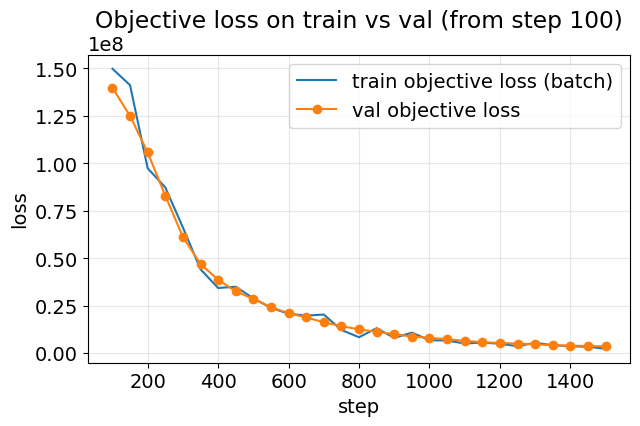

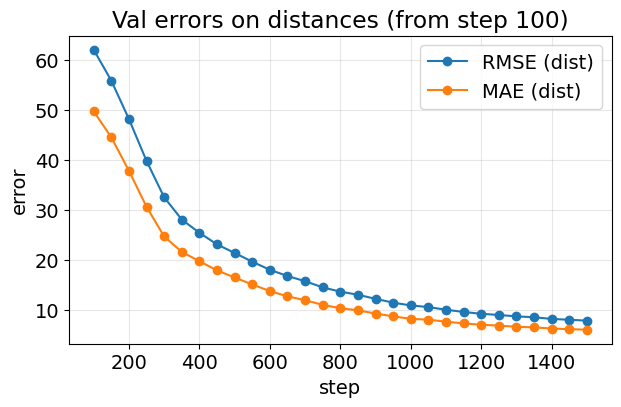

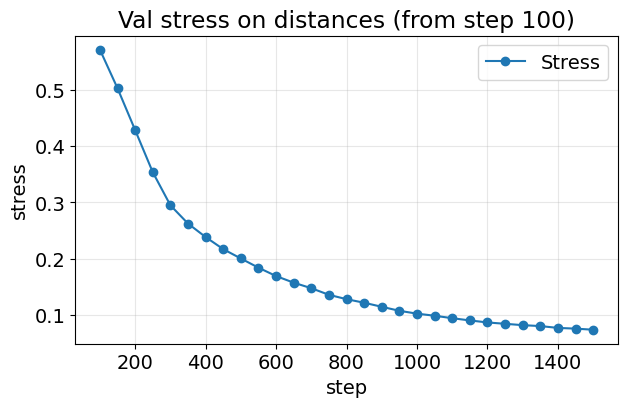

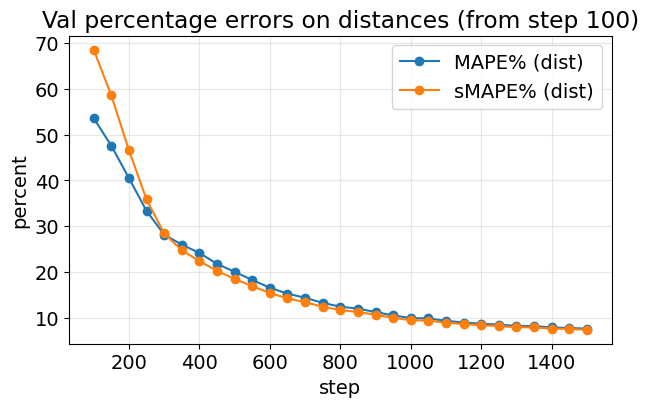

Best by VAL LOSS: step=1500 val_loss=3530571.750000
  [best val dist] RMSE=7.807 MAE=5.996 MAPE=7.67% sMAPE=7.45% Pearson=0.9835 Spearman=0.9840 Stress=0.073054
[Vision] FINAL val objective loss=3515215.500000
[Vision] FINAL val distances: RMSE=7.749 MAE=5.950 MAPE=7.63% sMAPE=7.40% Pearson=0.9837 Spearman=0.9843 Stress=0.072451
m_dim = 104
[LM] X=(1755, 3584), pairs_train=1231308, pairs_val=307827, dim=3584, m=104
Init A = alpha*I, alpha=0.736407, ||A||=7.5099, size=(104, 3584)
step=50/1500 train_loss(batch)=8923708.000000 ||grad||=18127716.000 ||A||=8.241
  [val objective] loss=9944442.000000
  [val dist] RMSE=13.573 MAE=10.586 MAPE=13.77% sMAPE=12.79% Pearson=0.9501 Spearman=0.9478 Stress=0.126190
step=100/1500 train_loss(batch)=2357861.500000 ||grad||=6548289.500 ||A||=8.931
  [val objective] loss=2798018.250000
  [val dist] RMSE=7.080 MAE=5.407 MAPE=7.15% sMAPE=6.82% Pearson=0.9868 Spearman=0.9872 Stress=0.065510
step=150/1500 train_loss(batch)=1890026.750000 ||grad||=12383339.000

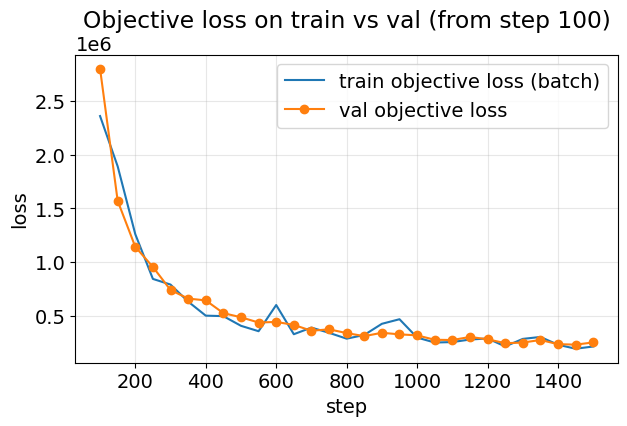

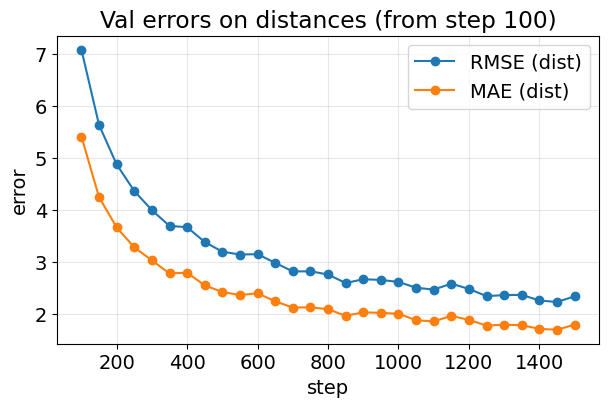

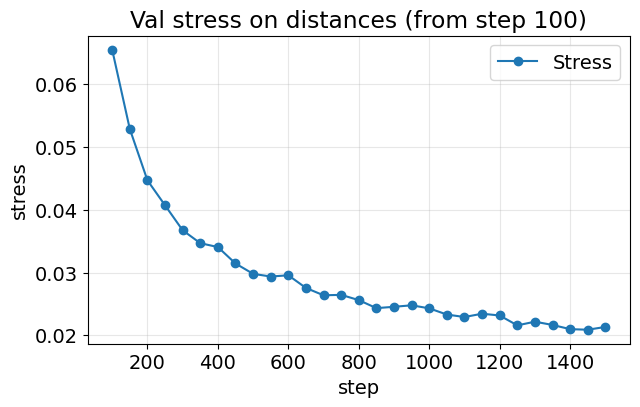

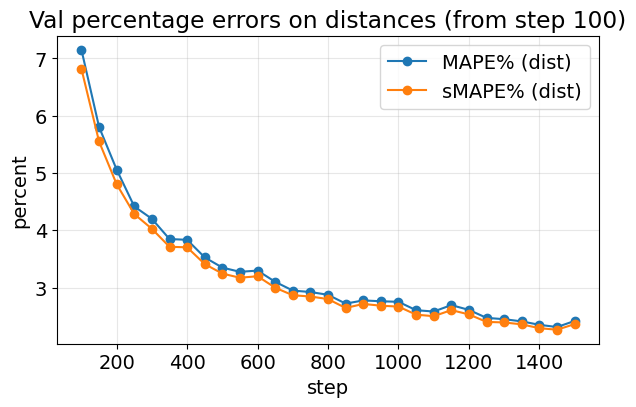

Best by VAL LOSS: step=1450 val_loss=231973.203125
  [best val dist] RMSE=2.226 MAE=1.693 MAPE=2.31% sMAPE=2.27% Pearson=0.9987 Spearman=0.9986 Stress=0.020897
[LM] FINAL val objective loss=231001.437500
[LM] FINAL val distances: RMSE=2.219 MAE=1.688 MAPE=2.32% sMAPE=2.27% Pearson=0.9987 Spearman=0.9986 Stress=0.020827
------------------------------
[Vision] X=(1755, 3584), pairs_train=1231308, pairs_val=307827, dim=3584, m=104
Init A = alpha*I, alpha=7.759919, ||A||=79.1360, size=(104, 3584)
step=50/1500 train_loss(batch)=122766576.000000 ||grad||=3284692.250 ||A||=79.792
  [val objective] loss=138725632.000000
  [val dist] RMSE=60.296 MAE=48.166 MAPE=51.58% sMAPE=63.98% Pearson=0.2519 Spearman=0.2703 Stress=0.551285
step=100/1500 train_loss(batch)=115629736.000000 ||grad||=6065299.000 ||A||=80.573
  [val objective] loss=105587464.000000
  [val dist] RMSE=47.102 MAE=36.808 MAPE=39.39% sMAPE=44.38% Pearson=0.4617 Spearman=0.4851 Stress=0.418433
step=150/1500 train_loss(batch)=79097136.

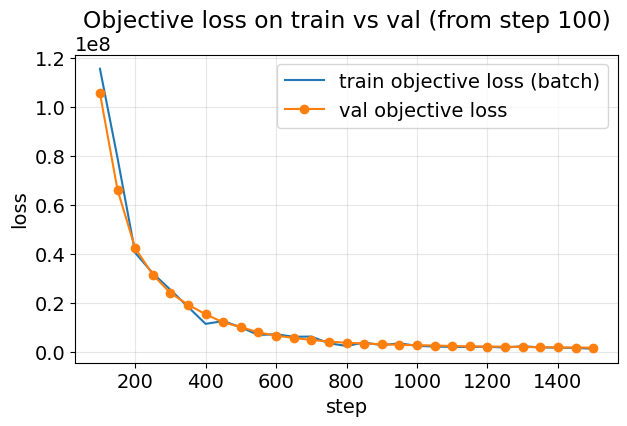

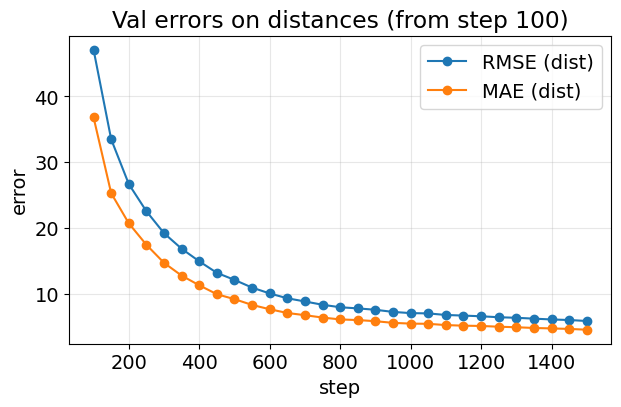

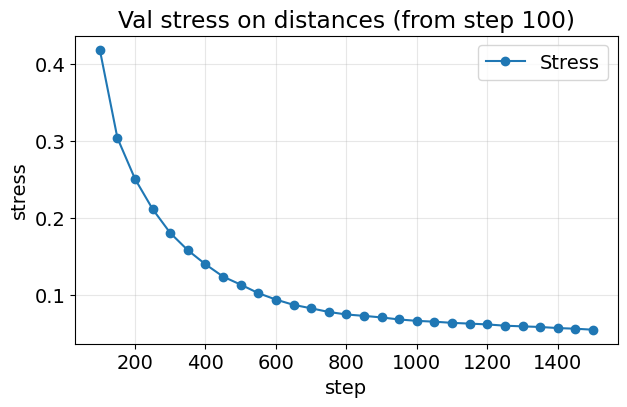

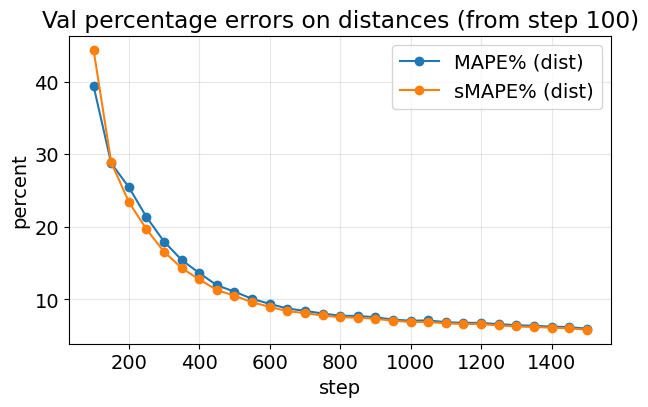

Best by VAL LOSS: step=1500 val_loss=1640228.000000
  [best val dist] RMSE=5.821 MAE=4.494 MAPE=5.98% sMAPE=5.84% Pearson=0.9908 Spearman=0.9903 Stress=0.054484
[Vision] FINAL val objective loss=1617705.375000
[Vision] FINAL val distances: RMSE=5.775 MAE=4.456 MAPE=5.94% sMAPE=5.80% Pearson=0.9909 Spearman=0.9905 Stress=0.054017
m_dim = 338
[LM] X=(1755, 3584), pairs_train=1231308, pairs_val=307827, dim=3584, m=338
Init A = alpha*I, alpha=0.736407, ||A||=13.5387, size=(338, 3584)
step=50/1500 train_loss(batch)=3819121.250000 ||grad||=16511985.000 ||A||=14.227
  [val objective] loss=4682228.000000
  [val dist] RMSE=9.276 MAE=7.196 MAPE=9.68% sMAPE=9.08% Pearson=0.9772 Spearman=0.9760 Stress=0.087199
step=100/1500 train_loss(batch)=1515384.250000 ||grad||=5653525.500 ||A||=14.595
  [val objective] loss=1726052.375000
  [val dist] RMSE=5.705 MAE=4.287 MAPE=5.84% sMAPE=5.57% Pearson=0.9913 Spearman=0.9912 Stress=0.053609
step=150/1500 train_loss(batch)=1509111.750000 ||grad||=11477780.000 

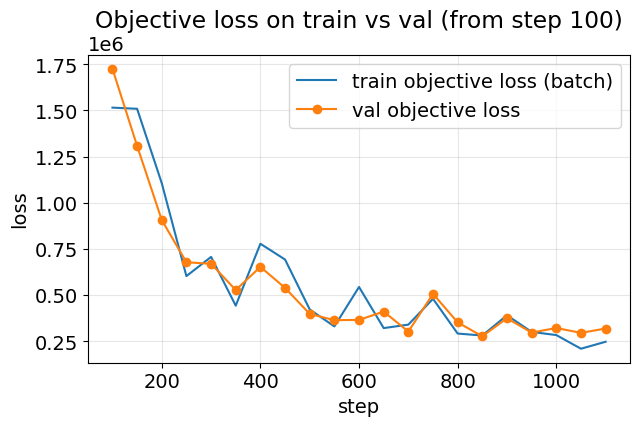

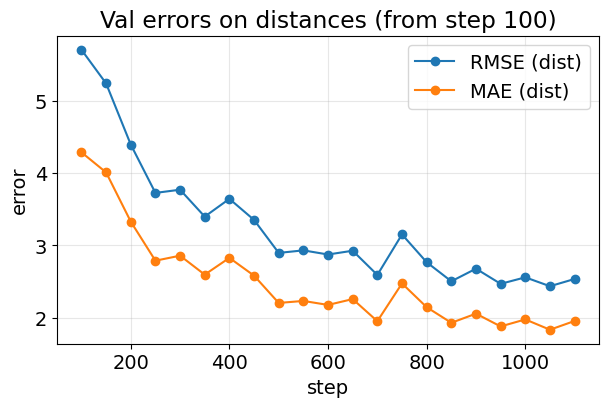

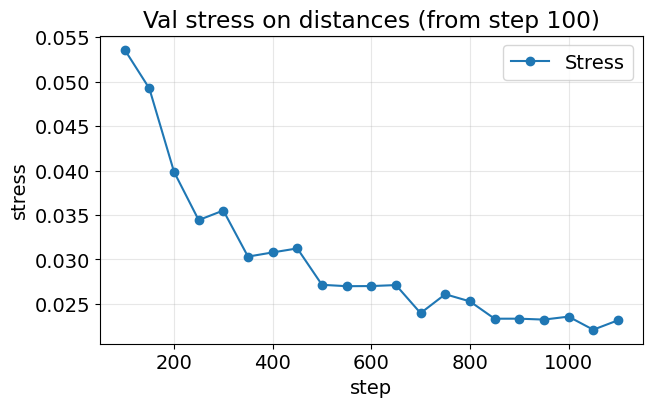

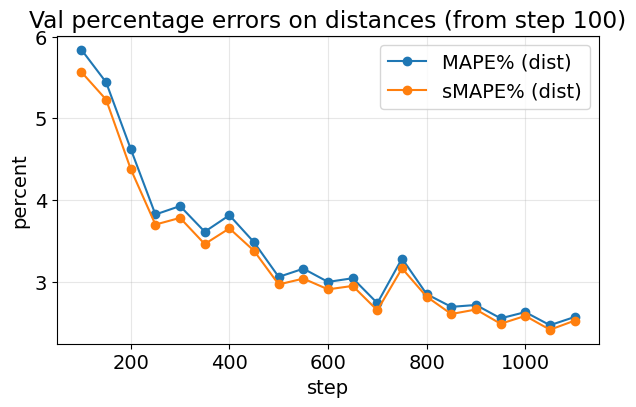

Best by VAL LOSS: step=850 val_loss=277353.843750
  [best val dist] RMSE=2.504 MAE=1.930 MAPE=2.70% sMAPE=2.61% Pearson=0.9984 Spearman=0.9983 Stress=0.023323
[LM] FINAL val objective loss=279602.656250
[LM] FINAL val distances: RMSE=2.509 MAE=1.929 MAPE=2.68% sMAPE=2.60% Pearson=0.9984 Spearman=0.9983 Stress=0.023368
------------------------------
[Vision] X=(1755, 3584), pairs_train=1231308, pairs_val=307827, dim=3584, m=338
Init A = alpha*I, alpha=7.759919, ||A||=142.6644, size=(338, 3584)
step=50/1500 train_loss(batch)=93093920.000000 ||grad||=5226496.000 ||A||=143.385
  [val objective] loss=104271456.000000
  [val dist] RMSE=45.892 MAE=35.470 MAPE=37.80% sMAPE=41.48% Pearson=0.4637 Spearman=0.4894 Stress=0.404234
step=100/1500 train_loss(batch)=51010976.000000 ||grad||=3587299.500 ||A||=145.022
  [val objective] loss=45167324.000000
  [val dist] RMSE=27.017 MAE=20.699 MAPE=25.19% sMAPE=23.11% Pearson=0.7735 Spearman=0.7903 Stress=0.254303
step=150/1500 train_loss(batch)=34425616.0

In [ ]:
# ============================================================
# Usage (emb pairs dist -> pairs cam dist)
# ============================================================
max_common_dim = min(lm.shape[1], vl.shape[1])

# например 7-8 точек по логарифмической шкале
m_dims = make_log_m_grid(max_dim=max_common_dim, min_dim=3, n_points=7, include_max=True)
print("m_dims:", m_dims)

rows = []
for i in range(cam_dist.shape[0]):
    for j in range(i, cam_dist.shape[1]):
        rows.append({
            "dataset": 'musell',
            "i": int(i),
            "j": int(j),
            "dv": cam_dist[i,j],
        })

pairs_df = pd.DataFrame(rows)

res_munsell_cam_fit = {}
for m in m_dims:
    print("=" * 80)
    print(f"m_dim = {m}")

    out_lm = run_fullA_experiment_pairs(
        lm,
        pairs_df,
        dataset_name="musell",
        layer_name="LM",
        m_dim=m
    )

    print("-" * 30)

    out_vl = run_fullA_experiment_pairs(
        vl,
        pairs_df,
        dataset_name="musell",
        layer_name="Vision",
        m_dim=m
    )

    res_munsell_cam_fit[m] = {
        "lm": out_lm,
        "vision": out_vl
    }

plot_quality_vs_m(res_munsell_cam_fit)


In [ ]:
from utils.analyze.tsne_before_after_munsell import (
    default_chroma_subset_spec,
    tsne_before_after_on_munsell_subset,
    plot_tsne_before_after,
)


# ДОДЕЛАТЬ ВЫБОР ЛУЧШЕГО A для каждого слоя и для них простроить преобрзаовние 
# ...
# ...
# ...
spec = default_chroma_subset_spec(perplexity=7)
A_lm = out_lm["A"]   # (d, d)
A_vl = out_vl["A"]   # (d, d)

lm_after = lm @ A_lm.T
vl_after = vl @ A_vl.T

# LM
res_lm = tsne_before_after_on_munsell_subset(
    embeddings_before=lm,        # исходные LM эмбеддинги
    embeddings_after=lm_after,  # после Ridge
    spec=spec,
)
print("LM missing specs:", res_lm.missing_specs)  # если какие-то H/V/C отсутствуют в CSV
plot_tsne_before_after(res_lm, title_prefix="LM")

# Vision
res_vl = tsne_before_after_on_munsell_subset(
    embeddings_before=vl,
    embeddings_after=vl_after,
    spec=spec,
)
print("Vision missing specs:", res_vl.missing_specs)
plot_tsne_before_after(res_vl, title_prefix="Vision")


# Обучение отображения A из пространства эмбедингов в CAM пространство цветов 

LM layer: R² = 0.9996, RMSE = 0.6242 (TEST)
LM layer:
  Rmse(dist_true, dist_pred) = 0.9010
  Pearson(dist_true, dist_pred) = 0.9995 (p = 0.00e+00)
  Spearman(dist_true, dist_pred) = 0.9995 (p = 0.00e+00)
  STRESS(dist_emp, dist_true) = 0.012


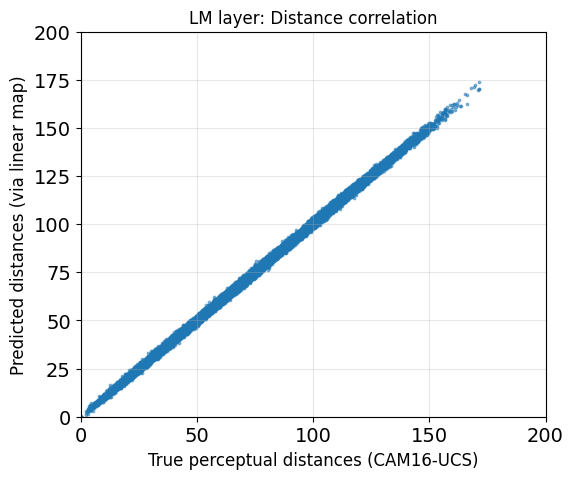

LM layer: Matrix W shape = (3, 3584), Bias b shape = (3,)
Vision layer: R² = 0.9990, RMSE = 0.9901 (TEST)
Vision layer:
  Rmse(dist_true, dist_pred) = 2.3420
  Pearson(dist_true, dist_pred) = 0.9986 (p = 0.00e+00)
  Spearman(dist_true, dist_pred) = 0.9987 (p = 0.00e+00)
  STRESS(dist_emp, dist_true) = 0.020


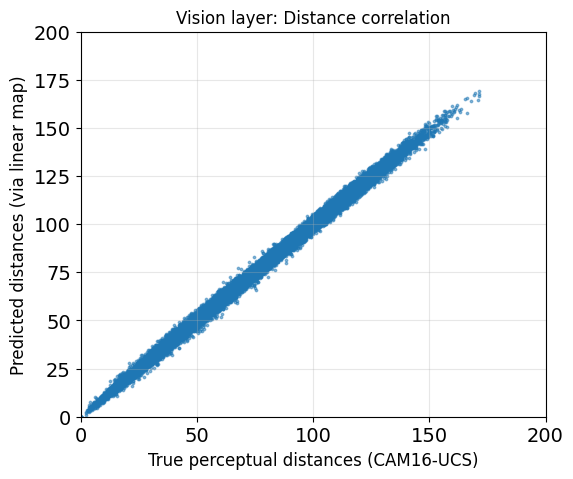

Vision layer: Matrix W shape = (3, 3584), Bias b shape = (3,)


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score, pairwise_distances
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt

def linear_color_mapping(embeddings, colors_cam, layer_name="LM"):
    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        embeddings, colors_cam, test_size=0.2, random_state=42
    )

    # Линейное отображение
    reg = Ridge(alpha=1.0)
    reg.fit(X_train, y_train)
    y_pred_test = reg.predict(X_test)

    # Оценка точности
    r2 = r2_score(y_test, y_pred_test, multioutput='variance_weighted')
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    print(f"{layer_name} layer: R² = {r2:.4f}, RMSE = {rmse:.4f} (TEST)")

    # Глобальный анализ через pairwise distances
    D_emb = pairwise_distances(X_test, metric='cosine')
    D_true = pairwise_distances(y_test, metric='euclidean')
    D_pred = pairwise_distances(y_pred_test, metric='euclidean')

    n = X_test.shape[0]
    triu_idx = np.triu_indices(n, k=1)
    v_emb = D_emb[triu_idx]
    v_true = D_true[triu_idx]
    v_pred = D_pred[triu_idx]

    dist_rmse = mean_squared_error(v_true, v_pred)
    pearson_r, pearson_p = pearsonr(v_true, v_pred)
    spearman_res = spearmanr(v_true, v_pred)
    spearman_r = getattr(spearman_res, 'correlation', spearman_res.statistic)
    spearman_p = spearman_res.pvalue

    emb_true_pr, emb_true_pp = pearsonr(v_emb, v_true)
    emb_true_sr = spearmanr(v_emb, v_true)
    emb_true_sr_r = getattr(emb_true_sr, 'correlation', emb_true_sr.statistic)
    emb_true_sr_p = emb_true_sr.pvalue
    stress = safe_stress(v_true, v_pred)

    emb_pred_pr, emb_pred_pp = pearsonr(v_emb, v_pred)

    print(f"{layer_name} layer:")
    print(f"  Rmse(dist_true, dist_pred) = {dist_rmse:.4f}")
    print(f"  Pearson(dist_true, dist_pred) = {pearson_r:.4f} (p = {pearson_p:.2e})")
    print(f"  Spearman(dist_true, dist_pred) = {spearman_r:.4f} (p = {spearman_p:.2e})")
    # print(f"  Pearson(dist_emb, dist_true)   = {emb_true_pr:.4f} (p = {emb_true_pp:.2e})")
    # print(f"  Spearman(dist_emb, dist_true)  = {emb_true_sr_r:.4f} (p = {emb_true_sr_p:.2e})")
    # print(f"  Pearson(dist_emb, dist_pred)   = {emb_pred_pr:.4f} (p = {emb_pred_pp:.2e})")
    print(f"  STRESS(dist_emp, dist_true) = {stress:.3f}")


    # Визуализация согласованности расстояний
    plt.figure(figsize=(6,5))
    plt.scatter(v_true, v_pred, s=3, alpha=0.5)
    plt.xlabel('True perceptual distances (CAM16-UCS)', fontsize=12)
    plt.ylabel('Predicted distances (via linear map)', fontsize=12)
    plt.title(f'{layer_name} layer: Distance correlation', fontsize=12)
    plt.xlim(0,200)
    plt.ylim(0,200)
    plt.grid(True, alpha=0.3)
    plt.savefig(f"{layer_name}_linear_regression.png", dpi=200)
    plt.show()

    # Матрица линейного преобразования и bias
    W = reg.coef_
    b = reg.intercept_
    print(f"{layer_name} layer: Matrix W shape = {W.shape}, Bias b shape = {b.shape}")

    return W, b

# === LM layer ===
W_lm, b_lm = linear_color_mapping(lm, cam, layer_name="LM")

# === Vision layer ===
W_vl, b_vl = linear_color_mapping(vl, cam, layer_name="Vision")


LM missing specs: ['5.0Y 5/0', '5.0G 5/0', '5.0G 5/8', '5.0P 5/0', '5.0B 5/0']


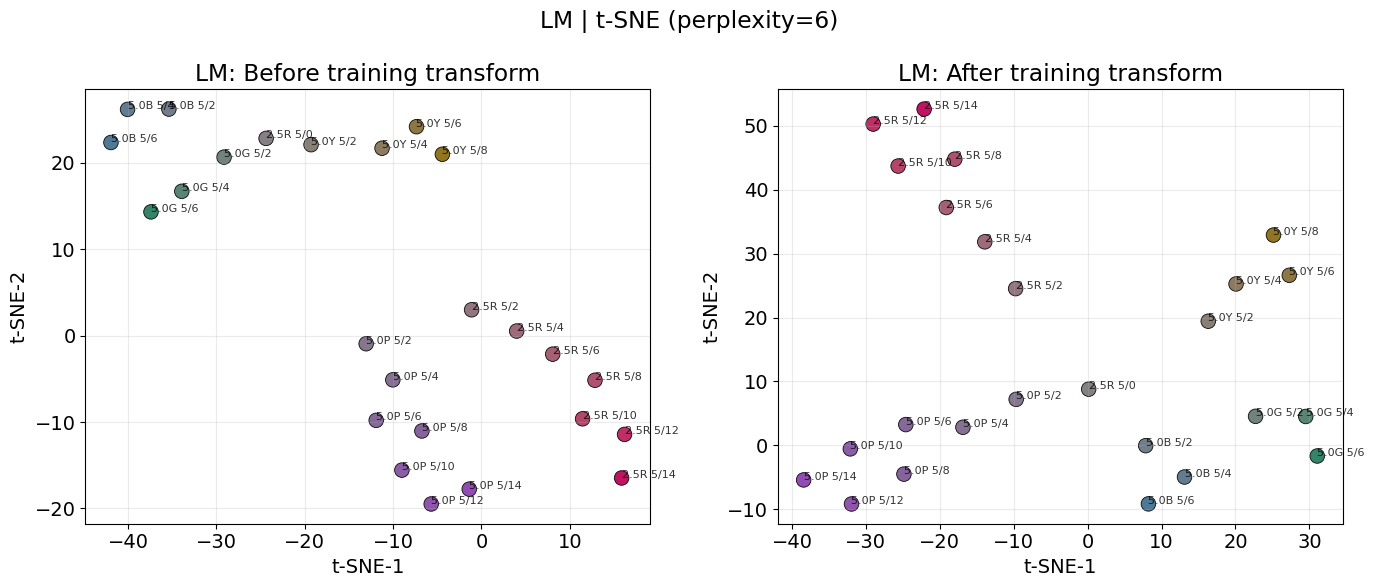

Vision missing specs: ['5.0Y 5/0', '5.0G 5/0', '5.0G 5/8', '5.0P 5/0', '5.0B 5/0']


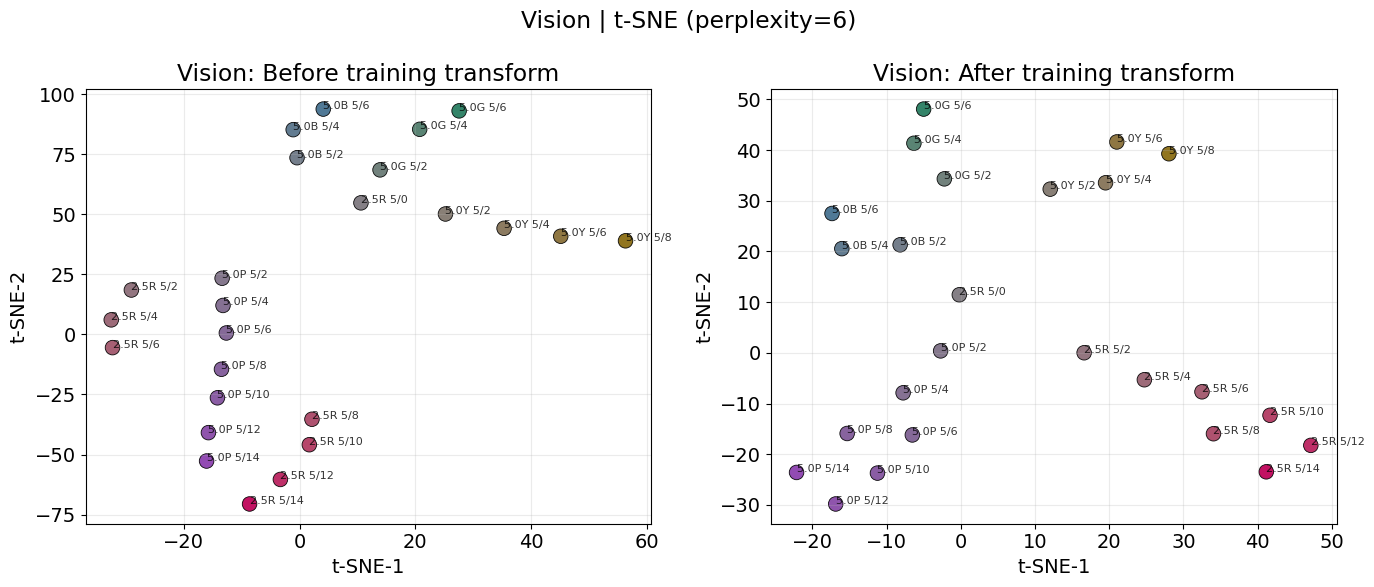

In [ ]:
from utils.analyze.tsne_before_after_munsell import (
    default_chroma_subset_spec,
    tsne_before_after_on_munsell_subset,
    plot_tsne_before_after,
)

spec = default_chroma_subset_spec(perplexity=6)

# LM
res_lm = tsne_before_after_on_munsell_subset(
    embeddings_before=lm,        # исходные LM эмбеддинги
    embeddings_after=y_pred_lm,  # после Ridge
    spec=spec,
)
print("LM missing specs:", res_lm.missing_specs)  # если какие-то H/V/C отсутствуют в CSV
plot_tsne_before_after(res_lm, title_prefix="LM")

# Vision
res_vl = tsne_before_after_on_munsell_subset(
    embeddings_before=vl,
    embeddings_after=y_pred_vl,
    spec=spec,
)
print("Vision missing specs:", res_vl.missing_specs)
plot_tsne_before_after(res_vl, title_prefix="Vision")


# Построение преобразвоания которое приближает расстояние между эмбедингами к психофизическому

[LM] X_tr=(1404, 3584), X_te=(351, 3584), dim=3584
Init A = alpha*I, alpha=0.739336, ||A||=44.2615
step=200/1200 train_loss(batch)=832674.375000 ||grad||=16737375.000 ||A||=44.849
  [val objective] loss=747253.062500
  [val sq]   RMSE=863.150 MAE=628.827 MAPE=10.65% sMAPE=9.06% Pearson=0.9961 Spearman=0.9956
  [val dist] RMSE=4.253 MAE=3.311 MAPE=4.89% sMAPE=4.57% Pearson=0.9959 Spearman=0.9956
step=400/1200 train_loss(batch)=602884.562500 ||grad||=9321348.000 ||A||=45.024
  [val objective] loss=702880.500000
  [val sq]   RMSE=836.488 MAE=544.004 MAPE=7.90% sMAPE=7.24% Pearson=0.9966 Spearman=0.9966
  [val dist] RMSE=3.584 MAE=2.740 MAPE=3.77% sMAPE=3.64% Pearson=0.9968 Spearman=0.9966
step=600/1200 train_loss(batch)=427571.937500 ||grad||=6862223.000 ||A||=45.176
  [val objective] loss=1124757.500000
  [val sq]   RMSE=1053.721 MAE=747.579 MAPE=10.81% sMAPE=9.61% Pearson=0.9941 Spearman=0.9950
  [val dist] RMSE=4.766 MAE=3.767 MAPE=5.10% sMAPE=4.83% Pearson=0.9950 Spearman=0.9950
step=

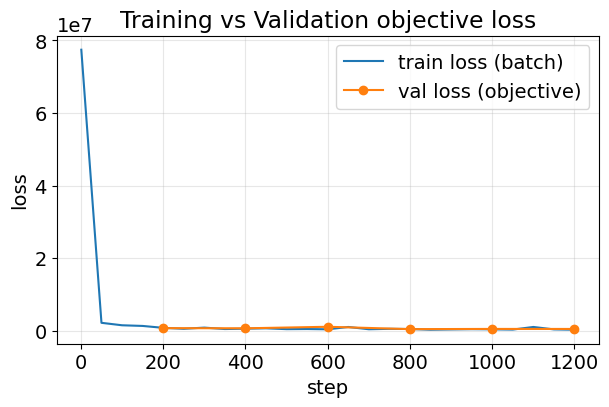

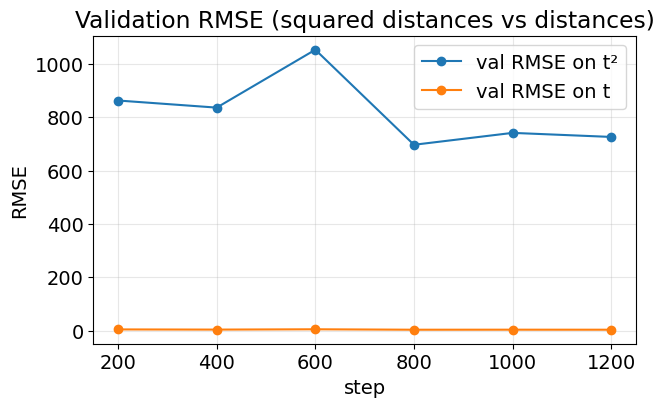

Best by VAL LOSS: step=800 val_loss=472646.562500
  [best val sq]   RMSE=697.066 MAE=487.956 MAPE=7.01% sMAPE=6.50% Pearson=0.9971 Spearman=0.9971
  [best val dist] RMSE=3.125 MAE=2.461 MAPE=3.35% sMAPE=3.25% Pearson=0.9973 Spearman=0.9971
[LM] FINAL test objective loss=480757.968750
[LM] FINAL test (sq):   RMSE=694.668 MAE=487.341 MAPE=7.03% sMAPE=6.53% Pearson=0.9971 Spearman=0.9971
[LM] FINAL test (dist): RMSE=3.143 MAE=2.472 MAPE=3.38% sMAPE=3.28% Pearson=0.9972 Spearman=0.9971


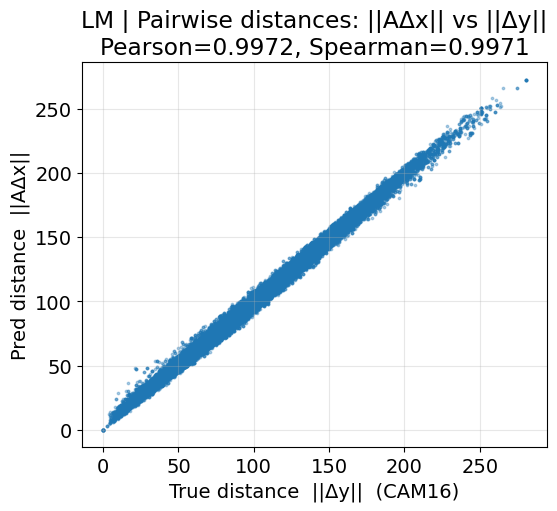

------------------------------
[Vision] X_tr=(1404, 3584), X_te=(351, 3584), dim=3584
Init A = alpha*I, alpha=7.740572, ||A||=463.4012
step=200/1200 train_loss(batch)=2384020.000000 ||grad||=551036.312 ||A||=468.427
  [val objective] loss=2078572.125000
  [val sq]   RMSE=1448.155 MAE=1024.844 MAPE=15.92% sMAPE=13.85% Pearson=0.9879 Spearman=0.9852
  [val dist] RMSE=6.913 MAE=5.344 MAPE=7.38% sMAPE=6.98% Pearson=0.9869 Spearman=0.9851
step=400/1200 train_loss(batch)=1012061.625000 ||grad||=636207.750 ||A||=470.402
  [val objective] loss=986514.000000
  [val sq]   RMSE=992.070 MAE=707.475 MAPE=10.95% sMAPE=9.81% Pearson=0.9941 Spearman=0.9930
  [val dist] RMSE=4.812 MAE=3.698 MAPE=5.15% sMAPE=4.92% Pearson=0.9937 Spearman=0.9931
step=600/1200 train_loss(batch)=916341.562500 ||grad||=451564.188 ||A||=471.889
  [val objective] loss=660113.437500
  [val sq]   RMSE=809.970 MAE=572.937 MAPE=8.87% sMAPE=8.06% Pearson=0.9962 Spearman=0.9955
  [val dist] RMSE=3.897 MAE=2.980 MAPE=4.20% sMAPE=4.0

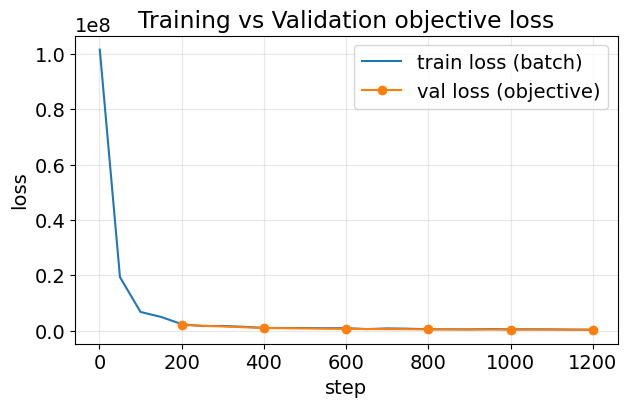

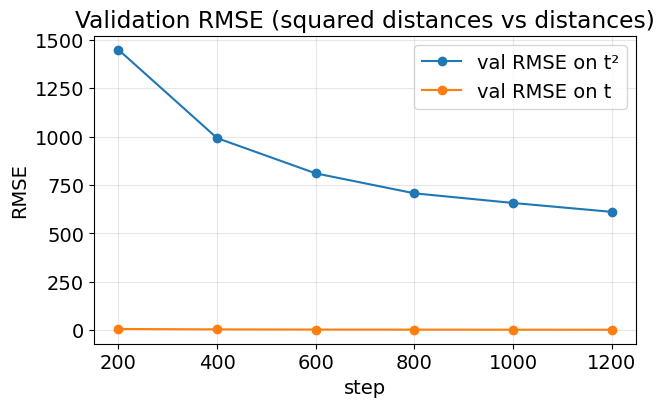

Best by VAL LOSS: step=1200 val_loss=371279.875000
  [best val sq]   RMSE=611.330 MAE=433.949 MAPE=6.62% sMAPE=6.19% Pearson=0.9978 Spearman=0.9973
  [best val dist] RMSE=3.004 MAE=2.283 MAPE=3.23% sMAPE=3.13% Pearson=0.9975 Spearman=0.9973
[Vision] FINAL test objective loss=376885.875000
[Vision] FINAL test (sq):   RMSE=609.760 MAE=432.920 MAPE=6.68% sMAPE=6.21% Pearson=0.9978 Spearman=0.9973
[Vision] FINAL test (dist): RMSE=2.995 MAE=2.278 MAPE=3.22% sMAPE=3.12% Pearson=0.9975 Spearman=0.9973


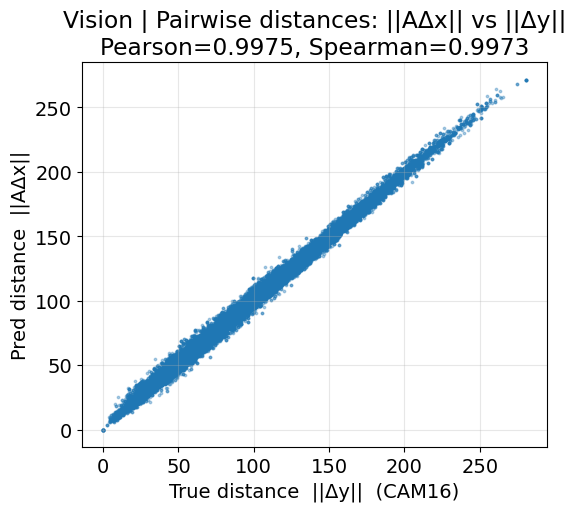

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt


# ============================================================
# 0) Utils
# ============================================================

def sanitize_XY(X, Y):
    X = np.asarray(X, dtype=np.float32)
    Y = np.asarray(Y, dtype=np.float32)
    m = np.isfinite(X).all(axis=1) & np.isfinite(Y).all(axis=1)
    if m.sum() < len(m):
        print(f"sanitize: dropped {len(m)-m.sum()}/{len(m)} rows with NaN/Inf")
    return X[m], Y[m]

def sample_pairs_uniform(n, n_pairs, rng):
    i = rng.integers(0, n, size=n_pairs, endpoint=False)
    j = rng.integers(0, n, size=n_pairs, endpoint=False)
    eq = (i == j)
    while np.any(eq):
        j[eq] = rng.integers(0, n, size=np.sum(eq), endpoint=False)
        eq = (i == j)
    i2 = np.minimum(i, j)
    j2 = np.maximum(i, j)
    return i2, j2

def make_pair_batch(X, Y, i, j):
    """
    returns:
      V: (B,n)  = X[i]-X[j]
      t2:(B,)   = ||Y[i]-Y[j]||^2   (Y is 3D)
    """
    V = X[i] - X[j]
    dY = Y[i] - Y[j]
    t2 = np.sum(dY * dY, axis=1)
    m = np.isfinite(V).all(axis=1) & np.isfinite(t2)
    if not np.all(m):
        V = V[m]
        t2 = t2[m]
    return V, t2


# ============================================================
# 1) Objective for FULL A (n x n)
#    L = mean ( ||A v||^2 - t2 )^2
#    grad_A = 4 * mean( e * (A v) v^T )
# ============================================================

def loss_and_grad_A_squared_full(A, V, t2):
    AV = V @ A.T
    s = np.sum(AV * AV, axis=1)            # ||A v||^2
    e = (s - t2)                           # (B,)
    loss = float(np.mean(e * e))

    c = (4.0 * e).astype(np.float32)       # (B,)
    grad = ((c[:, None] * AV).T @ V) / max(1, V.shape[0])   # (n,n)
    return loss, grad


# ============================================================
# 2) AdamW (float32) + grad clipping
# ============================================================

class AdamW:
    def __init__(self, shape, lr=1e-3, beta1=0.9, beta2=0.999, eps=1e-8, weight_decay=1e-4):
        self.lr = float(lr)
        self.b1 = float(beta1)
        self.b2 = float(beta2)
        self.eps = float(eps)
        self.wd = float(weight_decay)
        self.m = np.zeros(shape, dtype=np.float32)
        self.v = np.zeros(shape, dtype=np.float32)
        self.t = 0

    def step(self, param, grad):
        self.t += 1

        # decoupled weight decay
        if self.wd > 0:
            param = param * (1.0 - self.lr * self.wd)

        self.m = self.b1 * self.m + (1 - self.b1) * grad
        self.v = self.b2 * self.v + (1 - self.b2) * (grad * grad)

        mhat = self.m / (1 - self.b1 ** self.t)
        vhat = self.v / (1 - self.b2 ** self.t)

        param = param - self.lr * mhat / (np.sqrt(vhat) + self.eps)
        return param


# ============================================================
# 3) Validation metrics (MAE/MAPE/sMAPE) + correlations
# ============================================================

def regression_errors(y_true, y_pred, eps=1e-6):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)

    err = y_pred - y_true
    mae = float(np.mean(np.abs(err)))
    rmse = float(np.sqrt(np.mean(err * err)))

    denom = np.maximum(np.abs(y_true), eps)
    mape = float(np.mean(np.abs(err) / denom) * 100.0)

    smape = float(
        np.mean(2.0 * np.abs(err) / np.maximum(np.abs(y_true) + np.abs(y_pred), eps)) * 100.0
    )
    return {"rmse": rmse, "mae": mae, "mape": mape, "smape": smape}

def compute_pred_true_for_pairs(X, Y, A, i, j, eps=1e-12):
    """
    returns dict with arrays:
      t2, pred2, t, pred
    """
    dY = Y[i] - Y[j]
    t2 = np.sum(dY * dY, axis=1)
    t = np.sqrt(np.maximum(t2, 0.0))

    dX = X[i] - X[j]
    AdX = dX @ A.T
    pred2 = np.sum(AdX * AdX, axis=1)
    pred = np.sqrt(np.maximum(pred2, 0.0))

    m = np.isfinite(t2) & np.isfinite(pred2) & np.isfinite(t) & np.isfinite(pred)
    return {
        "t2": t2[m], "pred2": pred2[m],
        "t": t[m], "pred": pred[m]
    }

def eval_alignment_fullA(X, Y, A, n_eval_pairs=80_000, seed=0, eps=1e-6, mode="sq"):
    """
    mode:
      "sq"   -> compare t2=||Δy||^2 with pred2=||AΔx||^2
      "dist" -> compare t =||Δy||   with pred =||AΔx||
    """
    rng = np.random.default_rng(seed)
    n = X.shape[0]
    i, j = sample_pairs_uniform(n, n_eval_pairs, rng)
    d = compute_pred_true_for_pairs(X, Y, A, i, j)

    if mode == "sq":
        y_true, y_pred = d["t2"], d["pred2"]
    elif mode == "dist":
        y_true, y_pred = d["t"], d["pred"]
    else:
        raise ValueError("mode must be 'sq' or 'dist'")

    errs = regression_errors(y_true, y_pred, eps=eps)

    pr = float(pearsonr(y_true, y_pred)[0])
    sr = spearmanr(y_true, y_pred)
    sr_r = float(getattr(sr, "correlation", sr.statistic))

    return {**errs, "pearson": pr, "spearman": sr_r}

def estimate_val_loss_sq(X, Y, A, n_eval_pairs=80_000, seed=0):
    """
    Validation loss in the SAME objective units as training:
      mean( (||AΔx||^2 - ||Δy||^2)^2 )
    """
    rng = np.random.default_rng(seed)
    n = X.shape[0]
    i, j = sample_pairs_uniform(n, n_eval_pairs, rng)
    V, t2 = make_pair_batch(X, Y, i, j)
    AV = V @ A.T
    pred2 = np.sum(AV * AV, axis=1)
    e = pred2 - t2
    return float(np.mean(e * e))


# ============================================================
# 4) Init: A = alpha * I (match mean squared distances roughly)
# ============================================================

def init_alphaI(X, Y, n_pairs=120_000, seed=0, eps=1e-12):
    rng = np.random.default_rng(seed)
    n = X.shape[0]
    i, j = sample_pairs_uniform(n, n_pairs, rng)

    dx = X[i] - X[j]
    dx2 = np.sum(dx * dx, axis=1)     # ||Δx||^2
    dy = Y[i] - Y[j]
    dy2 = np.sum(dy * dy, axis=1)     # ||Δy||^2

    num = float(np.dot(dy2, dx2))
    den = float(np.dot(dx2, dx2)) + eps
    alpha2 = max(num / den, 0.0)
    return float(np.sqrt(alpha2))


# ============================================================
# 5) Training loop with validation metrics, BUT best step by VAL LOSS
# ============================================================

def fit_fullA_distance_squares(
    X_train, Y_train, X_val, Y_val,
    n_steps=1200,
    n_pairs=400_000,
    batch_size=512,
    lr=3e-4,
    weight_decay=3e-4,
    grad_clip=5.0,
    seed=42,
    # logging
    log_every=50,
    val_every=200,
    n_val_pairs=80_000,
    # early stopping by val loss (objective)
    patience=5,
    min_delta=0.0,
):
    rng = np.random.default_rng(seed)
    n_dim = X_train.shape[1]

    alpha = init_alphaI(X_train, Y_train, n_pairs=120_000, seed=seed + 1)
    A = (alpha * np.eye(n_dim, dtype=np.float32))
    print(f"Init A = alpha*I, alpha={alpha:.6f}, ||A||={np.linalg.norm(A):.4f}")

    opt = AdamW(A.shape, lr=lr, weight_decay=weight_decay)

    i_all, j_all = sample_pairs_uniform(X_train.shape[0], n_pairs, rng)
    n_batches = int(np.ceil(n_pairs / batch_size))

    # histories
    hist_train_steps, hist_train_loss = [], []
    hist_val_steps, hist_val_loss = [], []
    hist_val_sq_rmse, hist_val_dist_rmse = [], []

    # best checkpoint by VAL LOSS (objective units)
    best = {
        "val_loss": np.inf,
        "A": A.copy(),
        "step": 0,
        "val_metrics_sq": None,
        "val_metrics_dist": None,
    }
    bad_count = 0

    for step in range(1, n_steps + 1):
        b = (step - 1) % n_batches
        sl = slice(b * batch_size, min((b + 1) * batch_size, n_pairs))
        i, j = i_all[sl], j_all[sl]

        V, t2 = make_pair_batch(X_train, Y_train, i, j)
        train_loss, grad = loss_and_grad_A_squared_full(A, V, t2)

        gnorm = float(np.linalg.norm(grad))
        if grad_clip is not None and gnorm > grad_clip:
            grad = grad * (grad_clip / (gnorm + 1e-12))

        if not (np.isfinite(train_loss) and np.isfinite(A).all() and np.isfinite(grad).all()):
            raise FloatingPointError(
                f"Non-finite at step={step}: train_loss={train_loss}, ||A||={np.linalg.norm(A)}"
            )

        A = opt.step(A, grad.astype(np.float32))

        if step % log_every == 0 or step == 1:
            hist_train_steps.append(step)
            hist_train_loss.append(train_loss)

        if step % val_every == 0 or step == n_steps:
            # --- Val loss (objective) ---
            val_loss = estimate_val_loss_sq(X_val, Y_val, A, n_eval_pairs=n_val_pairs, seed=seed + step)

            # --- Extra metrics (sq + dist) ---
            val_sq = eval_alignment_fullA(X_val, Y_val, A, n_eval_pairs=n_val_pairs, seed=seed + step + 10, mode="sq")
            val_d  = eval_alignment_fullA(X_val, Y_val, A, n_eval_pairs=n_val_pairs, seed=seed + step + 11, mode="dist")

            hist_val_steps.append(step)
            hist_val_loss.append(val_loss)
            hist_val_sq_rmse.append(val_sq["rmse"])
            hist_val_dist_rmse.append(val_d["rmse"])

            print(f"step={step}/{n_steps} "
                  f"train_loss(batch)={train_loss:.6f} ||grad||={gnorm:.3f} ||A||={np.linalg.norm(A):.3f}")
            print(f"  [val objective] loss={val_loss:.6f}")

            print(f"  [val sq]   RMSE={val_sq['rmse']:.3f} MAE={val_sq['mae']:.3f} "
                  f"MAPE={val_sq['mape']:.2f}% sMAPE={val_sq['smape']:.2f}% "
                  f"Pearson={val_sq['pearson']:.4f} Spearman={val_sq['spearman']:.4f}")

            print(f"  [val dist] RMSE={val_d['rmse']:.3f} MAE={val_d['mae']:.3f} "
                  f"MAPE={val_d['mape']:.2f}% sMAPE={val_d['smape']:.2f}% "
                  f"Pearson={val_d['pearson']:.4f} Spearman={val_d['spearman']:.4f}")

            # --- early stopping & best checkpoint by val_loss ---
            if val_loss < best["val_loss"] - min_delta:
                best = {
                    "val_loss": val_loss,
                    "A": A.copy(),
                    "step": step,
                    "val_metrics_sq": val_sq,
                    "val_metrics_dist": val_d,
                }
                bad_count = 0
            else:
                bad_count += 1
                if bad_count >= patience:
                    print(f"Early stopping at step={step}: "
                          f"no improvement in VAL LOSS for {patience} validations. "
                          f"Best step={best['step']} val_loss={best['val_loss']:.6f}")
                    break

    # ---- plots ----
    plt.figure(figsize=(7, 4))
    plt.plot(hist_train_steps, hist_train_loss, label="train loss (batch)")
    if len(hist_val_steps) > 0:
        plt.plot(hist_val_steps, hist_val_loss, marker="o", label="val loss (objective)")
    plt.xlabel("step")
    plt.ylabel("loss")
    plt.title("Training vs Validation objective loss")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    plt.figure(figsize=(7, 4))
    if len(hist_val_steps) > 0:
        plt.plot(hist_val_steps, hist_val_sq_rmse, marker="o", label="val RMSE on t²")
        plt.plot(hist_val_steps, hist_val_dist_rmse, marker="o", label="val RMSE on t")
    plt.xlabel("step")
    plt.ylabel("RMSE")
    plt.title("Validation RMSE (squared distances vs distances)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    print(f"Best by VAL LOSS: step={best['step']} val_loss={best['val_loss']:.6f}")
    if best["val_metrics_sq"] is not None:
        sq = best["val_metrics_sq"]
        d = best["val_metrics_dist"]
        print(f"  [best val sq]   RMSE={sq['rmse']:.3f} MAE={sq['mae']:.3f} MAPE={sq['mape']:.2f}% sMAPE={sq['smape']:.2f}% "
              f"Pearson={sq['pearson']:.4f} Spearman={sq['spearman']:.4f}")
        print(f"  [best val dist] RMSE={d['rmse']:.3f} MAE={d['mae']:.3f} MAPE={d['mape']:.2f}% sMAPE={d['smape']:.2f}% "
              f"Pearson={d['pearson']:.4f} Spearman={d['spearman']:.4f}")

    history = {
        "train_steps": np.array(hist_train_steps, dtype=int),
        "train_loss": np.array(hist_train_loss, dtype=float),
        "val_steps": np.array(hist_val_steps, dtype=int),
        "val_loss": np.array(hist_val_loss, dtype=float),
        "val_sq_rmse": np.array(hist_val_sq_rmse, dtype=float),
        "val_dist_rmse": np.array(hist_val_dist_rmse, dtype=float),
    }
    return best, history


# ============================================================
# 6) Scatter plot: ||AΔx|| vs ||Δy||
# ============================================================

def plot_distance_scatter(X, Y, A, n_plot_pairs=60_000, seed=123, title=""):
    rng = np.random.default_rng(seed)
    n = X.shape[0]
    i, j = sample_pairs_uniform(n, n_plot_pairs, rng)

    dY = Y[i] - Y[j]
    d_true = np.sqrt(np.maximum(np.sum(dY * dY, axis=1), 0.0))

    dX = X[i] - X[j]
    AdX = dX @ A.T
    d_pred = np.sqrt(np.maximum(np.sum(AdX * AdX, axis=1), 0.0))

    pr = float(pearsonr(d_true, d_pred)[0])
    sr = spearmanr(d_true, d_pred)
    sr_r = float(getattr(sr, "correlation", sr.statistic))

    plt.figure(figsize=(6, 5))
    plt.scatter(d_true, d_pred, s=3, alpha=0.35)
    plt.xlabel("True distance  ||Δy||  (CAM16)")
    plt.ylabel("Pred distance  ||AΔx||")
    plt.title(title + f"\nPearson={pr:.4f}, Spearman={sr_r:.4f}")
    plt.grid(True, alpha=0.3)
    plt.show()

    return {"pearson_dist": pr, "spearman_dist": sr_r}


# ============================================================
# 7) End-to-end runner
# ============================================================

def run_fullA_experiment(
    embeddings, Y_cam,
    layer_name="LM",
    test_size=0.2,
    random_state=42,
    n_steps=1200,
    n_pairs=400_000,
    batch_size=512,
    lr=3e-4,
    weight_decay=3e-4,
    grad_clip=5.0,
    val_every=200,
    n_val_pairs=80_000,
    patience=5,
    min_delta=0.0,
):
    X, Y = sanitize_XY(embeddings, Y_cam)

    X_tr, X_te, Y_tr, Y_te = train_test_split(
        X, Y, test_size=test_size, random_state=random_state
    )

    print(f"[{layer_name}] X_tr={X_tr.shape}, X_te={X_te.shape}, dim={X_tr.shape[1]}")

    best, history = fit_fullA_distance_squares(
        X_tr, Y_tr, X_te, Y_te,
        n_steps=n_steps,
        n_pairs=n_pairs,
        batch_size=batch_size,
        lr=lr,
        weight_decay=weight_decay,
        grad_clip=grad_clip,
        seed=42,
        log_every=50,
        val_every=val_every,
        n_val_pairs=n_val_pairs,
        patience=patience,
        min_delta=min_delta,
    )

    A_best = best["A"]

    # FINAL evaluation on test, using additional metrics (but not for selection)
    final_loss = estimate_val_loss_sq(X_te, Y_te, A_best, n_eval_pairs=200_000, seed=999)
    final_sq = eval_alignment_fullA(X_te, Y_te, A_best, n_eval_pairs=200_000, seed=1001, mode="sq")
    final_d  = eval_alignment_fullA(X_te, Y_te, A_best, n_eval_pairs=200_000, seed=1002, mode="dist")

    print(f"[{layer_name}] FINAL test objective loss={final_loss:.6f}")
    print(f"[{layer_name}] FINAL test (sq):   RMSE={final_sq['rmse']:.3f} MAE={final_sq['mae']:.3f} "
          f"MAPE={final_sq['mape']:.2f}% sMAPE={final_sq['smape']:.2f}% "
          f"Pearson={final_sq['pearson']:.4f} Spearman={final_sq['spearman']:.4f}")
    print(f"[{layer_name}] FINAL test (dist): RMSE={final_d['rmse']:.3f} MAE={final_d['mae']:.3f} "
          f"MAPE={final_d['mape']:.2f}% sMAPE={final_d['smape']:.2f}% "
          f"Pearson={final_d['pearson']:.4f} Spearman={final_d['spearman']:.4f}")

    plot_distance_scatter(
        X_te, Y_te, A_best,
        n_plot_pairs=80_000,
        seed=777,
        title=f"{layer_name} | Pairwise distances: ||AΔx|| vs ||Δy||"
    )

    return {
        "A": A_best,
        "best": best,
        "history": history,
        "final": {"loss": final_loss, "sq": final_sq, "dist": final_d},
    }


# ============================================================
# Usage:
out_lm = run_fullA_experiment(lm, cam, layer_name="LM")
print("-" * 30)
out_vl = run_fullA_experiment(vl, cam, layer_name="Vision")
# ============================================================


## tsne реузультаты использующиеся в тезисах

LM missing specs: ['5.0Y 5/0', '5.0G 5/0', '5.0G 5/8', '5.0P 5/0', '5.0B 5/0']


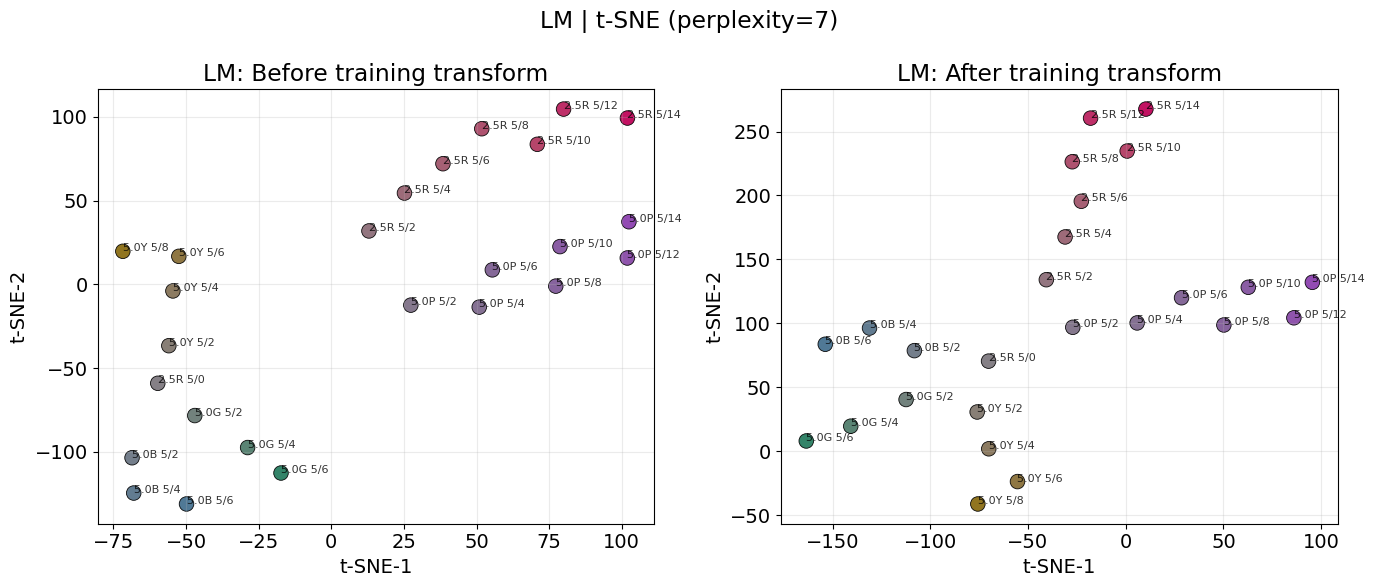

Vision missing specs: ['5.0Y 5/0', '5.0G 5/0', '5.0G 5/8', '5.0P 5/0', '5.0B 5/0']


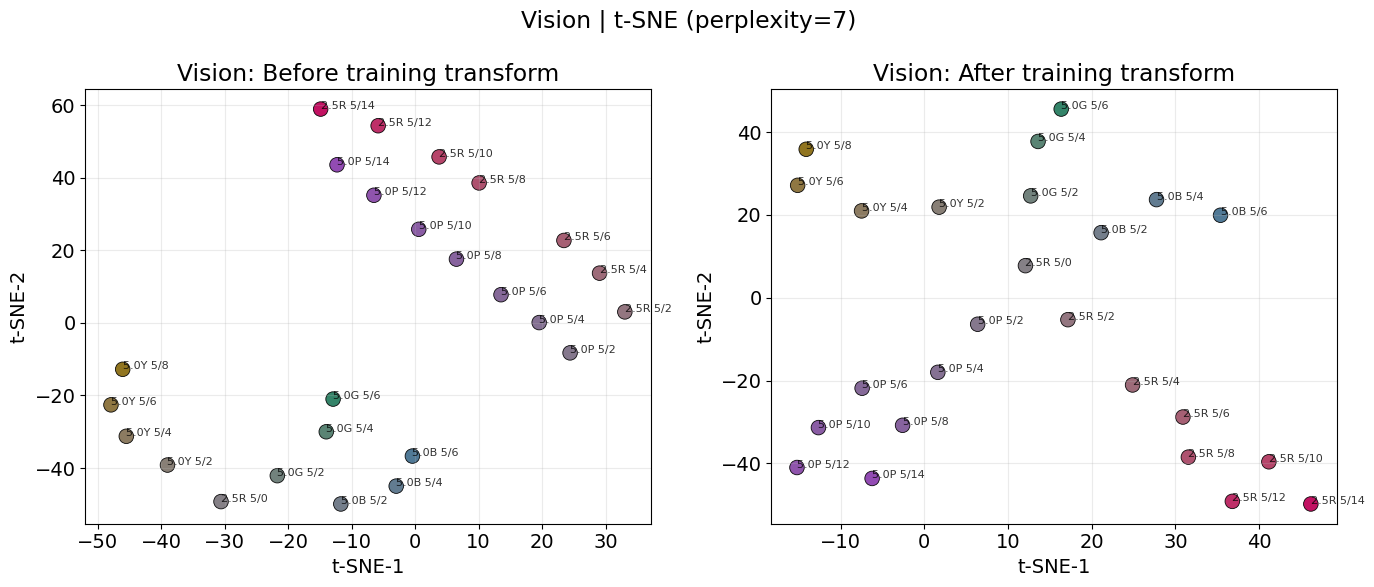

In [ ]:
from utils.analyze.tsne_before_after_munsell import (
    default_chroma_subset_spec,
    tsne_before_after_on_munsell_subset,
    plot_tsne_before_after,
)

spec = default_chroma_subset_spec(perplexity=7)
A_lm = out_lm["A"]   # (d, d)
A_vl = out_vl["A"]   # (d, d)

lm_after = lm @ A_lm.T
vl_after = vl @ A_vl.T

# LM
res_lm = tsne_before_after_on_munsell_subset(
    embeddings_before=lm,        # исходные LM эмбеддинги
    embeddings_after=lm_after,  # после Ridge
    spec=spec,
)
print("LM missing specs:", res_lm.missing_specs)  # если какие-то H/V/C отсутствуют в CSV
plot_tsne_before_after(res_lm, title_prefix="LM")

# Vision
res_vl = tsne_before_after_on_munsell_subset(
    embeddings_before=vl,
    embeddings_after=vl_after,
    spec=spec,
)
print("Vision missing specs:", res_vl.missing_specs)
plot_tsne_before_after(res_vl, title_prefix="Vision")


[LM] X_tr=(1404, 3584), X_te=(351, 3584), dim=3584
Init A = alpha*I, alpha=0.739336, ||A||=44.2615
step=50/1500 train_loss(batch)=2214018.500000 ||grad||=20350154.000 ||A||=44.598
  [val objective] loss=1582794.000000
  [val dist] RMSE=6.109 MAE=4.717 MAPE=6.98% sMAPE=6.42% Pearson=0.9907 Spearman=0.9901
step=100/1500 train_loss(batch)=1537622.875000 ||grad||=18037188.000 ||A||=44.703
  [val objective] loss=1154271.750000
  [val dist] RMSE=4.950 MAE=3.868 MAPE=5.59% sMAPE=5.23% Pearson=0.9937 Spearman=0.9932
step=150/1500 train_loss(batch)=1355572.375000 ||grad||=15114224.000 ||A||=44.781
  [val objective] loss=885718.625000
  [val dist] RMSE=4.493 MAE=3.473 MAPE=5.20% sMAPE=4.84% Pearson=0.9955 Spearman=0.9953
step=200/1500 train_loss(batch)=832674.375000 ||grad||=16737375.000 ||A||=44.849
  [val objective] loss=747253.062500
  [val dist] RMSE=4.253 MAE=3.311 MAPE=4.89% sMAPE=4.57% Pearson=0.9959 Spearman=0.9956
step=250/1500 train_loss(batch)=570257.125000 ||grad||=10060398.000 ||A||

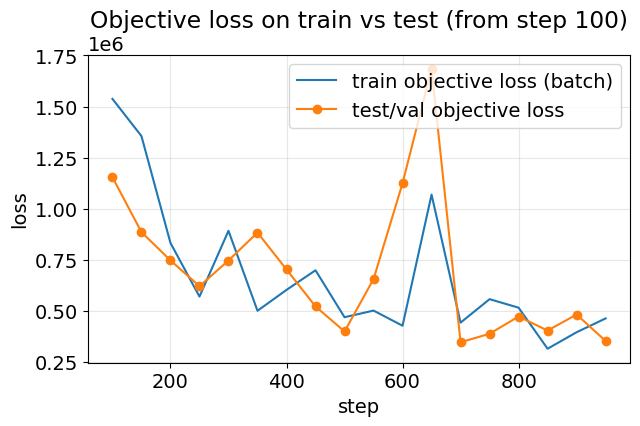

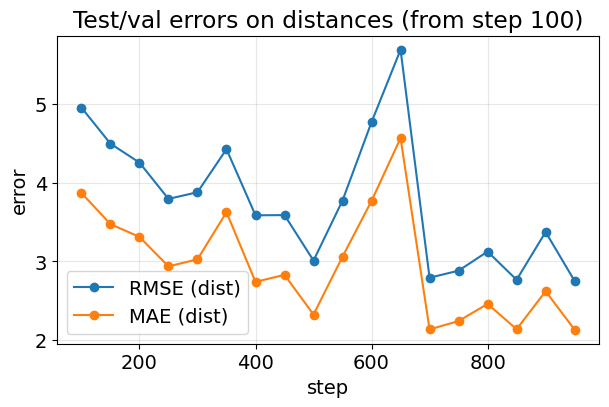

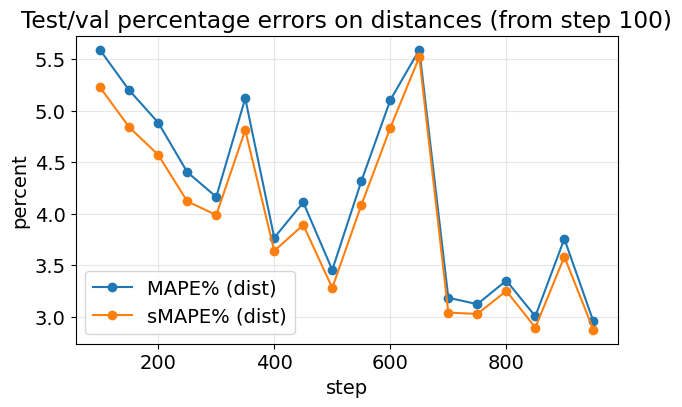

Best by VAL LOSS: step=700 val_loss=346588.812500
  [best val dist] RMSE=2.793 MAE=2.138 MAPE=3.18% sMAPE=3.04% Pearson=0.9980 Spearman=0.9979
[LM] FINAL test objective loss=344291.968750
[LM] FINAL test distances: RMSE=2.773 MAE=2.131 MAPE=3.16% sMAPE=3.02% Pearson=0.9980 Spearman=0.9979
------------------------------
[Vision] X_tr=(1404, 3584), X_te=(351, 3584), dim=3584
Init A = alpha*I, alpha=7.740572, ||A||=463.4012
step=50/1500 train_loss(batch)=19360168.000000 ||grad||=2018502.250 ||A||=464.521
  [val objective] loss=16968128.000000
  [val dist] RMSE=16.971 MAE=13.156 MAPE=17.31% sMAPE=15.21% Pearson=0.9250 Spearman=0.9321
step=100/1500 train_loss(batch)=6777116.000000 ||grad||=1500686.375 ||A||=466.274
  [val objective] loss=5601024.000000
  [val dist] RMSE=10.212 MAE=7.861 MAPE=10.68% sMAPE=9.75% Pearson=0.9741 Spearman=0.9739
step=150/1500 train_loss(batch)=4975395.500000 ||grad||=909641.938 ||A||=467.533
  [val objective] loss=2969081.750000
  [val dist] RMSE=7.760 MAE=5.969

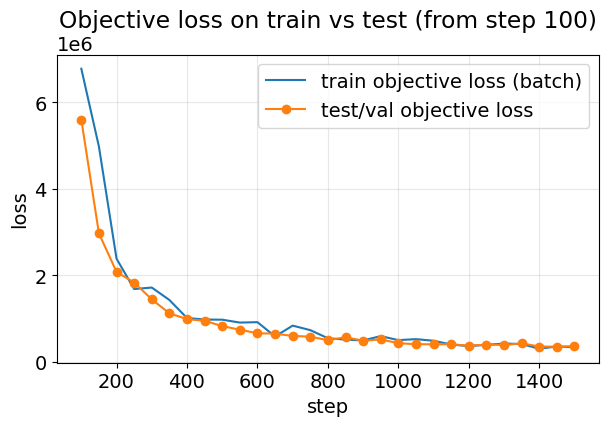

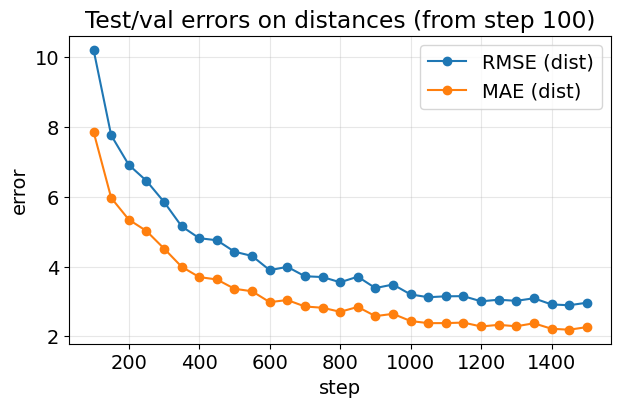

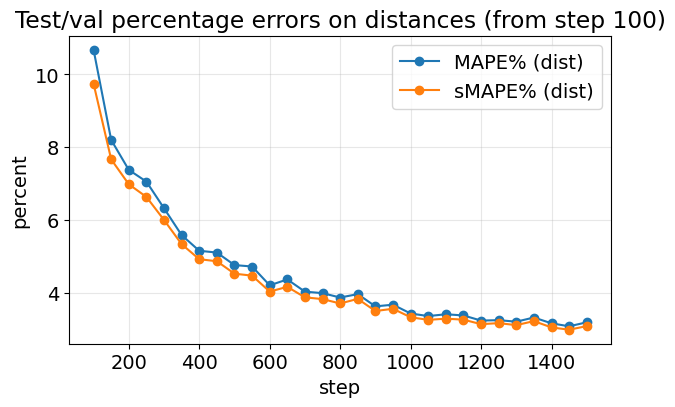

Best by VAL LOSS: step=1450 val_loss=350019.062500
  [best val dist] RMSE=2.892 MAE=2.190 MAPE=3.07% sMAPE=2.98% Pearson=0.9977 Spearman=0.9976
[Vision] FINAL test objective loss=348335.562500
[Vision] FINAL test distances: RMSE=2.871 MAE=2.174 MAPE=3.08% sMAPE=2.98% Pearson=0.9978 Spearman=0.9976


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt


# ============================================================
# 0) Utils
# ============================================================

def sanitize_XY(X, Y):
    X = np.asarray(X, dtype=np.float32)
    Y = np.asarray(Y, dtype=np.float32)
    m = np.isfinite(X).all(axis=1) & np.isfinite(Y).all(axis=1)
    if m.sum() < len(m):
        print(f"sanitize: dropped {len(m)-m.sum()}/{len(m)} rows with NaN/Inf")
    return X[m], Y[m]

def sample_pairs_uniform(n, n_pairs, rng):
    i = rng.integers(0, n, size=n_pairs, endpoint=False)
    j = rng.integers(0, n, size=n_pairs, endpoint=False)
    eq = (i == j)
    while np.any(eq):
        j[eq] = rng.integers(0, n, size=np.sum(eq), endpoint=False)
        eq = (i == j)
    i2 = np.minimum(i, j)
    j2 = np.maximum(i, j)
    return i2, j2

def make_pair_batch(X, Y, i, j):
    """
    returns:
      V:  (B,n) = X[i]-X[j]
      t2: (B,)  = ||Y[i]-Y[j]||^2
    """
    V = X[i] - X[j]
    dY = Y[i] - Y[j]
    t2 = np.sum(dY * dY, axis=1)
    m = np.isfinite(V).all(axis=1) & np.isfinite(t2)
    if not np.all(m):
        V = V[m]
        t2 = t2[m]
    return V, t2

def compute_pred_true_for_pairs(X, Y, A, i, j):
    """
    returns arrays:
      t  = ||Δy||,  pred = ||AΔx||
      t2 = ||Δy||^2, pred2=||AΔx||^2
    """
    dY = Y[i] - Y[j]
    t2 = np.sum(dY * dY, axis=1)
    t = np.sqrt(np.maximum(t2, 0.0))

    dX = X[i] - X[j]
    AdX = dX @ A.T
    pred2 = np.sum(AdX * AdX, axis=1)
    pred = np.sqrt(np.maximum(pred2, 0.0))

    m = np.isfinite(t) & np.isfinite(pred) & np.isfinite(t2) & np.isfinite(pred2)
    return t[m], pred[m], t2[m], pred2[m]


# ============================================================
# 1) Objective for FULL A (n x n): squared-distances objective
#    L = mean ( ||A v||^2 - t2 )^2
# ============================================================

def loss_and_grad_A_squared_full(A, V, t2):
    AV = V @ A.T
    s = np.sum(AV * AV, axis=1)            # ||A v||^2
    e = (s - t2)                           # (B,)
    loss = float(np.mean(e * e))

    c = (4.0 * e).astype(np.float32)       # (B,)
    grad = ((c[:, None] * AV).T @ V) / max(1, V.shape[0])   # (n,n)
    return loss, grad


# ============================================================
# 2) AdamW (float32) + grad clipping
# ============================================================

class AdamW:
    def __init__(self, shape, lr=1e-3, beta1=0.9, beta2=0.999, eps=1e-8, weight_decay=1e-4):
        self.lr = float(lr)
        self.b1 = float(beta1)
        self.b2 = float(beta2)
        self.eps = float(eps)
        self.wd = float(weight_decay)
        self.m = np.zeros(shape, dtype=np.float32)
        self.v = np.zeros(shape, dtype=np.float32)
        self.t = 0

    def step(self, param, grad):
        self.t += 1
        if self.wd > 0:
            param = param * (1.0 - self.lr * self.wd)

        self.m = self.b1 * self.m + (1 - self.b1) * grad
        self.v = self.b2 * self.v + (1 - self.b2) * (grad * grad)

        mhat = self.m / (1 - self.b1 ** self.t)
        vhat = self.v / (1 - self.b2 ** self.t)

        param = param - self.lr * mhat / (np.sqrt(vhat) + self.eps)
        return param


# ============================================================
# 3) Metrics on DISTANCES (not squared)
# ============================================================

def dist_errors(d_true, d_pred, eps=1e-6):
    d_true = np.asarray(d_true, dtype=np.float64)
    d_pred = np.asarray(d_pred, dtype=np.float64)

    err = d_pred - d_true
    mae = float(np.mean(np.abs(err)))
    rmse = float(np.sqrt(np.mean(err * err)))

    denom = np.maximum(np.abs(d_true), eps)
    mape = float(np.mean(np.abs(err) / denom) * 100.0)
    smape = float(np.mean(2.0 * np.abs(err) / np.maximum(np.abs(d_true) + np.abs(d_pred), eps)) * 100.0)

    pr = float(pearsonr(d_true, d_pred)[0])
    sr = spearmanr(d_true, d_pred)
    sr_r = float(getattr(sr, "correlation", sr.statistic))

    return {"rmse": rmse, "mae": mae, "mape": mape, "smape": smape, "pearson": pr, "spearman": sr_r}

def estimate_val_loss_sq_objective(X, Y, A, n_eval_pairs=80_000, seed=0):
    """
    Objective loss in training units:
      mean( (||AΔx||^2 - ||Δy||^2)^2 )
    """
    rng = np.random.default_rng(seed)
    n = X.shape[0]
    i, j = sample_pairs_uniform(n, n_eval_pairs, rng)
    V, t2 = make_pair_batch(X, Y, i, j)
    AV = V @ A.T
    pred2 = np.sum(AV * AV, axis=1)
    e = pred2 - t2
    return float(np.mean(e * e))

def eval_dist_metrics(X, Y, A, n_eval_pairs=80_000, seed=0):
    rng = np.random.default_rng(seed)
    n = X.shape[0]
    i, j = sample_pairs_uniform(n, n_eval_pairs, rng)
    d_true, d_pred, _, _ = compute_pred_true_for_pairs(X, Y, A, i, j)
    return dist_errors(d_true, d_pred)


# ============================================================
# 4) Init: A = alpha * I
# ============================================================

def init_alphaI(X, Y, n_pairs=120_000, seed=0, eps=1e-12):
    rng = np.random.default_rng(seed)
    n = X.shape[0]
    i, j = sample_pairs_uniform(n, n_pairs, rng)

    dx = X[i] - X[j]
    dx2 = np.sum(dx * dx, axis=1)     # ||Δx||^2
    dy = Y[i] - Y[j]
    dy2 = np.sum(dy * dy, axis=1)     # ||Δy||^2

    num = float(np.dot(dy2, dx2))
    den = float(np.dot(dx2, dx2)) + eps
    alpha2 = max(num / den, 0.0)
    return float(np.sqrt(alpha2))


# ============================================================
# 5) Training loop
#    - best step by VAL objective loss
#    - plots:
#        (a) train vs val objective loss (from plot_from_step)
#        (b) distance metrics (RMSE/MAE/MAPE/sMAPE) on val (from plot_from_step)
# ============================================================

def fit_fullA_distance_squares(
    X_train, Y_train, X_val, Y_val,
    n_steps=1200,
    n_pairs=400_000,
    batch_size=512,
    lr=3e-4,
    weight_decay=3e-4,
    grad_clip=5.0,
    seed=42,
    log_every=50,
    val_every=200,
    n_val_pairs=80_000,
    patience=5,
    min_delta=0.0,
    plot_from_step=100,
):
    rng = np.random.default_rng(seed)
    n_dim = X_train.shape[1]

    alpha = init_alphaI(X_train, Y_train, n_pairs=120_000, seed=seed + 1)
    A = (alpha * np.eye(n_dim, dtype=np.float32))
    print(f"Init A = alpha*I, alpha={alpha:.6f}, ||A||={np.linalg.norm(A):.4f}")

    opt = AdamW(A.shape, lr=lr, weight_decay=weight_decay)

    i_all, j_all = sample_pairs_uniform(X_train.shape[0], n_pairs, rng)
    n_batches = int(np.ceil(n_pairs / batch_size))

    # histories
    hist_train_steps, hist_train_loss = [], []
    hist_val_steps, hist_val_loss = [], []

    # distance metrics histories (val only)
    hist_val_rmse, hist_val_mae, hist_val_mape, hist_val_smape = [], [], [], []

    best = {"val_loss": np.inf, "A": A.copy(), "step": 0, "val_dist": None}
    bad_count = 0

    for step in range(1, n_steps + 1):
        b = (step - 1) % n_batches
        sl = slice(b * batch_size, min((b + 1) * batch_size, n_pairs))
        i, j = i_all[sl], j_all[sl]

        V, t2 = make_pair_batch(X_train, Y_train, i, j)
        train_loss, grad = loss_and_grad_A_squared_full(A, V, t2)

        gnorm = float(np.linalg.norm(grad))
        if grad_clip is not None and gnorm > grad_clip:
            grad = grad * (grad_clip / (gnorm + 1e-12))

        if not (np.isfinite(train_loss) and np.isfinite(A).all() and np.isfinite(grad).all()):
            raise FloatingPointError(
                f"Non-finite at step={step}: train_loss={train_loss}, ||A||={np.linalg.norm(A)}"
            )

        A = opt.step(A, grad.astype(np.float32))

        if step % log_every == 0 or step == 1:
            hist_train_steps.append(step)
            hist_train_loss.append(train_loss)

        if step % val_every == 0 or step == n_steps:
            val_loss = estimate_val_loss_sq_objective(
                X_val, Y_val, A, n_eval_pairs=n_val_pairs, seed=seed + step
            )
            val_dist = eval_dist_metrics(
                X_val, Y_val, A, n_eval_pairs=n_val_pairs, seed=seed + step + 11
            )

            hist_val_steps.append(step)
            hist_val_loss.append(val_loss)

            hist_val_rmse.append(val_dist["rmse"])
            hist_val_mae.append(val_dist["mae"])
            hist_val_mape.append(val_dist["mape"])
            hist_val_smape.append(val_dist["smape"])

            print(f"step={step}/{n_steps} train_loss(batch)={train_loss:.6f} ||grad||={gnorm:.3f} ||A||={np.linalg.norm(A):.3f}")
            print(f"  [val objective] loss={val_loss:.6f}")
            print(f"  [val dist] RMSE={val_dist['rmse']:.3f} MAE={val_dist['mae']:.3f} "
                  f"MAPE={val_dist['mape']:.2f}% sMAPE={val_dist['smape']:.2f}% "
                  f"Pearson={val_dist['pearson']:.4f} Spearman={val_dist['spearman']:.4f}")

            if val_loss < best["val_loss"] - min_delta:
                best = {"val_loss": val_loss, "A": A.copy(), "step": step, "val_dist": val_dist}
                bad_count = 0
            else:
                bad_count += 1
                if bad_count >= patience:
                    print(f"Early stopping at step={step}: no improvement in VAL LOSS for {patience} validations. "
                          f"Best step={best['step']} val_loss={best['val_loss']:.6f}")
                    break

    # ---------- plots ----------
    tr_s = np.array(hist_train_steps, dtype=int)
    tr_l = np.array(hist_train_loss, dtype=float)
    va_s = np.array(hist_val_steps, dtype=int)
    va_l = np.array(hist_val_loss, dtype=float)

    m_tr = tr_s >= plot_from_step
    m_va = va_s >= plot_from_step

    # NEW: train + test(=val) objective loss on one plot
    plt.figure(figsize=(7, 4))
    if m_tr.any():
        plt.plot(tr_s[m_tr], tr_l[m_tr], label="train objective loss (batch)")
    if m_va.any():
        plt.plot(va_s[m_va], va_l[m_va], marker="o", label="test/val objective loss")
    plt.xlabel("step")
    plt.ylabel("loss")
    plt.title(f"Objective loss on train vs test (from step {plot_from_step})")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    # distance metrics (only distances)
    if len(hist_val_steps) > 0:
        m_va = va_s >= plot_from_step
        if m_va.any():
            plt.figure(figsize=(7, 4))
            plt.plot(va_s[m_va], np.array(hist_val_rmse)[m_va], marker="o", label="RMSE (dist)")
            plt.plot(va_s[m_va], np.array(hist_val_mae)[m_va], marker="o", label="MAE (dist)")
            plt.xlabel("step")
            plt.ylabel("error")
            plt.title(f"Test/val errors on distances (from step {plot_from_step})")
            plt.grid(True, alpha=0.3)
            plt.legend()
            plt.show()

            plt.figure(figsize=(7, 4))
            plt.plot(va_s[m_va], np.array(hist_val_mape)[m_va], marker="o", label="MAPE% (dist)")
            plt.plot(va_s[m_va], np.array(hist_val_smape)[m_va], marker="o", label="sMAPE% (dist)")
            plt.xlabel("step")
            plt.ylabel("percent")
            plt.title(f"Test/val percentage errors on distances (from step {plot_from_step})")
            plt.grid(True, alpha=0.3)
            plt.legend()
            plt.show()

    print(f"Best by VAL LOSS: step={best['step']} val_loss={best['val_loss']:.6f}")
    if best["val_dist"] is not None:
        d = best["val_dist"]
        print(f"  [best val dist] RMSE={d['rmse']:.3f} MAE={d['mae']:.3f} "
              f"MAPE={d['mape']:.2f}% sMAPE={d['smape']:.2f}% "
              f"Pearson={d['pearson']:.4f} Spearman={d['spearman']:.4f}")

    history = {
        "train_steps": tr_s,
        "train_loss": tr_l,
        "val_steps": va_s,
        "val_loss": va_l,
        "val_dist_rmse": np.array(hist_val_rmse, dtype=float),
        "val_dist_mae": np.array(hist_val_mae, dtype=float),
        "val_dist_mape": np.array(hist_val_mape, dtype=float),
        "val_dist_smape": np.array(hist_val_smape, dtype=float),
    }
    return best, history


# ============================================================
# 6) End-to-end runner
# ============================================================

def run_fullA_experiment(
    embeddings, Y_cam,
    layer_name="LM",
    test_size=0.2,
    random_state=42,
    n_steps=1500,
    n_pairs=400_000,
    batch_size=512,
    lr=3e-4,
    weight_decay=3e-4,
    grad_clip=5.0,
    val_every=50,
    n_val_pairs=80_000,
    patience=5,
    min_delta=0.0,
    plot_from_step=100,
):
    X, Y = sanitize_XY(embeddings, Y_cam)

    X_tr, X_te, Y_tr, Y_te = train_test_split(
        X, Y, test_size=test_size, random_state=random_state
    )

    print(f"[{layer_name}] X_tr={X_tr.shape}, X_te={X_te.shape}, dim={X_tr.shape[1]}")

    best, history = fit_fullA_distance_squares(
        X_tr, Y_tr, X_te, Y_te,
        n_steps=n_steps,
        n_pairs=n_pairs,
        batch_size=batch_size,
        lr=lr,
        weight_decay=weight_decay,
        grad_clip=grad_clip,
        seed=42,
        log_every=50,
        val_every=val_every,
        n_val_pairs=n_val_pairs,
        patience=patience,
        min_delta=min_delta,
        plot_from_step=plot_from_step,
    )

    A_best = best["A"]

    final_loss = estimate_val_loss_sq_objective(X_te, Y_te, A_best, n_eval_pairs=200_000, seed=999)
    final_dist = eval_dist_metrics(X_te, Y_te, A_best, n_eval_pairs=200_000, seed=1002)

    print(f"[{layer_name}] FINAL test objective loss={final_loss:.6f}")
    print(f"[{layer_name}] FINAL test distances: "
          f"RMSE={final_dist['rmse']:.3f} MAE={final_dist['mae']:.3f} "
          f"MAPE={final_dist['mape']:.2f}% sMAPE={final_dist['smape']:.2f}% "
          f"Pearson={final_dist['pearson']:.4f} Spearman={final_dist['spearman']:.4f}")

    return {"A": A_best, "best": best, "history": history, "final": {"loss": final_loss, "dist": final_dist}}


# ============================================================
# Usage:
out_lm = run_fullA_experiment(lm, cam, layer_name="LM")
print("-" * 30)
out_vl = run_fullA_experiment(vl, cam, layer_name="Vision")
# ============================================================


In [ ]:
from vsl_ial.stress import stress, mean_stress, group_stress
import numpy as np

def build_pair_indices(n, max_pairs=None, seed=42):
    i_all, j_all = np.triu_indices(n, k=1)
    if max_pairs is not None and max_pairs < i_all.size:
        rng = np.random.default_rng(seed)
        sel = rng.choice(i_all.size, size=max_pairs, replace=False)
        i_all, j_all = i_all[sel], j_all[sel]
    return i_all, j_all

def pairwise_distance_arrays(X, Y, A, pair_idx=None, chunk_size=20_000):
    """
    d_emb_A = ||A(x_i - x_j)||
    d_cam   = ||y_i - y_j||
    """
    X = np.asarray(X, dtype=np.float64)
    Y = np.asarray(Y, dtype=np.float64)
    A = np.asarray(A, dtype=np.float64)

    n = X.shape[0]
    if pair_idx is None:
        i_all, j_all = np.triu_indices(n, k=1)
    else:
        i_all, j_all = pair_idx
        # safety
        if i_all.max() >= n or j_all.max() >= n:
            raise ValueError(f"pair_idx out of bounds: max_i={i_all.max()}, max_j={j_all.max()}, n={n}")

    d_emb_A = np.empty(i_all.shape[0], dtype=np.float64)
    d_cam   = np.empty(i_all.shape[0], dtype=np.float64)

    for s in range(0, i_all.shape[0], chunk_size):
        e = min(s + chunk_size, i_all.shape[0])
        i, j = i_all[s:e], j_all[s:e]

        dX  = X[i] - X[j]
        AdX = dX @ A.T
        d_emb_A[s:e] = np.sqrt(np.maximum(np.sum(AdX * AdX, axis=1), 0.0))

        dY = Y[i] - Y[j]
        d_cam[s:e] = np.sqrt(np.maximum(np.sum(dY * dY, axis=1), 0.0))

    m = np.isfinite(d_emb_A) & np.isfinite(d_cam)
    return d_emb_A[m], d_cam[m]

X_lm, Y_cam_lm = sanitize_XY(lm, cam)
X_vl, Y_cam_vl = sanitize_XY(vl, cam)

assert X_lm.shape[0] == X_vl.shape[0] == Y_cam_lm.shape[0] == Y_cam_vl.shape[0], \
    (X_lm.shape, X_vl.shape, Y_cam_lm.shape, Y_cam_vl.shape)

n = Y_cam_lm.shape[0]
pair_idx = build_pair_indices(n=n, max_pairs=None, seed=42)  

d_emb_A_lm, d_cam = pairwise_distance_arrays(X_lm, Y_cam_lm, out_lm["A"], pair_idx=pair_idx)
d_emb_A_vl, _     = pairwise_distance_arrays(X_vl, Y_cam_vl, out_vl["A"], pair_idx=pair_idx)

print(f"Stress LM (ord=2):     {stress(d_emb_A_lm, d_cam, ord=2):.6f}")
print(f"Stress Vision (ord=2): {stress(d_emb_A_vl, d_cam, ord=2):.6f}")


Stress LM (ord=2):     0.026299
Stress Vision (ord=2): 0.026517
